#Three Dataset

##Import Libraries & Upload Stroke Dataset

In [1]:
pip install scikit-posthocs

In [2]:
# ============================================================
# HICSS 2027 — When Oversampling is Not Enough:
# Evaluating Hybrid Noise Cleaning Strategies for
# Minority Class Detection under Severe Class Imbalance
#
# Three-dataset benchmark:
#   Dataset 1 — Synthetic                  (controlled ~19.5:1)
#   Dataset 2 — Stroke (Kaggle)            (~19.5:1)
#   Dataset 3 — Taiwanese Bankruptcy (UCI) (~30.0:1)
# ============================================================

# ─────────────────────────────────────────
# 0. Install dependencies
# ─────────────────────────────────────────
!pip install ucimlrepo scikit-posthocs --quiet

# ─────────────────────────────────────────
# 0b. Upload stroke CSV
# ─────────────────────────────────────────
from google.colab import files
print("Upload healthcare-dataset-stroke-data.csv")
uploaded = files.upload()

# ─────────────────────────────────────────
# 1. Imports
# ─────────────────────────────────────────
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.base import clone
from itertools import combinations, product as iproduct
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.datasets import make_classification
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier as XgboostClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import (
    EditedNearestNeighbours,
    RepeatedEditedNearestNeighbours,
    AllKNN,
    NeighbourhoodCleaningRule,
    TomekLinks,
)
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn import FunctionSampler
from sklearn.base import clone as _clone

from scipy.stats import friedmanchisquare, wilcoxon

try:
    from scikit_posthocs import posthoc_nemenyi_friedman
    HAS_POSTHOC = True
except ImportError:
    HAS_POSTHOC = False
    print("scikit-posthocs not installed — Wilcoxon+Holm used instead.\n")

sns.set_style("ticks")
OUTPUT_DIR = Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Upload healthcare-dataset-stroke-data.csv


Saving healthcare-dataset-stroke-data (2).csv to healthcare-dataset-stroke-data (2).csv


##Load & Preprocess Stroke dataset

In [3]:
# ─────────────────────────────────────────
# 2. Dataset loaders
# ─────────────────────────────────────────

def load_synthetic():
    """
    Synthetic binary dataset — controlled benchmark.
    weights=[0.95, 0.05] → ~19.5:1 imbalance ratio.
    Isolates sampling strategy effect from dataset confounds.
    """
    X, y = make_classification(
        n_samples=500,
        n_features=20,
        n_informative=2,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        n_clusters_per_class=1,
        weights=[0.96, 0.04],
        class_sep=1.2,
        random_state=42
    )
    return X, y


def load_stroke_data(
    csv_path: str = "healthcare-dataset-stroke-data (2).csv"
):
    """
    Kaggle stroke prediction dataset — real-world clinical benchmark.
    5,109 patients · 4.9% stroke cases · ~19.5:1 imbalance ratio.

    Preprocessing
    -------------
    1. Drop id column.
    2. Remove single Other gender row.
    3. Median-impute 201 missing BMI values.
    4. Label-encode binary categoricals.
    5. One-hot encode work_type and smoking_status.
    6. Target: stroke (1 = stroke, 0 = no stroke).
    """
    df = pd.read_csv(csv_path)
    df = df.drop(columns=["id"], errors="ignore")
    df = df[df["gender"] != "Other"].reset_index(drop=True)
    df["bmi"] = df["bmi"].fillna(df["bmi"].median())
    for col in ["gender", "ever_married", "Residence_type"]:
        df[col] = LabelEncoder().fit_transform(df[col])
    df = pd.get_dummies(
        df,
        columns=["work_type", "smoking_status"],
        drop_first=False,
    )
    y = df["stroke"].values.astype(int)
    X = df.drop(columns=["stroke"]).values.astype(float)
    return X, y


def load_taiwan_bankruptcy_data():
    """
    Taiwanese Bankruptcy Prediction dataset — UCI ML Repository.
    UCI id: 572
    Source: https://archive.ics.uci.edu/dataset/572

    Dataset details
    ---------------
    Financial ratio data from Taiwan Economic Journal (1999-2009).
    6,819 companies · 95 financial features · ~30:1 imbalance ratio.
    Bankrupt companies represent approximately 3.2% of observations.

    Preprocessing
    -------------
    1. Fetch via ucimlrepo (id=572).
    2. Decode byte-string target if needed.
    3. Drop zero-variance feature columns.
    4. Median-impute any missing values.
    5. Target: Bankrupt? (1 = bankrupt, 0 = non-bankrupt).
    """
    from ucimlrepo import fetch_ucirepo
    print("Fetching Taiwanese Bankruptcy Prediction from UCI...")
    taiwan = fetch_ucirepo(id=572)

    print("\n--- Metadata ---")
    print(taiwan.metadata)
    print("\n--- Variable information (first 10 rows) ---")
    print(taiwan.variables.head(10))

    X_df = taiwan.data.features.copy()
    y_df = taiwan.data.targets.copy()

    # Flatten and decode target
    y_col = y_df.columns[0]
    y_raw = y_df[y_col].values
    if len(y_raw) > 0 and isinstance(y_raw[0], bytes):
        y_raw = np.array(
            [int(v.decode("utf-8")) for v in y_raw]
        )
    else:
        y_raw = y_raw.astype(int)

    X_raw = X_df.values.astype(float)

    # Drop zero-variance columns
    var_mask = np.nanvar(X_raw, axis=0) > 0
    n_dropped = X_raw.shape[1] - var_mask.sum()
    X_raw = X_raw[:, var_mask]
    print(f"\nZero-variance columns dropped : {n_dropped}")
    print(f"Features remaining            : {X_raw.shape[1]}")

    # Median impute missing values
    col_medians = np.nanmedian(X_raw, axis=0)
    nan_rows, nan_cols = np.where(np.isnan(X_raw))
    X_raw[nan_rows, nan_cols] = col_medians[nan_cols]
    print(f"Missing values imputed        : {len(nan_rows)}")

    return X_raw, y_raw


In [4]:
# ─────────────────────────────────────────
# 3. Load all three datasets
# ─────────────────────────────────────────
print("Loading datasets...\n")

X_syn,    y_syn    = load_synthetic()
X_str,    y_str    = load_stroke_data(
    "healthcare-dataset-stroke-data (2).csv"
)
X_taiwan, y_taiwan = load_taiwan_bankruptcy_data()

DATASETS = {
    "Synthetic": (X_syn,    y_syn),
    "Stroke":    (X_str,    y_str),
    "Taiwan":    (X_taiwan, y_taiwan),
}

# ─────────────────────────────────────────
# 4. Dataset summary
# ─────────────────────────────────────────
print("\n" + "=" * 65)
print("  DATASET SUMMARY")
print("=" * 65)
for name, (X, y) in DATASETS.items():
    c     = Counter(y)
    ratio = c[0] / c[1] if c[1] > 0 else float("inf")
    print(f"\n  {name}")
    print(f"    Samples        : {X.shape[0]:,}")
    print(f"    Features       : {X.shape[1]}")
    print(f"    Majority (0)   : {c[0]:,}  ({c[0]/len(y)*100:.1f}%)")
    print(f"    Minority (1)   : {c[1]:,}  ({c[1]/len(y)*100:.1f}%)")
    print(f"    Imbalance ratio: {ratio:.1f} : 1")
print("=" * 65)

# All remaining sections (samplers, classifiers, evaluation,
# experiments, visualisations, statistical testing, cross-dataset
# comparison, and summaries) are unchanged from the three-dataset
# script — they loop over DATASETS automatically.

Loading datasets...

Fetching Taiwanese Bankruptcy Prediction from UCI...

--- Metadata ---
{'uci_id': 572, 'name': 'Taiwanese Bankruptcy Prediction', 'repository_url': 'https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction', 'data_url': 'https://archive.ics.uci.edu/static/public/572/data.csv', 'abstract': 'The data were collected from the Taiwan Economic Journal  for the years 1999 to 2009. Company bankruptcy was defined based on the business regulations of the Taiwan Stock Exchange.', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 6819, 'num_features': 95, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Bankrupt?'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C5004D', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': None, 'purpose': None, 'funded_by

##Run Experiments

In [5]:
# ─────────────────────────────────────────
# 5. Samplers (24 total)
# ─────────────────────────────────────────
def _identity(X, y):
    return X, y

none_sampler = {
    "None": FunctionSampler(func=_identity, validate=False)
}

noise_cleaners = {
    "ENN":  EditedNearestNeighbours(),
    "RENN": RepeatedEditedNearestNeighbours(),
    "AKNN": AllKNN(),
    "NCR":  NeighbourhoodCleaningRule(),
    "TL":   TomekLinks(),
}

resamplers = {
    "SMT":  SMOTE(random_state=42),
    "BSMT": BorderlineSMOTE(random_state=42),
    "ADA":  ADASYN(random_state=42),
}


def _chained_sampler(resampler, cleaner):
    r, c = _clone(resampler), _clone(cleaner)
    def _resample(X, y):
        X_r, y_r = r.fit_resample(X, y)
        return c.fit_resample(X_r, y_r)
    return FunctionSampler(func=_resample, validate=False)


def _make_combined(resamplers_dict, cleaners_dict):
    combos = {
        f"{r_name}+{c_name}": _chained_sampler(r_obj, c_obj)
        for (r_name, r_obj), (c_name, c_obj)
        in iproduct(resamplers_dict.items(), cleaners_dict.items())
    }
    return combos


combined = _make_combined(resamplers, noise_cleaners)

GROUPS = {
    "None":           none_sampler,
    "Noise Cleaning": noise_cleaners,
    "Oversampling":     resamplers,
    "Combined":       combined,
}

total_samplers = sum(len(v) for v in GROUPS.values())
print(f"\nTotal sampling strategies : {total_samplers}")
print(f"  None                    : {len(none_sampler)}")
print(f"  Noise Cleaning          : {len(noise_cleaners)}")
print(f"  Oversampling              : {len(resamplers)}")
print(f"  Combined                : {len(combined)}")

# ─────────────────────────────────────────
# 6. Classifiers
# ─────────────────────────────────────────
classifiers = {
    "LR":  LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "RF":  RandomForestClassifier(n_estimators=100, random_state=42),
    "XGB": XgboostClassifier(
               n_estimators=100,
               use_label_encoder=False,
               eval_metric="logloss",
               random_state=42
           ),
}

total_runs = total_samplers * len(classifiers) * len(DATASETS)
print(f"\nTotal experimental runs   : {total_runs}")
print(f"  ({total_samplers} samplers x "
      f"{len(classifiers)} classifiers x "
      f"{len(DATASETS)} datasets)")


Total sampling strategies : 24
  None                    : 1
  Noise Cleaning          : 5
  Oversampling              : 3
  Combined                : 15

Total experimental runs   : 288
  (24 samplers x 4 classifiers x 3 datasets)


In [6]:
# ─────────────────────────────────────────
# 7. Evaluation function
# ─────────────────────────────────────────
METRICS    = ["balanced_accuracy", "f1", "roc_auc", "recall", "precision"]
CV_SPLITS  = 5
CV_REPEATS = 2


def evaluate_pipeline(sampler, classifier, X, y):
    pipe = ImbPipeline([
        ("scaler",  StandardScaler()),
        ("sampler", sampler),
        ("clf",     clone(classifier)),
    ])
    cv = RepeatedStratifiedKFold(
        n_splits=CV_SPLITS, n_repeats=CV_REPEATS, random_state=42
    )
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring={m: m for m in METRICS},
        return_train_score=False,
        n_jobs=-1, error_score="raise",
    )
    means       = {m: scores[f"test_{m}"].mean()   for m in METRICS}
    fold_scores = {m: scores[f"test_{m}"].tolist() for m in METRICS}
    return means, fold_scores

# ─────────────────────────────────────────
# 8. Run experiments — all three datasets
# ─────────────────────────────────────────
all_results = {}

for ds_name, (X, y) in DATASETS.items():
    runs_this_ds = total_samplers * len(classifiers)
    print(f"\n{'='*65}")
    print(f"  Dataset: {ds_name}  ({runs_this_ds} experiments)")
    print(f"{'='*65}\n")

    records, fold_records = [], []

    for group_name, samplers_dict in GROUPS.items():
        for sampler_name, sampler in samplers_dict.items():
            for clf_name, clf in classifiers.items():
                try:
                    means, folds = evaluate_pipeline(
                        sampler, clf, X, y
                    )
                    records.append({
                        "Dataset": ds_name,
                        "Group":   group_name,
                        "Sampler": sampler_name,
                        "Clf":     clf_name,
                        **means,
                    })
                    for fold_idx in range(
                        len(folds["balanced_accuracy"])
                    ):
                        fold_records.append({
                            "Dataset": ds_name,
                            "Group":   group_name,
                            "Sampler": sampler_name,
                            "Clf":     clf_name,
                            "fold":    fold_idx,
                            **{m: folds[m][fold_idx] for m in METRICS},
                        })
                    print(
                        f"  ✓  {group_name:15s} | "
                        f"{sampler_name:12s} | "
                        f"{clf_name:4s} | "
                        f"Bal.Acc={means['balanced_accuracy']:.3f}  "
                        f"F1={means['f1']:.3f}"
                    )
                except Exception as e:
                    print(
                        f"  ✗  {group_name} | "
                        f"{sampler_name} | "
                        f"{clf_name} → {e}"
                    )

    df      = pd.DataFrame(records)
    df_fold = pd.DataFrame(fold_records)
    all_results[ds_name] = (df, df_fold)
    print(f"\n  Completed: {len(df)} experiments — {ds_name}")


  Dataset: Synthetic  (96 experiments)

  ✓  None            | None         | LR   | Bal.Acc=0.648  F1=0.417
  ✓  None            | None         | KNN  | Bal.Acc=0.559  F1=0.186
  ✓  None            | None         | RF   | Bal.Acc=0.510  F1=0.033
  ✓  None            | None         | XGB  | Bal.Acc=0.679  F1=0.491
  ✓  Noise Cleaning  | ENN          | LR   | Bal.Acc=0.666  F1=0.447
  ✓  Noise Cleaning  | ENN          | KNN  | Bal.Acc=0.559  F1=0.186
  ✓  Noise Cleaning  | ENN          | RF   | Bal.Acc=0.510  F1=0.033
  ✓  Noise Cleaning  | ENN          | XGB  | Bal.Acc=0.667  F1=0.452
  ✓  Noise Cleaning  | RENN         | LR   | Bal.Acc=0.676  F1=0.469
  ✓  Noise Cleaning  | RENN         | KNN  | Bal.Acc=0.559  F1=0.186
  ✓  Noise Cleaning  | RENN         | RF   | Bal.Acc=0.540  F1=0.133
  ✓  Noise Cleaning  | RENN         | XGB  | Bal.Acc=0.646  F1=0.411
  ✓  Noise Cleaning  | AKNN         | LR   | Bal.Acc=0.666  F1=0.447
  ✓  Noise Cleaning  | AKNN         | KNN  | Bal.Acc=0.559  F1

#Results

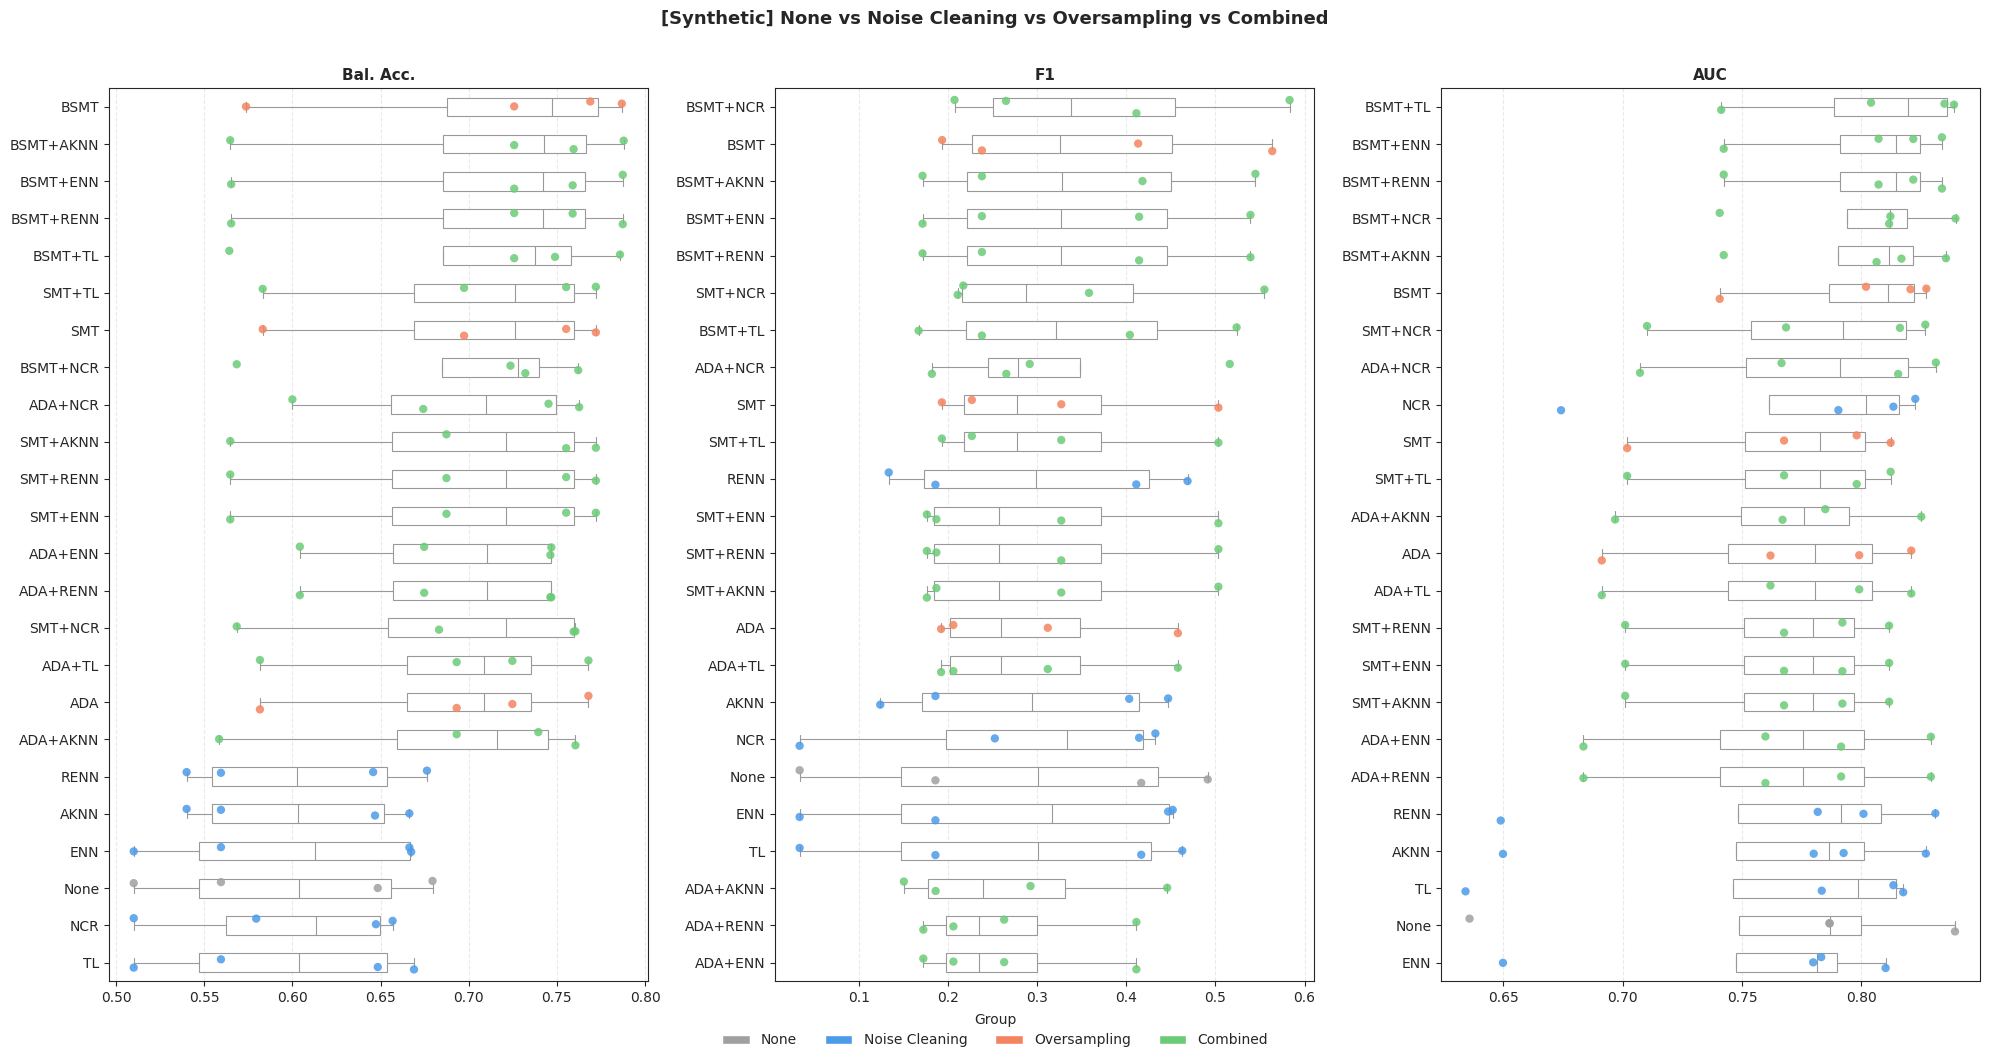

[Synthetic] Fig 1 saved.


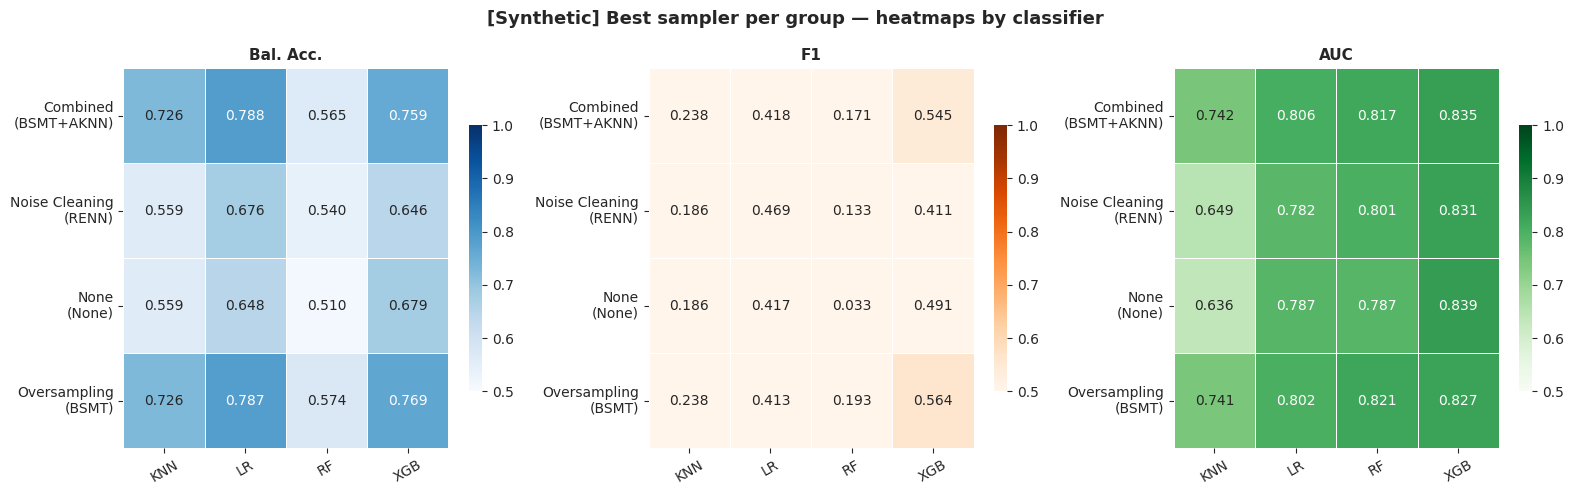

[Synthetic] Fig 2 saved.


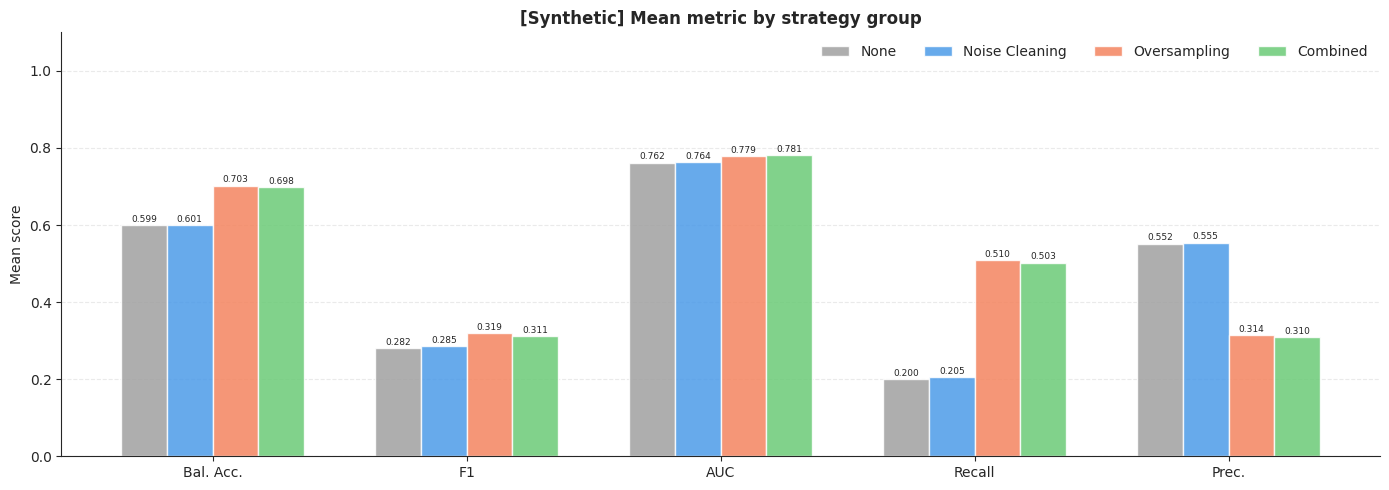

[Synthetic] Fig 3 saved.


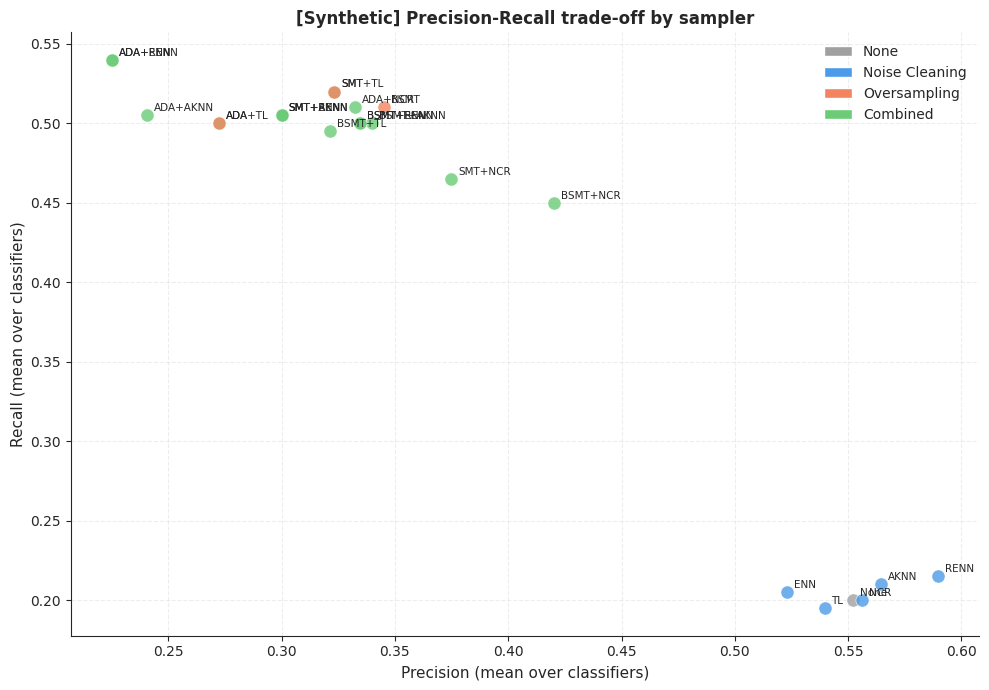

[Synthetic] Fig 4 saved.

[Synthetic] Best individual run per classifier:
Clf        Group   Sampler  balanced_accuracy     f1  roc_auc  recall  precision
 LR     Combined BSMT+AKNN             0.7879 0.4181   0.8063    0.66     0.3146
XGB Oversampling      BSMT             0.7689 0.5637   0.8272    0.56     0.6143
KNN     Combined  BSMT+ENN             0.7258 0.2379   0.7423    0.66     0.1457
 RF     Combined  ADA+RENN             0.6042 0.2059   0.7915    0.24     0.2004


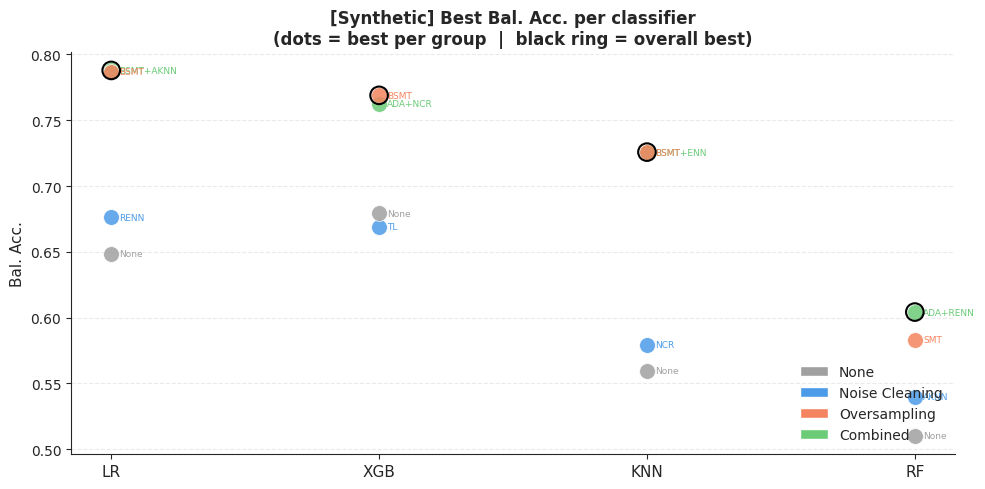

[Synthetic] Fig 5 saved.


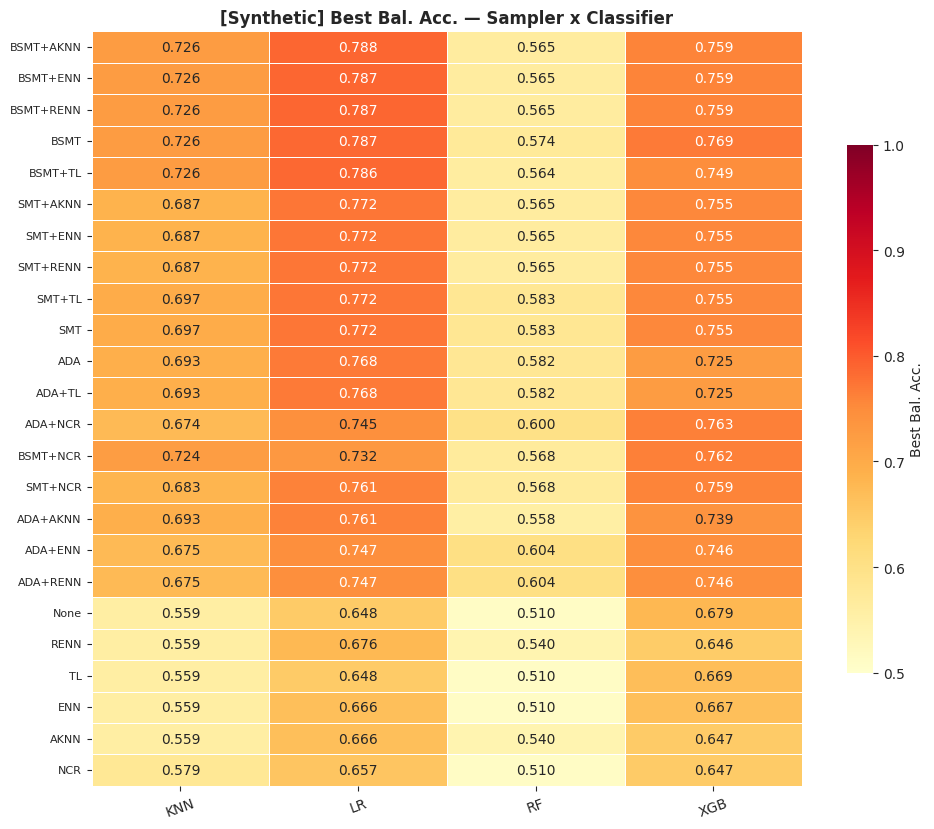

[Synthetic] Fig 6 saved.


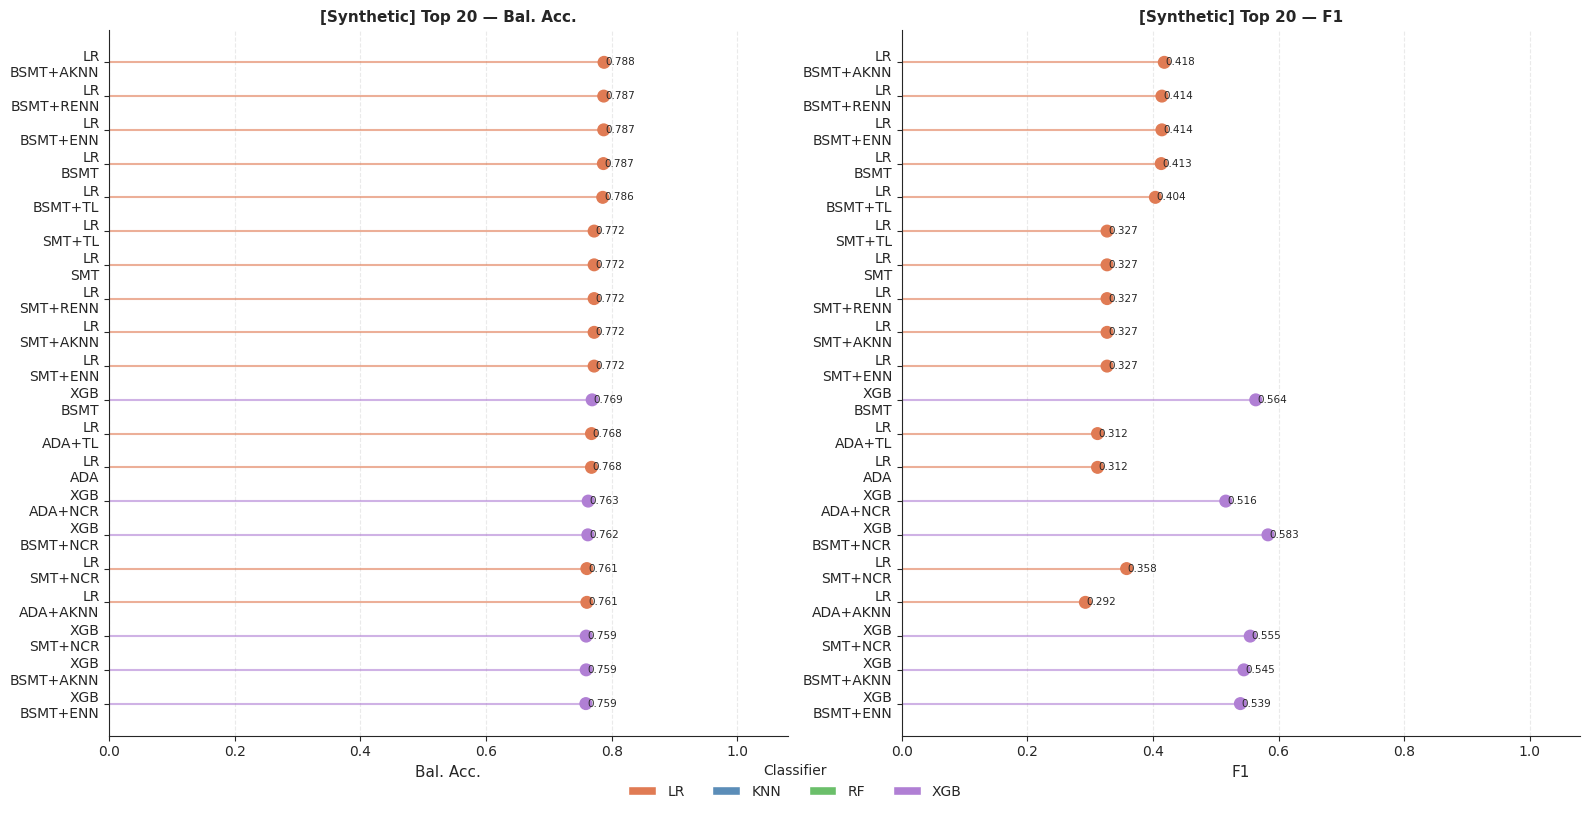

[Synthetic] Fig 7 saved.


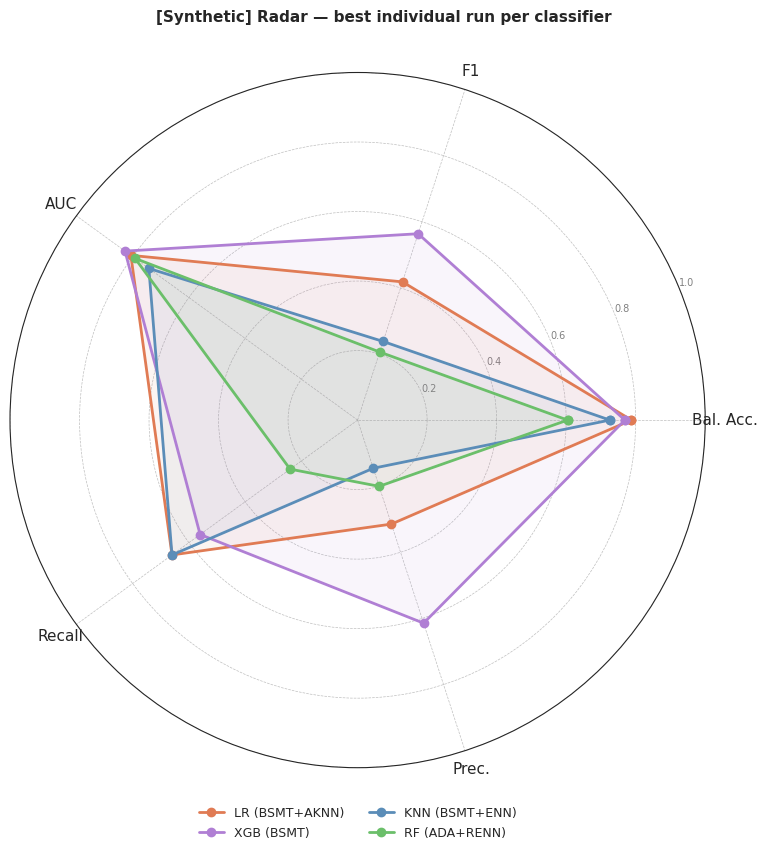

[Synthetic] Fig 8 saved.


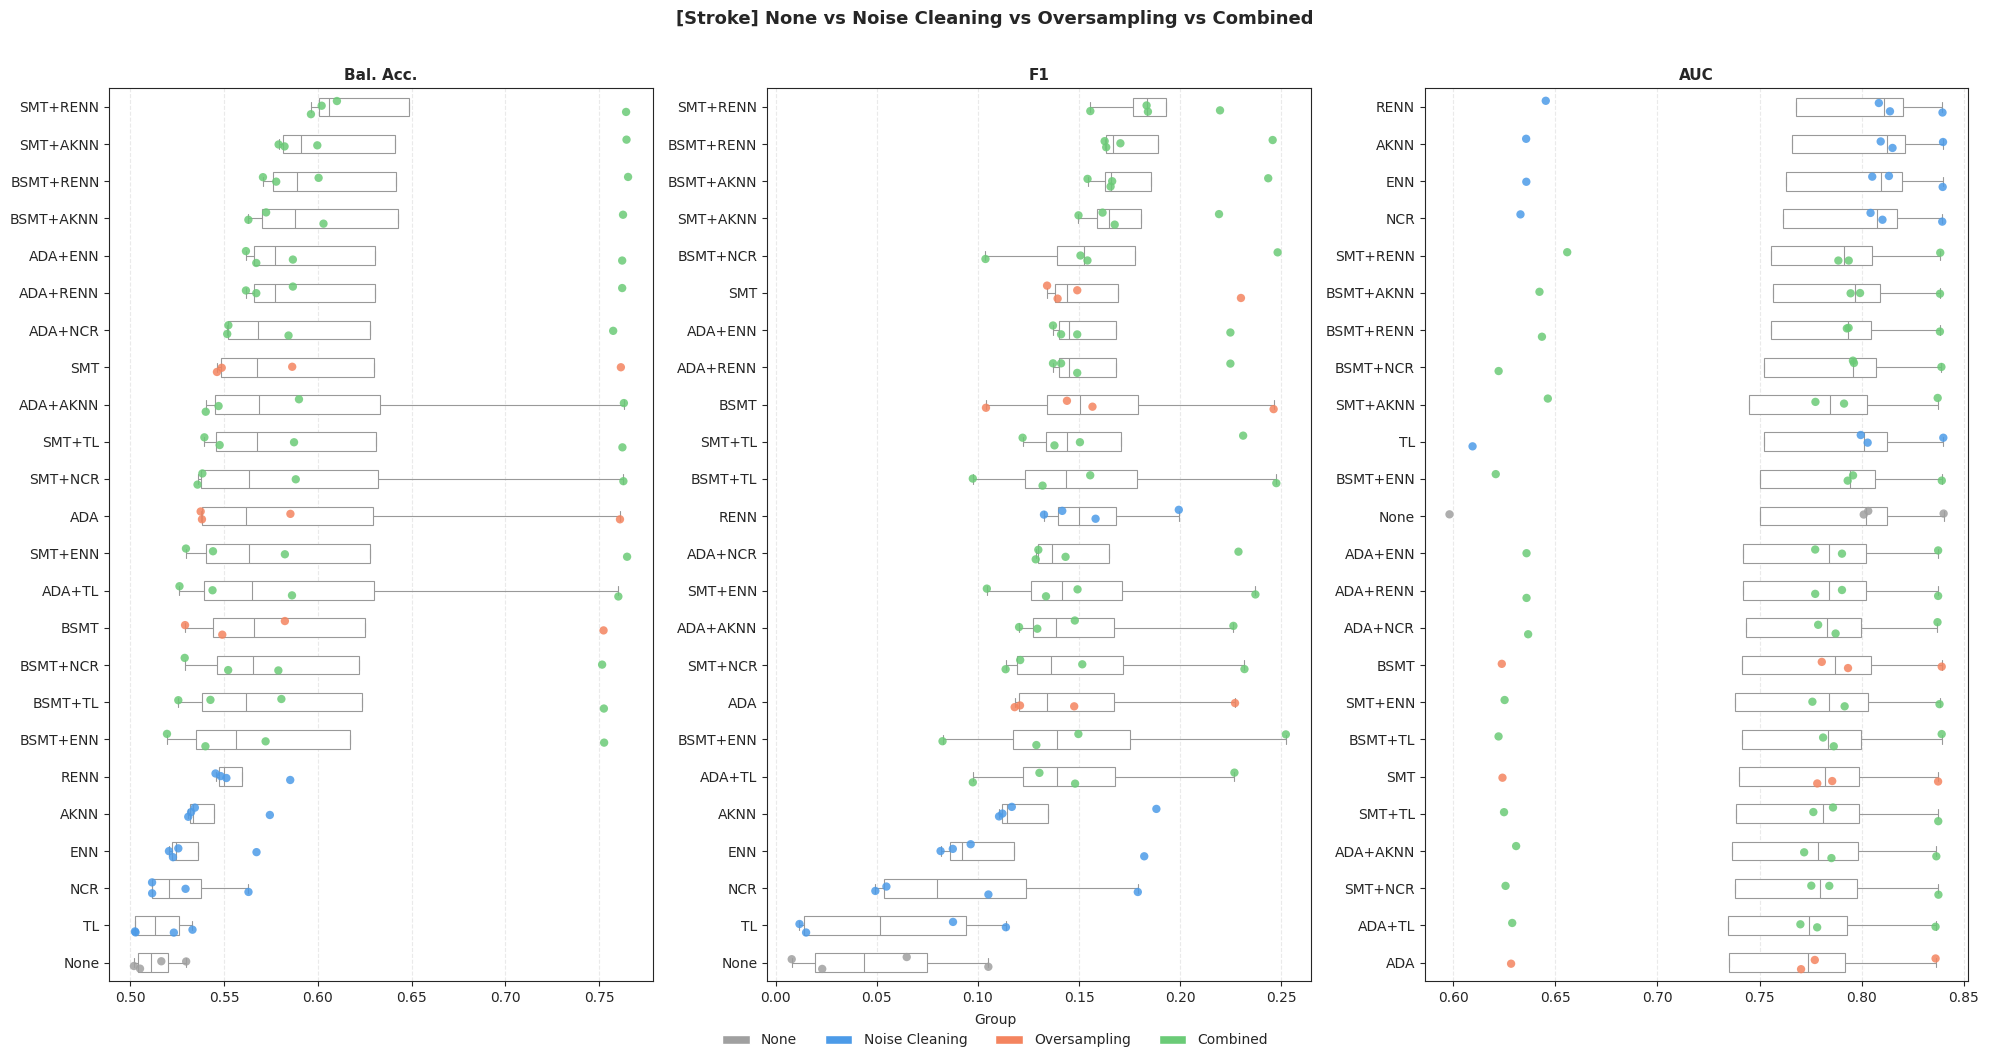

[Stroke] Fig 1 saved.


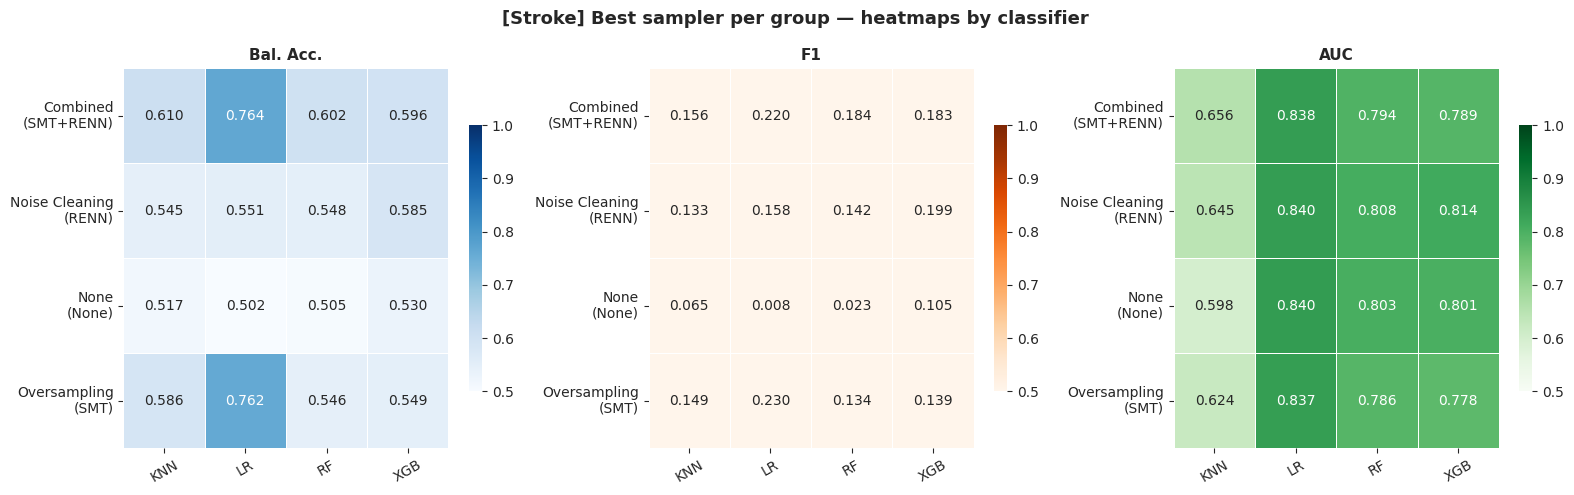

[Stroke] Fig 2 saved.


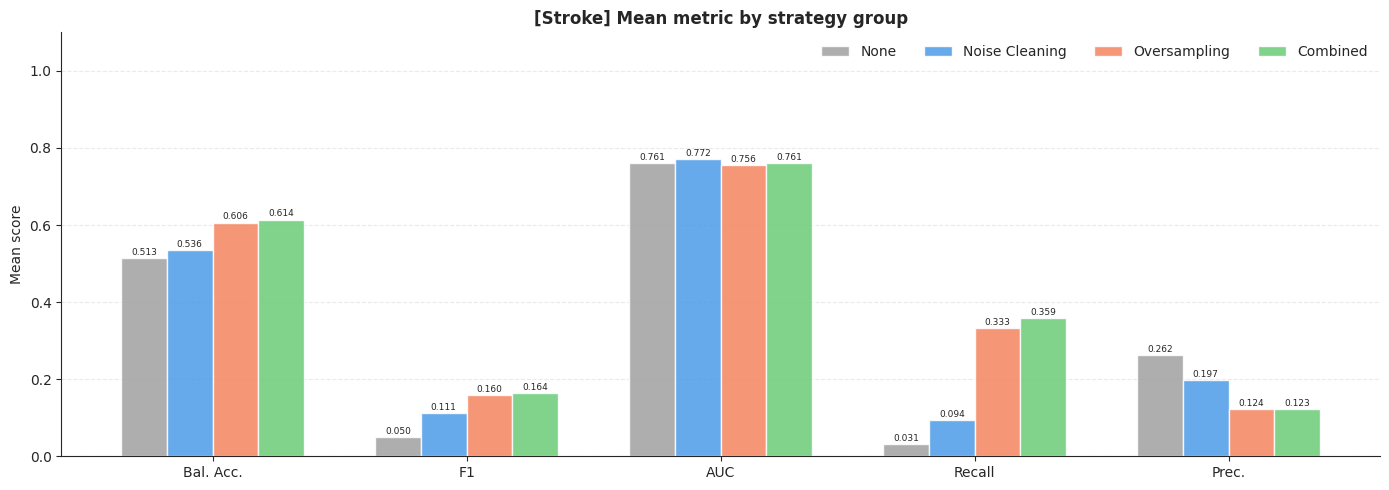

[Stroke] Fig 3 saved.


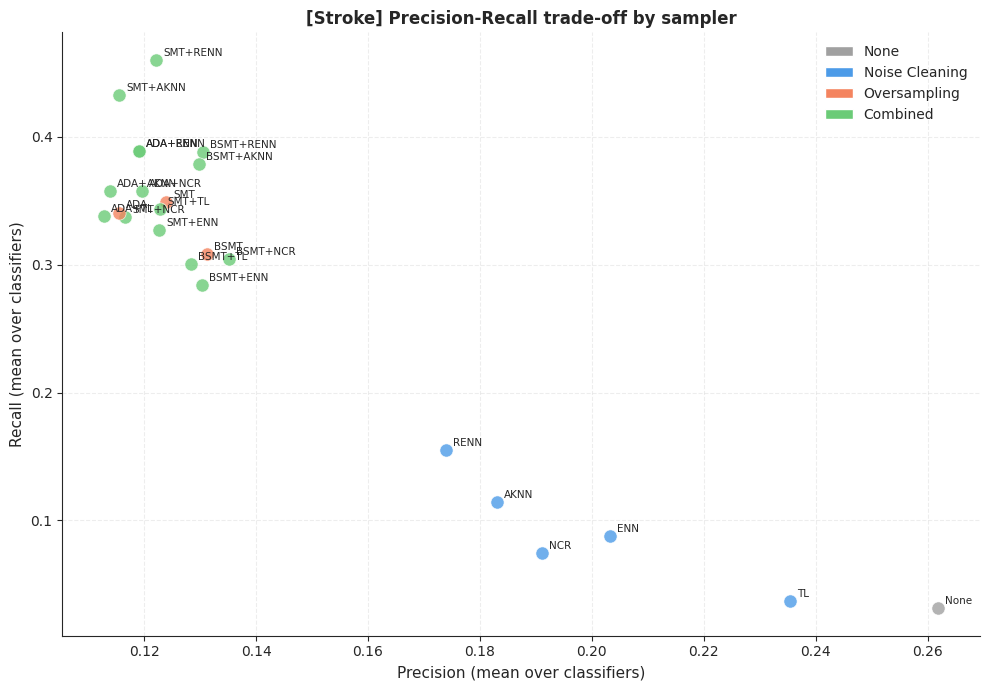

[Stroke] Fig 4 saved.

[Stroke] Best individual run per classifier:
Clf    Group   Sampler  balanced_accuracy     f1  roc_auc  recall  precision
 LR Combined BSMT+RENN             0.7654 0.2457   0.8383  0.7570     0.1468
KNN Combined  SMT+RENN             0.6102 0.1556   0.6558  0.4297     0.0950
 RF Combined  SMT+RENN             0.6020 0.1841   0.7936  0.3073     0.1316
XGB Combined  SMT+RENN             0.5963 0.1834   0.7885  0.2873     0.1351


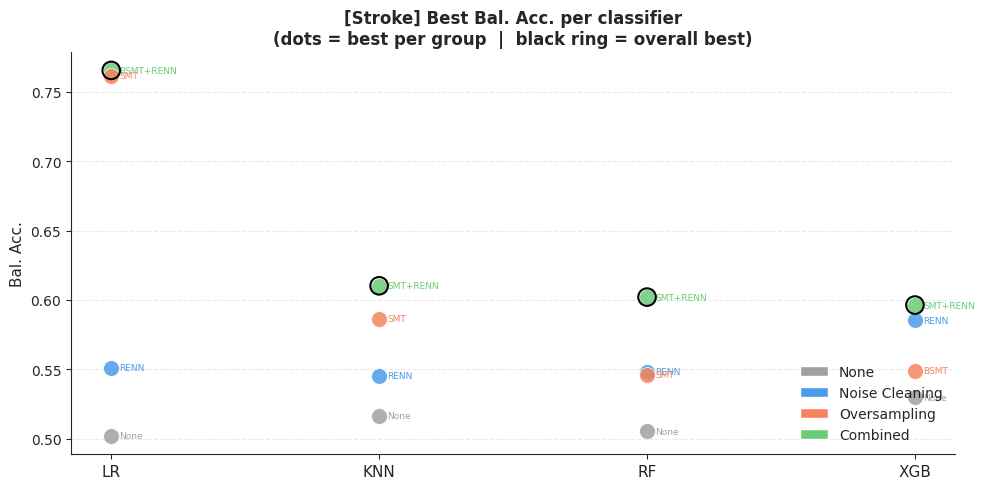

[Stroke] Fig 5 saved.


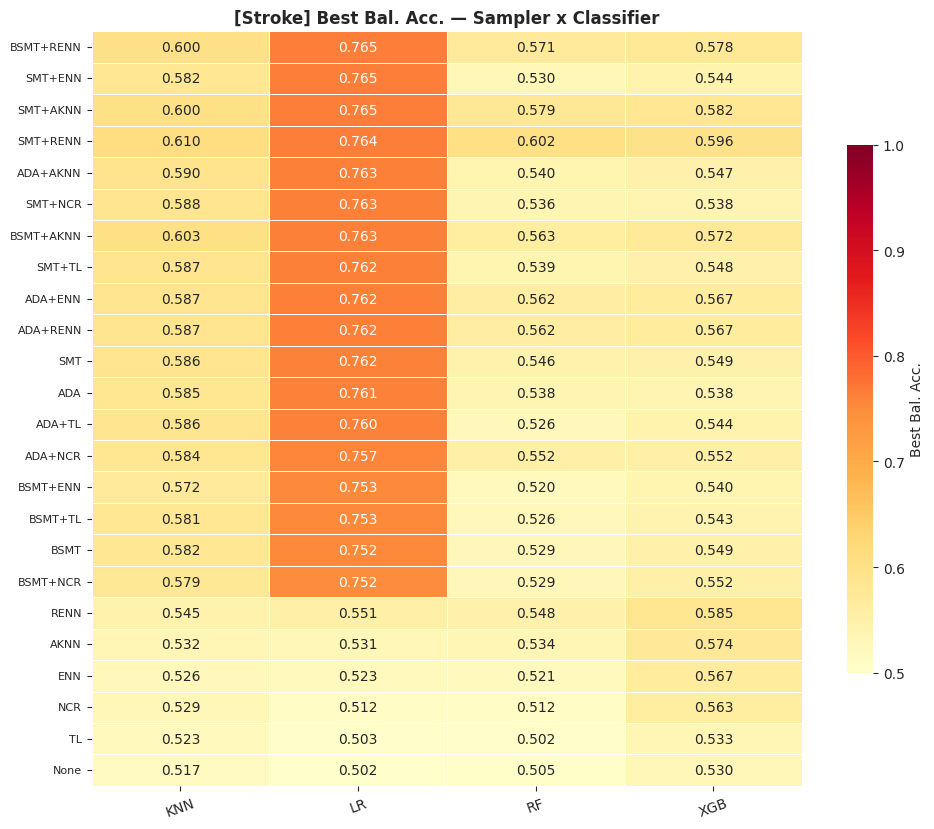

[Stroke] Fig 6 saved.


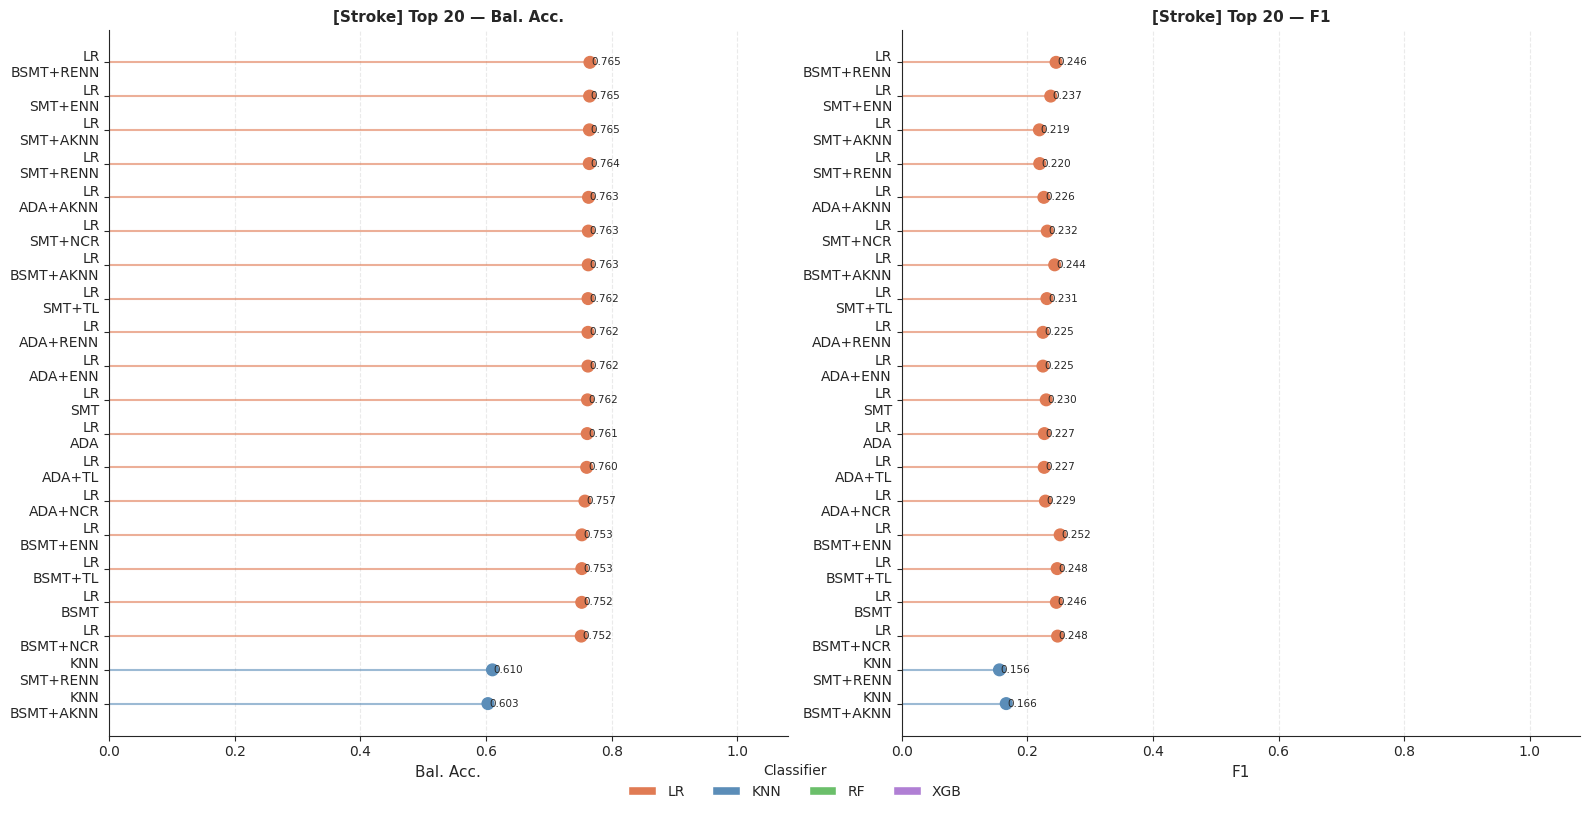

[Stroke] Fig 7 saved.


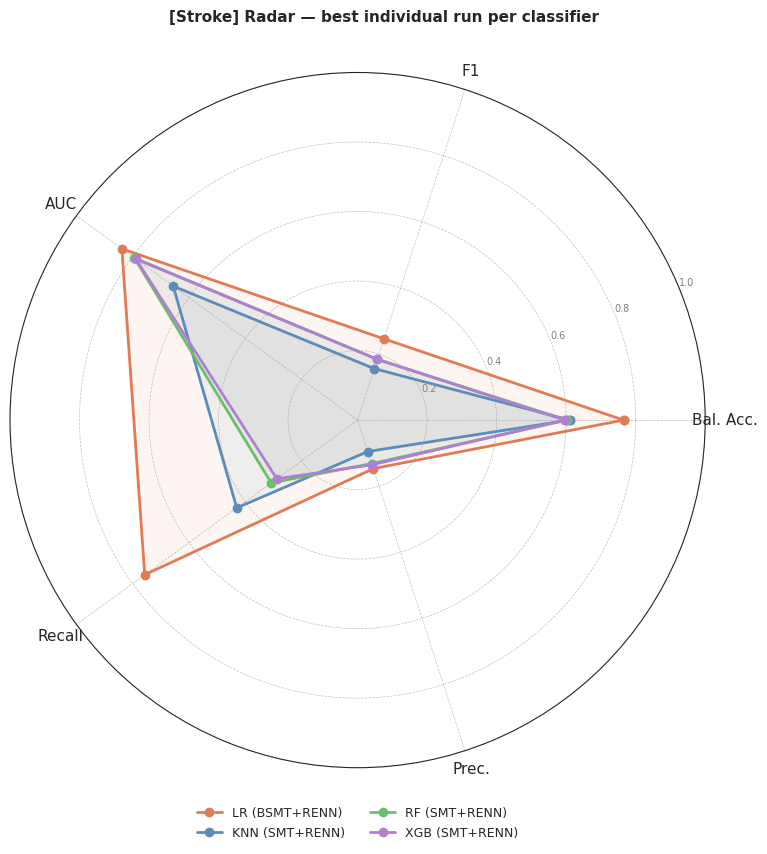

[Stroke] Fig 8 saved.


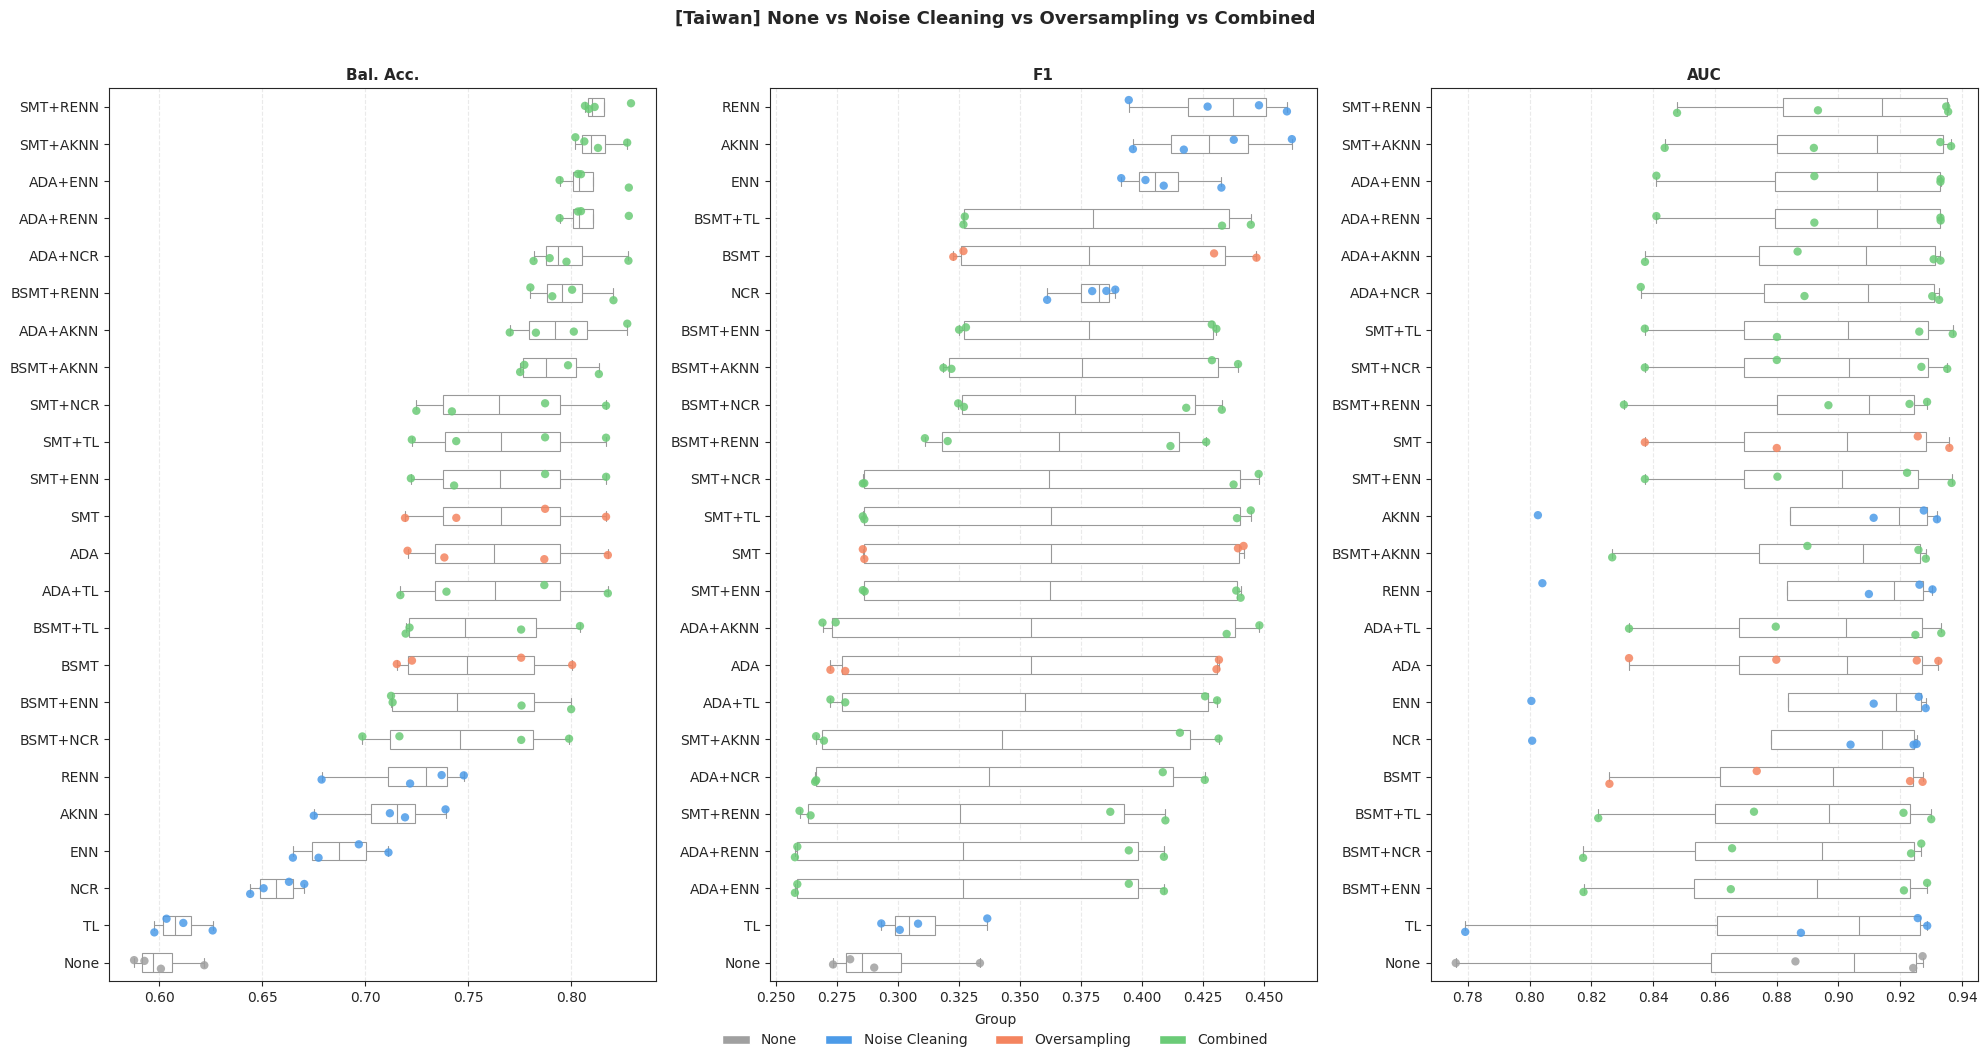

[Taiwan] Fig 1 saved.


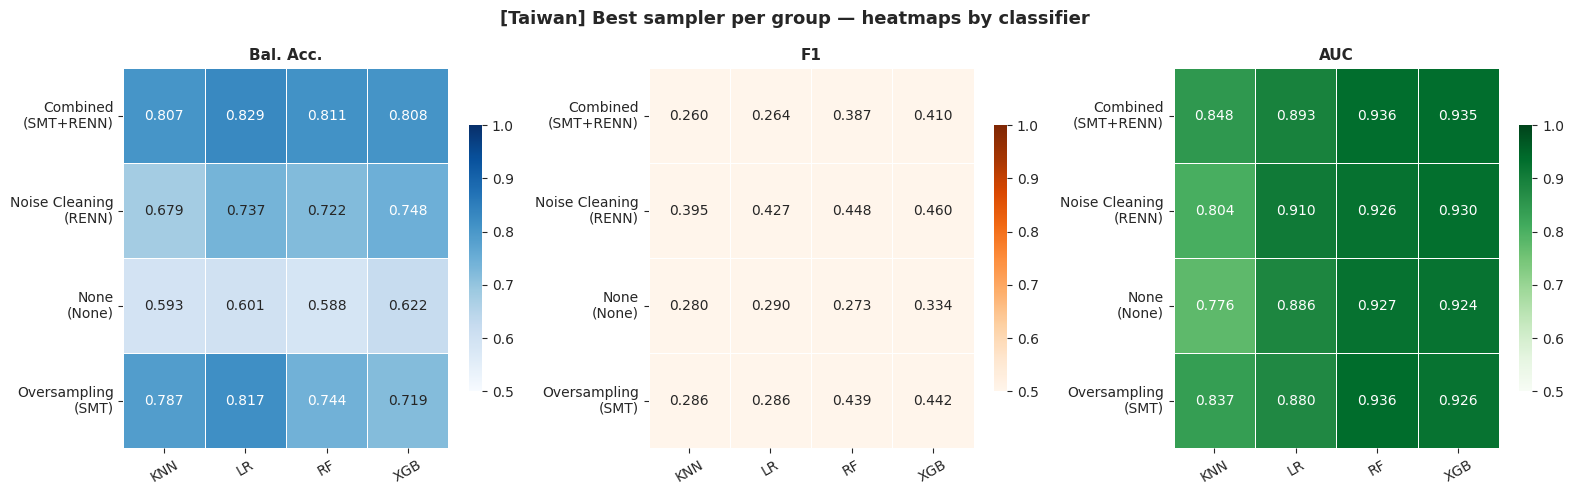

[Taiwan] Fig 2 saved.


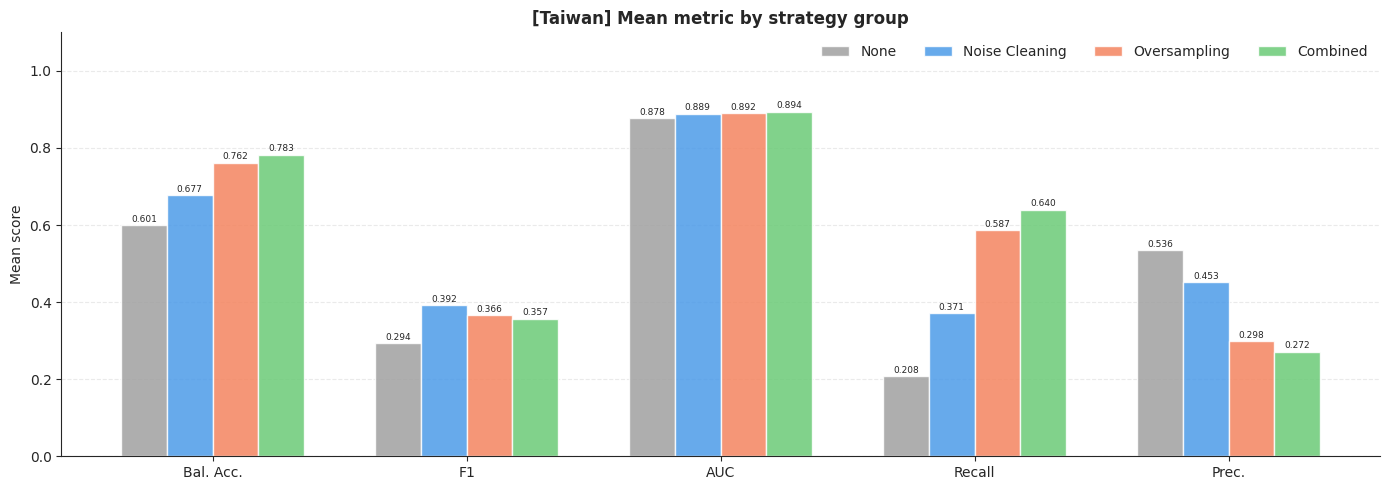

[Taiwan] Fig 3 saved.


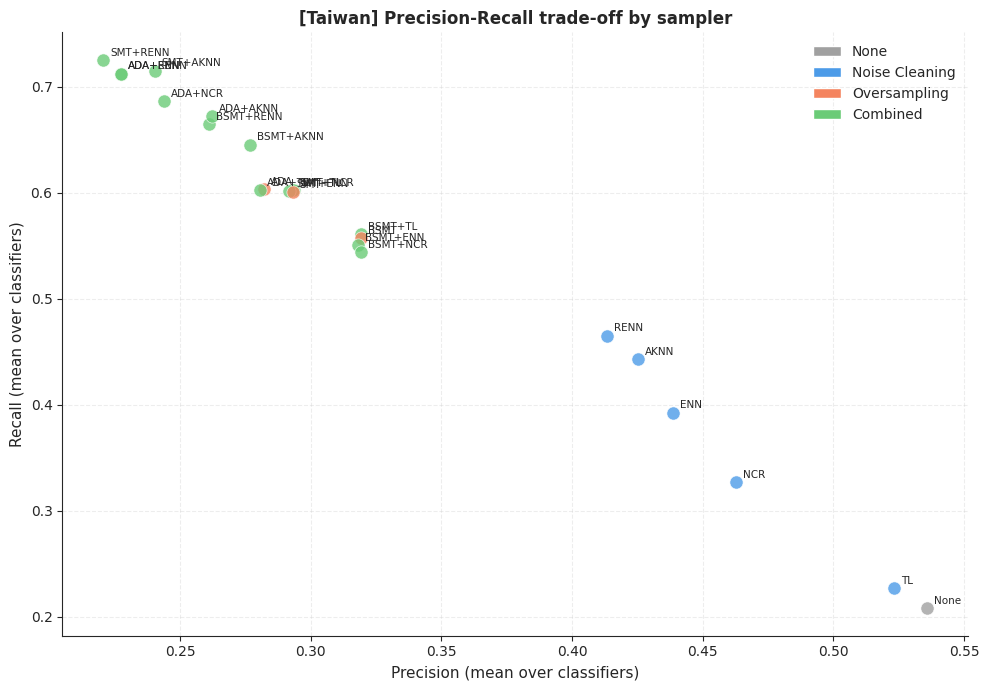

[Taiwan] Fig 4 saved.

[Taiwan] Best individual run per classifier:
Clf    Group  Sampler  balanced_accuracy     f1  roc_auc  recall  precision
 LR Combined SMT+RENN             0.8289 0.2641   0.8934  0.8000     0.1583
 RF Combined SMT+AKNN             0.8129 0.4156   0.9365  0.6795     0.3054
XGB Combined SMT+RENN             0.8085 0.4097   0.9349  0.6705     0.2960
KNN Combined SMT+RENN             0.8066 0.2595   0.8478  0.7477     0.1574


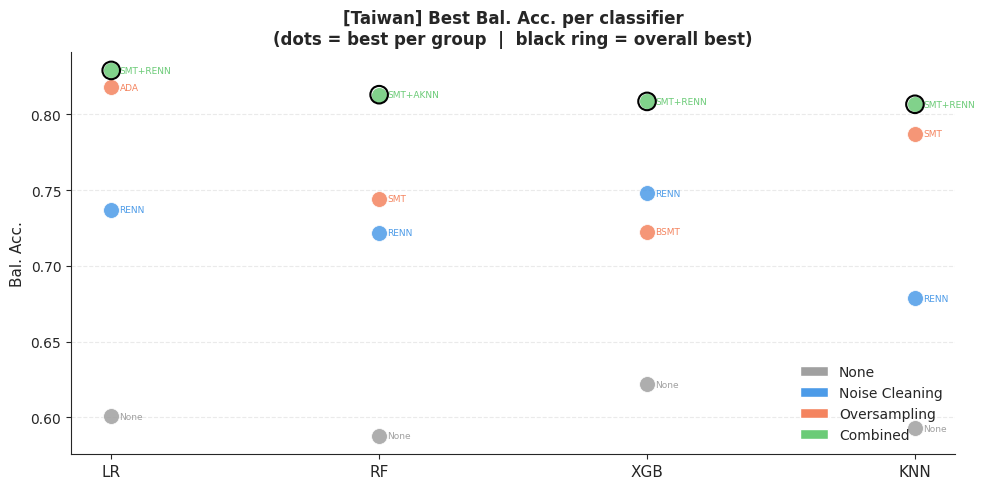

[Taiwan] Fig 5 saved.


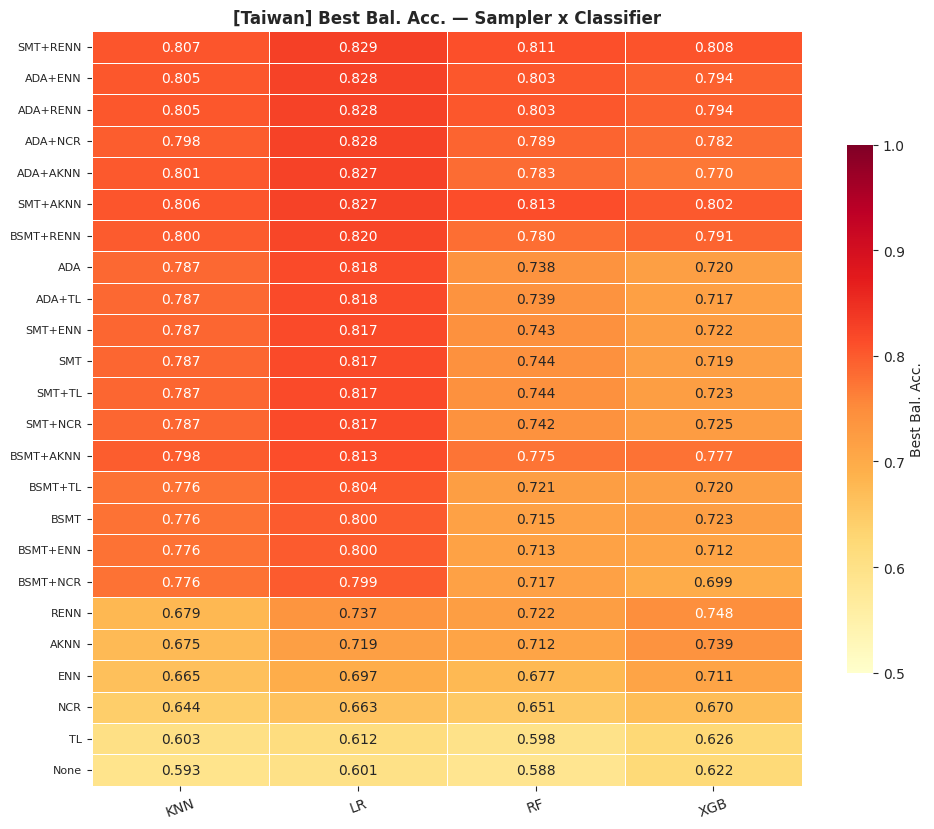

[Taiwan] Fig 6 saved.


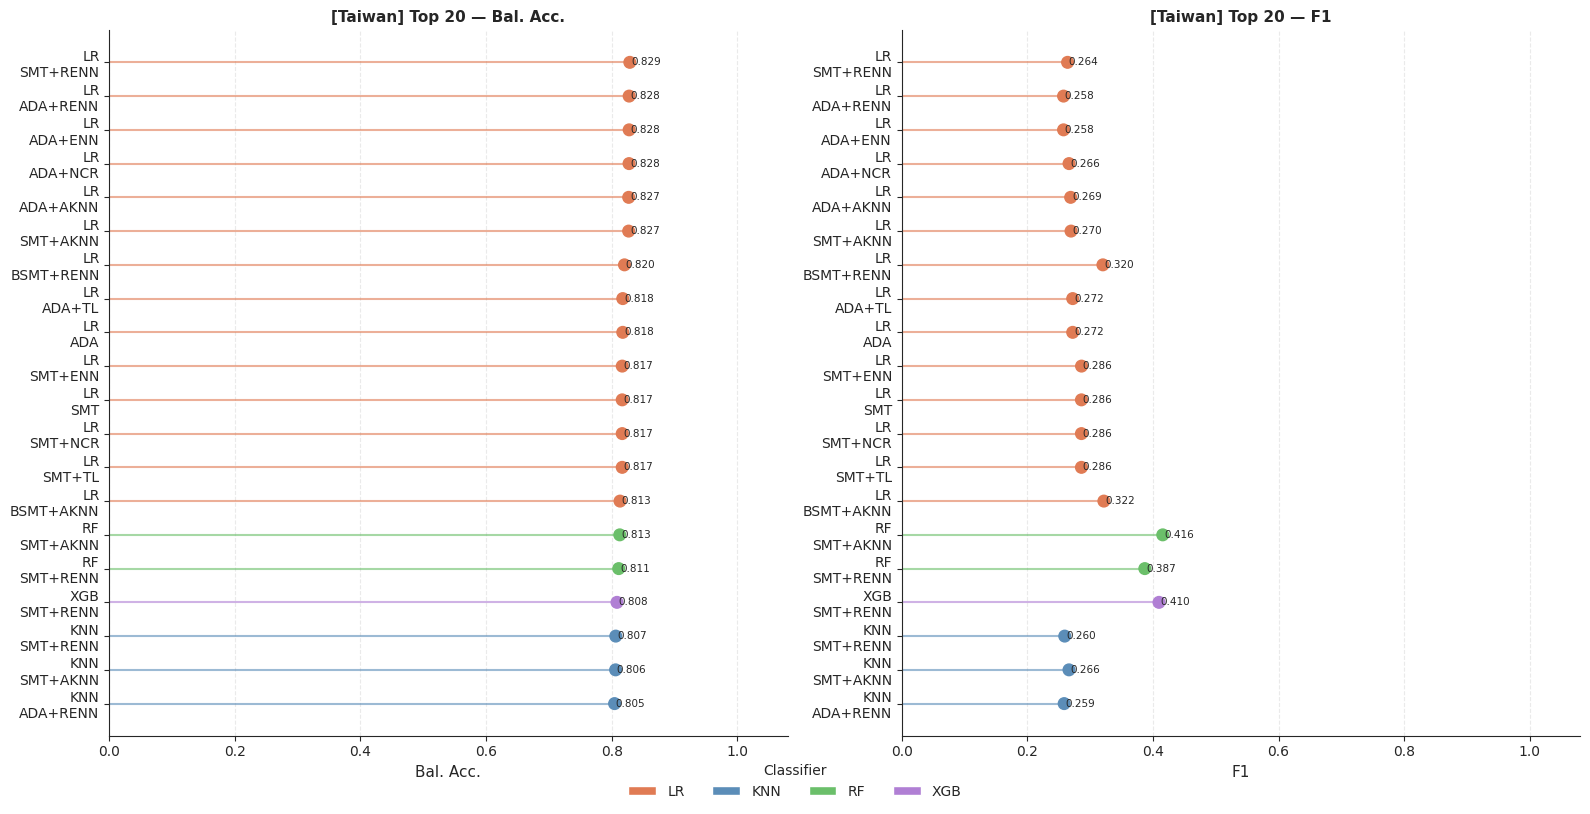

[Taiwan] Fig 7 saved.


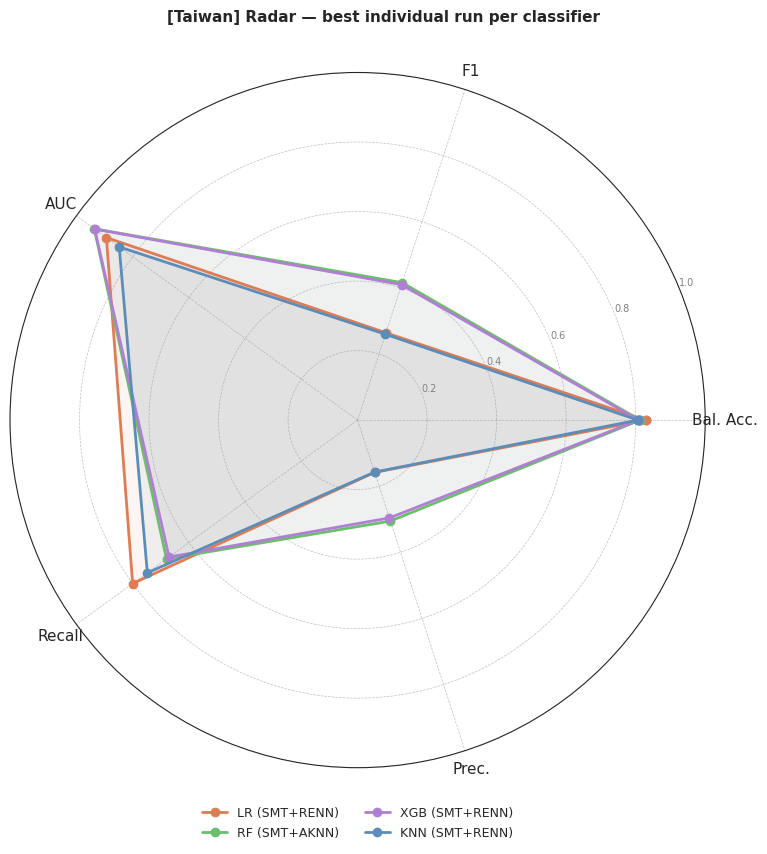

[Taiwan] Fig 8 saved.


In [7]:
# ===================================================================
# 9. Colour maps
# ===================================================================
GROUP_COLORS = {
    "None":           "#A0A0A0",
    "Noise Cleaning": "#4C9BE8",
    "Oversampling":     "#F4845F",
    "Combined":       "#6BCB77",
}
CLF_COLORS = {
    "LR":  "#E07B54",
    "KNN": "#5B8DB8",
    "RF":  "#6BBF6A",
    "XGB": "#B07FD4",
}
DS_COLORS = {
    "Synthetic": "#A0A0A0",
    "Stroke":    "#4C9BE8",
    "Taiwan":    "#F4845F",
}

# ===================================================================
# 10. Per-dataset visualisations
# ===================================================================

def strip_plot_metric(ax, data, metric, title):
    order = (
        data.groupby("Sampler")[metric]
        .mean().sort_values(ascending=False).index.tolist()
    )
    sns.boxplot(
        data=data, x=metric, y="Sampler", order=order,
        color="white", linewidth=.8, fliersize=0, width=.5, ax=ax
    )
    sns.stripplot(
        data=data, x=metric, y="Sampler", order=order,
        hue="Group", palette=GROUP_COLORS,
        size=6, alpha=.85, jitter=.2, legend=False, ax=ax
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")


for ds_name, (df, df_fold) in all_results.items():
    tag = ds_name.lower()
    df_agg = (
        df.groupby(["Group", "Sampler"])[METRICS]
        .mean().reset_index()
        .sort_values("balanced_accuracy", ascending=False)
    )

    # Fig 1 — Strip plots
    fig1, axes1 = plt.subplots(1, 3, figsize=(20, 10), sharey=False)
    fig1.suptitle(
        f"[{ds_name}] None vs Noise Cleaning vs Oversampling vs Combined",
        fontsize=13, fontweight="bold", y=1.01,
    )
    for ax, metric, label in zip(
        axes1,
        ["balanced_accuracy", "f1", "roc_auc"],
        ["Bal. Acc.", "F1", "AUC"],
    ):
        strip_plot_metric(ax, df, metric, label)
        ax.grid(axis="x", linestyle="--", alpha=.4)
    fig1.legend(
        handles=[
            Patch(facecolor=c, label=g)
            for g, c in GROUP_COLORS.items()
        ],
        title="Group", loc="lower center", ncol=4,
        bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=10,
    )
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"fig1_{tag}_strip.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show(); print(f"[{ds_name}] Fig 1 saved.")

    # Fig 2 — Best-per-group heatmap
    best_samplers = (
        df_agg.groupby("Group")
        .apply(lambda g: g.nlargest(1, "balanced_accuracy"))
        .reset_index(drop=True)["Sampler"].tolist()
    )
    df_heat = df[df["Sampler"].isin(best_samplers)].copy()
    df_heat["Label"] = (
        df_heat["Group"] + "\n(" + df_heat["Sampler"] + ")"
    )
    fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
    fig2.suptitle(
        f"[{ds_name}] Best sampler per group — heatmaps by classifier",
        fontsize=13, fontweight="bold",
    )
    for ax, metric, title, cmap in zip(
        axes2,
        ["balanced_accuracy", "f1", "roc_auc"],
        ["Bal. Acc.", "F1", "AUC"],
        ["Blues", "Oranges", "Greens"],
    ):
        pivot = df_heat.pivot_table(
            index="Label", columns="Clf", values=metric
        )
        sns.heatmap(
            pivot, annot=True, fmt=".3f", cmap=cmap,
            linewidths=.5, ax=ax, vmin=0.5, vmax=1.0,
            cbar_kws={"shrink": .7},
        )
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"fig2_{tag}_best_group_heatmap.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show(); print(f"[{ds_name}] Fig 2 saved.")

    # Fig 3 — Grouped bar
    df_gm = (
        df.groupby("Group")[METRICS].mean().reset_index()
        .melt(id_vars="Group", var_name="Metric", value_name="Score")
    )
    fig3, ax3 = plt.subplots(figsize=(14, 5))
    x       = np.arange(len(METRICS))
    width   = 0.18
    offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]
    for grp, offset in zip(list(GROUP_COLORS), offsets):
        subset = df_gm[df_gm["Group"] == grp]
        vals   = [
            subset[subset["Metric"] == m]["Score"].values[0]
            for m in METRICS
        ]
        bars = ax3.bar(
            x + offset, vals, width, label=grp,
            color=GROUP_COLORS[grp], alpha=.85, edgecolor="white",
        )
        for bar, v in zip(bars, vals):
            ax3.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + .003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=6.5,
            )
    ax3.set_xticks(x)
    ax3.set_xticklabels(
        ["Bal. Acc.", "F1", "AUC", "Recall", "Prec."],
        fontsize=10,
    )
    ax3.set_ylim(0, 1.1)
    ax3.set_ylabel("Mean score")
    ax3.set_title(
        f"[{ds_name}] Mean metric by strategy group",
        fontsize=12, fontweight="bold",
    )
    ax3.legend(frameon=False, ncol=4)
    ax3.grid(axis="y", linestyle="--", alpha=.4)
    sns.despine(); plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"fig3_{tag}_group_bar.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show(); print(f"[{ds_name}] Fig 3 saved.")

    # Fig 4 — Precision-Recall scatter
    fig4, ax4 = plt.subplots(figsize=(10, 7))
    for _, row in df_agg.iterrows():
        ax4.scatter(
            row["precision"], row["recall"],
            color=GROUP_COLORS[row["Group"]],
            s=90, alpha=.8, edgecolors="white", linewidths=.5,
        )
        ax4.annotate(
            row["Sampler"],
            (row["precision"], row["recall"]),
            textcoords="offset points", xytext=(5, 3), fontsize=7.5,
        )
    ax4.set_xlabel("Precision (mean over classifiers)", fontsize=11)
    ax4.set_ylabel("Recall (mean over classifiers)", fontsize=11)
    ax4.set_title(
        f"[{ds_name}] Precision-Recall trade-off by sampler",
        fontsize=12, fontweight="bold",
    )
    ax4.legend(
        handles=[
            Patch(facecolor=c, label=g)
            for g, c in GROUP_COLORS.items()
        ],
        frameon=False,
    )
    ax4.grid(linestyle="--", alpha=.35); sns.despine()
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"fig4_{tag}_pr_scatter.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show(); print(f"[{ds_name}] Fig 4 saved.")

    # Classifier best runs
    df_clf_best = (
        df.sort_values("balanced_accuracy", ascending=False)
          .groupby("Clf", sort=False).first().reset_index()
          [["Clf", "Group", "Sampler"] + METRICS]
          .sort_values("balanced_accuracy", ascending=False)
    )
    df_clf_group_best = (
        df.sort_values("balanced_accuracy", ascending=False)
          .groupby(["Group", "Clf"], sort=False).first().reset_index()
          [["Group", "Clf", "Sampler"] + METRICS]
          .sort_values(
              ["Group", "balanced_accuracy"],
              ascending=[True, False],
          )
    )
    print(f"\n[{ds_name}] Best individual run per classifier:")
    print(df_clf_best.round(4).to_string(index=False))

    # Fig 5 — Dot plot
    fig5, ax5 = plt.subplots(figsize=(10, 5))
    clf_order = df_clf_best["Clf"].tolist()
    for _, row in df_clf_group_best.iterrows():
        xi = clf_order.index(row["Clf"])
        ax5.scatter(
            xi, row["balanced_accuracy"],
            color=GROUP_COLORS[row["Group"]], s=130,
            alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3,
        )
        ax5.annotate(
            row["Sampler"], (xi, row["balanced_accuracy"]),
            textcoords="offset points", xytext=(6, 0),
            fontsize=6.5, color=GROUP_COLORS[row["Group"]], va="center",
        )
    for _, row in df_clf_best.iterrows():
        xi = clf_order.index(row["Clf"])
        ax5.scatter(
            xi, row["balanced_accuracy"],
            facecolors="none", edgecolors="black",
            s=160, linewidths=1.5, zorder=4,
        )
    ax5.set_xticks(range(len(clf_order)))
    ax5.set_xticklabels(clf_order, fontsize=11)
    ax5.set_ylabel("Bal. Acc.", fontsize=11)
    ax5.set_title(
        f"[{ds_name}] Best Bal. Acc. per classifier\n"
        "(dots = best per group  |  black ring = overall best)",
        fontsize=12, fontweight="bold",
    )
    ax5.grid(axis="y", linestyle="--", alpha=0.4)
    ax5.legend(
        handles=[
            Patch(facecolor=c, label=g)
            for g, c in GROUP_COLORS.items()
        ],
        frameon=False, loc="lower right",
    )
    sns.despine(); plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"fig5_{tag}_clf_dot.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show(); print(f"[{ds_name}] Fig 5 saved.")

    # Fig 6 — Full sampler x classifier heatmap
    pivot_best = df.pivot_table(
        index="Sampler", columns="Clf",
        values="balanced_accuracy", aggfunc="max",
    ).loc[
        lambda d: d.max(axis=1).sort_values(ascending=False).index
    ]
    fig6, ax6 = plt.subplots(
        figsize=(10, max(6, len(pivot_best) * 0.35))
    )
    sns.heatmap(
        pivot_best, annot=True, fmt=".3f", cmap="YlOrRd",
        linewidths=0.4, ax=ax6, vmin=0.5, vmax=1.0,
        cbar_kws={"label": "Best Bal. Acc.", "shrink": 0.7},
    )
    ax6.set_title(
        f"[{ds_name}] Best Bal. Acc. — Sampler x Classifier",
        fontsize=12, fontweight="bold",
    )
    ax6.set_xlabel(""); ax6.set_ylabel("")
    ax6.tick_params(axis="x", rotation=20)
    ax6.tick_params(axis="y", rotation=0, labelsize=8)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"fig6_{tag}_sampler_clf_heatmap.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show(); print(f"[{ds_name}] Fig 6 saved.")

    # Fig 7 — Lollipop top 20
    top20 = (
        df.sort_values("balanced_accuracy", ascending=False)
          .head(20)
          .assign(label=lambda d: d["Clf"] + "\n" + d["Sampler"])
          .sort_values("balanced_accuracy")
    )
    fig7, axes7 = plt.subplots(1, 2, figsize=(16, 8))
    for ax, metric, title in zip(
        axes7,
        ["balanced_accuracy", "f1"],
        ["Bal. Acc.", "F1"],
    ):
        colors = [CLF_COLORS[c] for c in top20["Clf"]]
        ax.hlines(
            top20["label"], 0, top20[metric],
            color=colors, linewidth=1.5, alpha=0.6,
        )
        ax.scatter(
            top20[metric], top20["label"],
            color=colors, s=70, zorder=3,
        )
        for _, row in top20.iterrows():
            ax.text(
                row[metric] + 0.002, row["label"],
                f"{row[metric]:.3f}", va="center", fontsize=7.5,
            )
        ax.set_xlabel(title, fontsize=11)
        ax.set_title(
            f"[{ds_name}] Top 20 — {title}",
            fontsize=11, fontweight="bold",
        )
        ax.set_xlim(0, 1.08)
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        sns.despine()
    fig7.legend(
        handles=[
            Patch(facecolor=c, label=cl)
            for cl, c in CLF_COLORS.items()
        ],
        title="Classifier", loc="lower center", ncol=4,
        bbox_to_anchor=(0.5, -0.02), frameon=False,
    )
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"fig7_{tag}_top20_lollipop.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show(); print(f"[{ds_name}] Fig 7 saved.")

    # Fig 8 — Radar
    angles = (
        np.linspace(0, 2 * np.pi, len(METRICS), endpoint=False)
        .tolist() + [0]
    )
    fig8 = plt.figure(figsize=(8, 9))
    fig8.suptitle(
        f"[{ds_name}] Radar — best individual run per classifier",
        fontsize=11, fontweight="bold", y=0.98,
    )
    ax8 = fig8.add_subplot(111, polar=True)
    for _, row in df_clf_best.iterrows():
        vals = [row[m] for m in METRICS] + [row[METRICS[0]]]
        ax8.plot(
            angles, vals, "o-", linewidth=2,
            label=f"{row['Clf']} ({row['Sampler']})",
            color=CLF_COLORS[row["Clf"]],
        )
        ax8.fill(
            angles, vals, alpha=0.07,
            color=CLF_COLORS[row["Clf"]],
        )
    ax8.set_xticks(angles[:-1])
    ax8.set_xticklabels(
        ["Bal. Acc.", "F1", "AUC", "Recall", "Prec."],
        fontsize=11,
    )
    ax8.set_ylim(0, 1)
    ax8.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax8.set_yticklabels(
        ["0.2","0.4","0.6","0.8","1.0"],
        fontsize=7, color="grey",
    )
    ax8.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.5)
    ax8.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.04),
        ncol=2, frameon=False, fontsize=9,
    )
    plt.tight_layout(rect=[0, 0.08, 1, 0.96])
    plt.savefig(
        OUTPUT_DIR / f"fig8_{tag}_radar.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show(); print(f"[{ds_name}] Fig 8 saved.")


##Cross-dataset comparison figures

###Heatmap: Samplers x Classifers

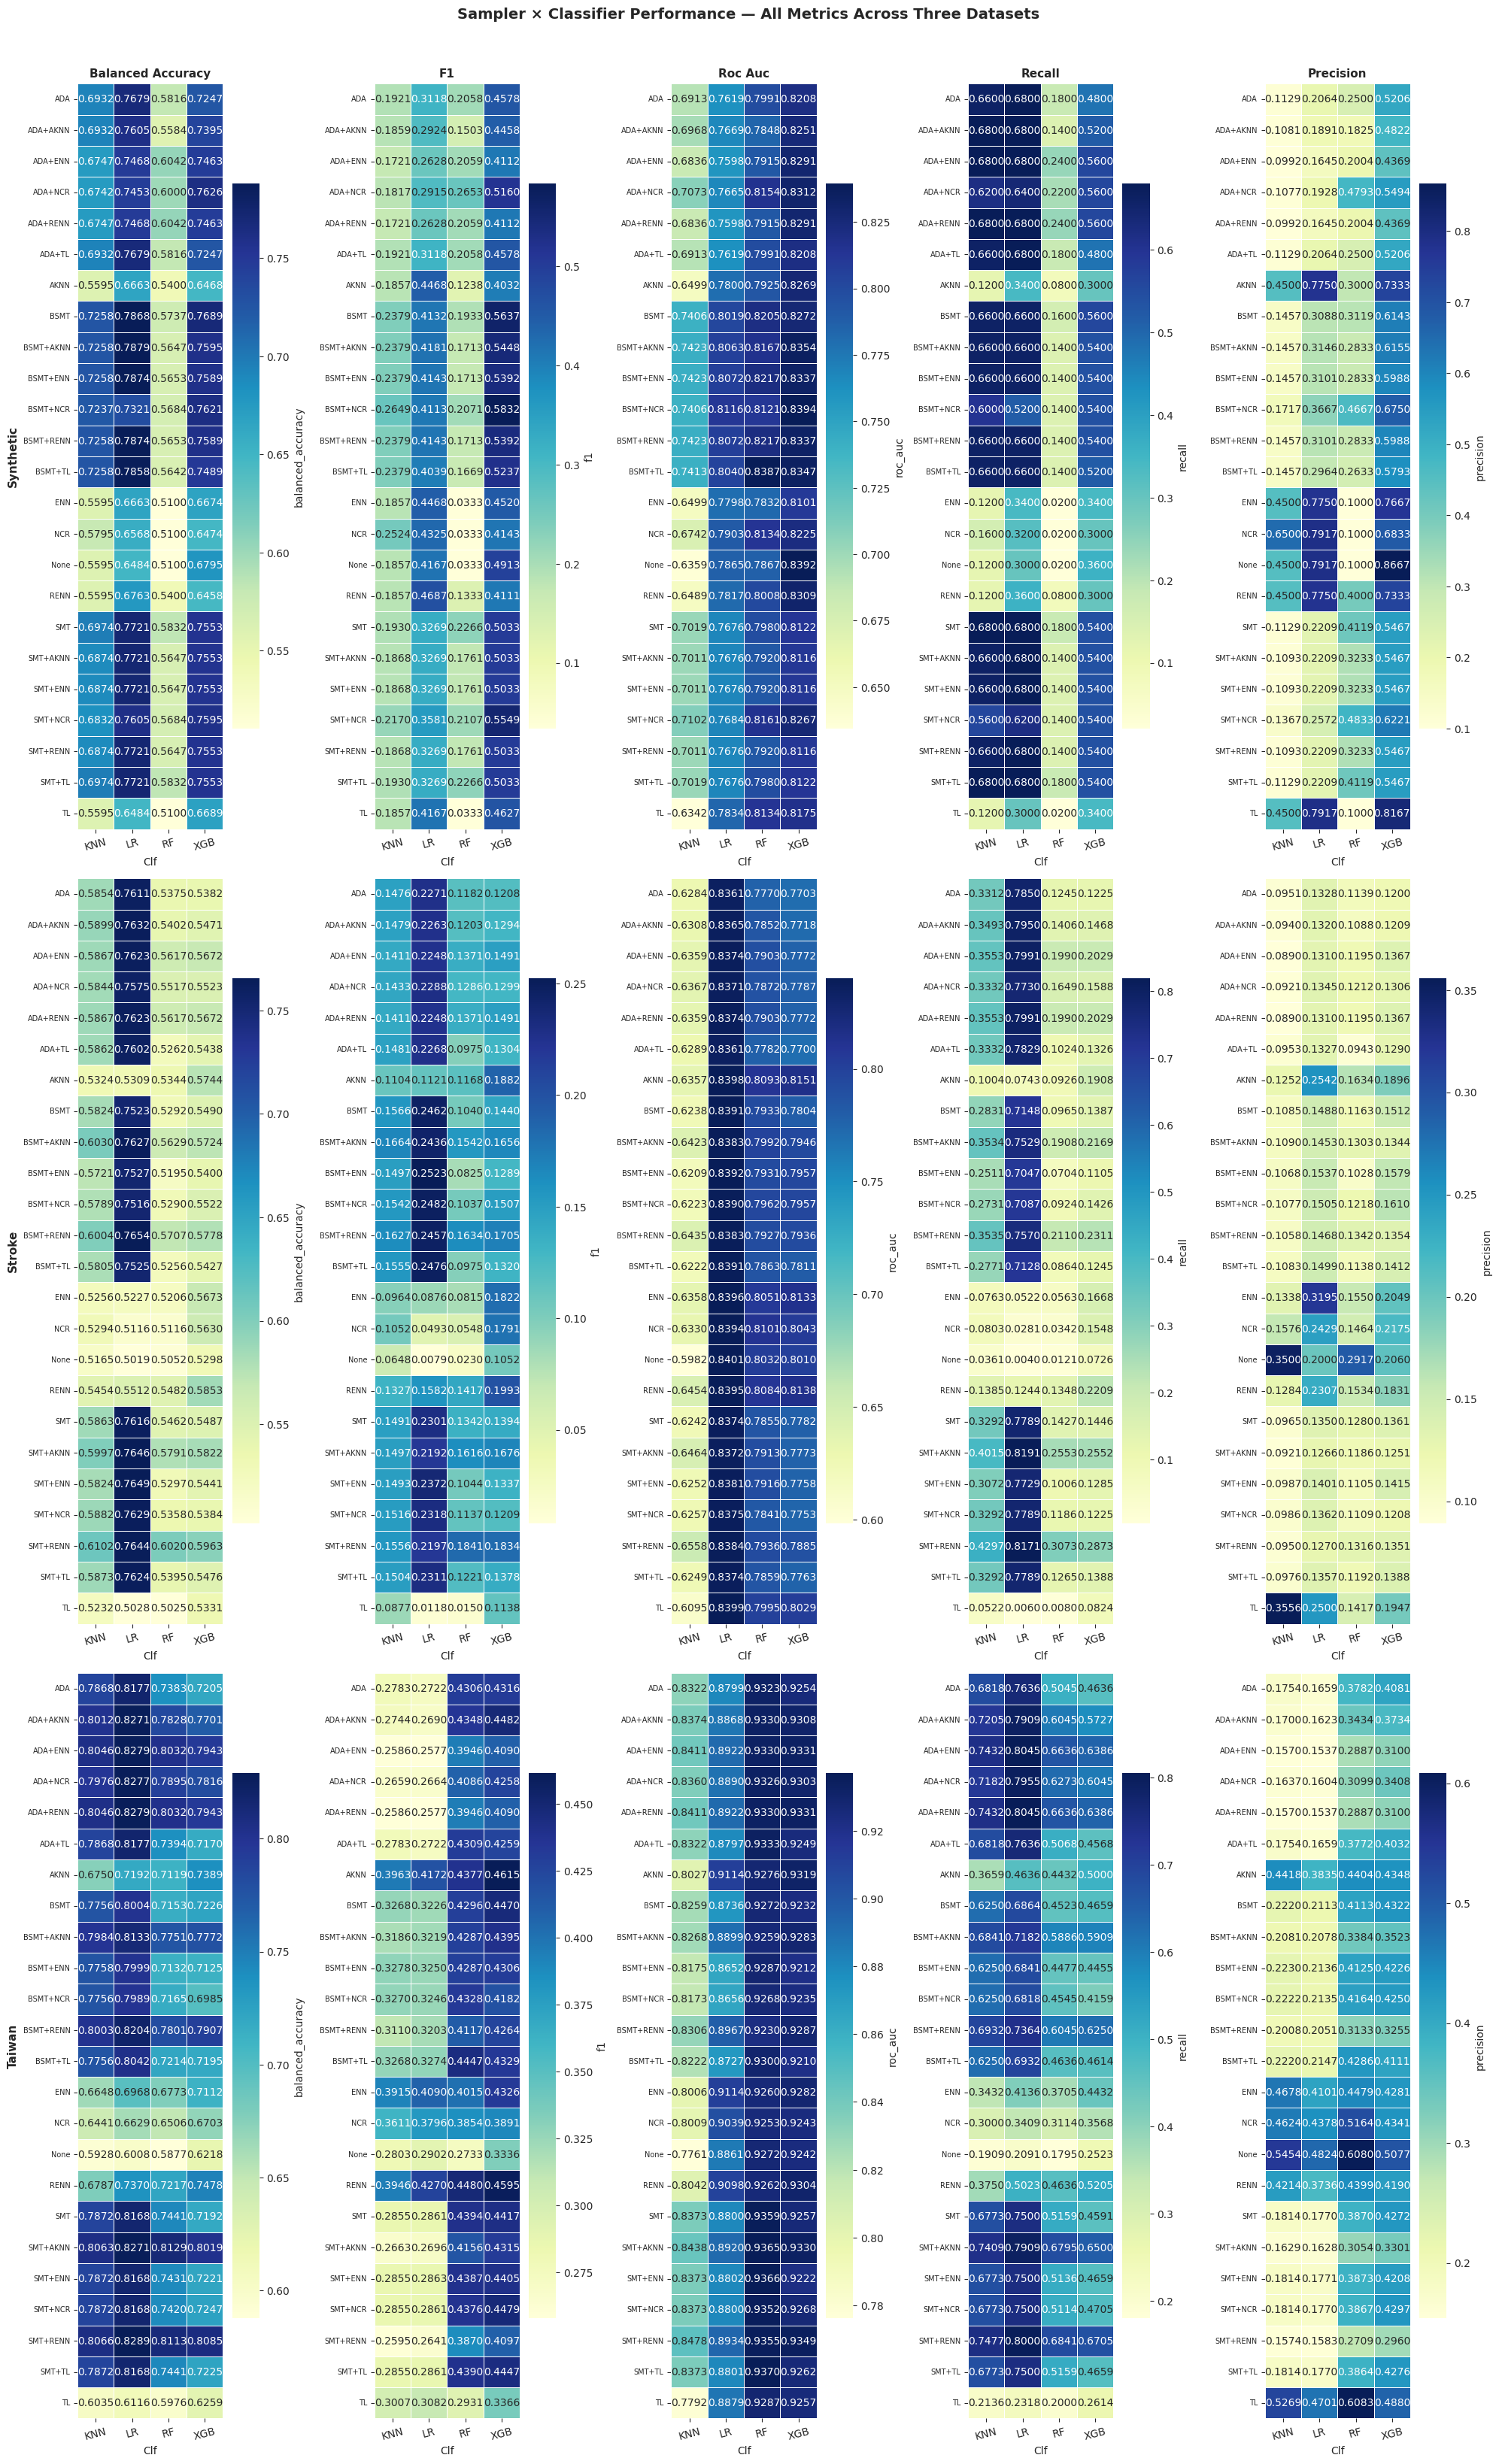

Fig A — cross-dataset all-metrics heatmap saved.


In [8]:
# ─────────────────────────────────────────
# 13. Cross-dataset comparison figures
# Fig A — All metrics across all three datasets
# Heatmap: Sampler × Classifier
# ─────────────────────────────────────────

# master sampler list across all datasets
all_samplers = sorted(
    set().union(
        *[
            df["Sampler"].unique()
            for df, _ in all_results.values()
        ]
    )
)

n_datasets = len(all_results)
n_metrics = len(METRICS)

fig_a, axes_a = plt.subplots(
    n_datasets,
    n_metrics,
    figsize=(4 * n_metrics, 0.45 * len(all_samplers) * n_datasets),
    sharey=False
)

fig_a.suptitle(
    "Sampler × Classifier Performance — All Metrics Across Three Datasets",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

# handle case when only 1 row
if n_datasets == 1:
    axes_a = np.array([axes_a])

for row_idx, (ds_name, (df, _)) in enumerate(all_results.items()):

    for col_idx, metric in enumerate(METRICS):

        ax = axes_a[row_idx, col_idx]

        # dataset-specific pivot
        pivot = df.pivot_table(
            index="Sampler",
            columns="Clf",
            values=metric,
            aggfunc="mean"
        )

        # include all 24 samplers
        pivot = pivot.reindex(all_samplers)

        sns.heatmap(
            pivot,
            annot=True,
            fmt=".4f",
            cmap="YlGnBu",
            linewidths=0.5,
            ax=ax,
            cbar_kws={"label": metric}
        )

        # titles
        if row_idx == 0:
            ax.set_title(
                metric.replace("_", " ").title(),
                fontsize=11,
                fontweight="bold"
            )

        # dataset labels
        if col_idx == 0:
            ax.set_ylabel(
                ds_name,
                fontsize=11,
                fontweight="bold"
            )
        else:
            ax.set_ylabel("")

        # force all 24 sampler labels
        ax.set_yticks(np.arange(len(all_samplers)) + 0.5)
        ax.set_yticklabels(
            all_samplers,
            fontsize=7
        )

        ax.tick_params(axis="x", rotation=15)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figA_cross_all_metrics_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Fig A — cross-dataset all-metrics heatmap saved.")

###Bar Chart

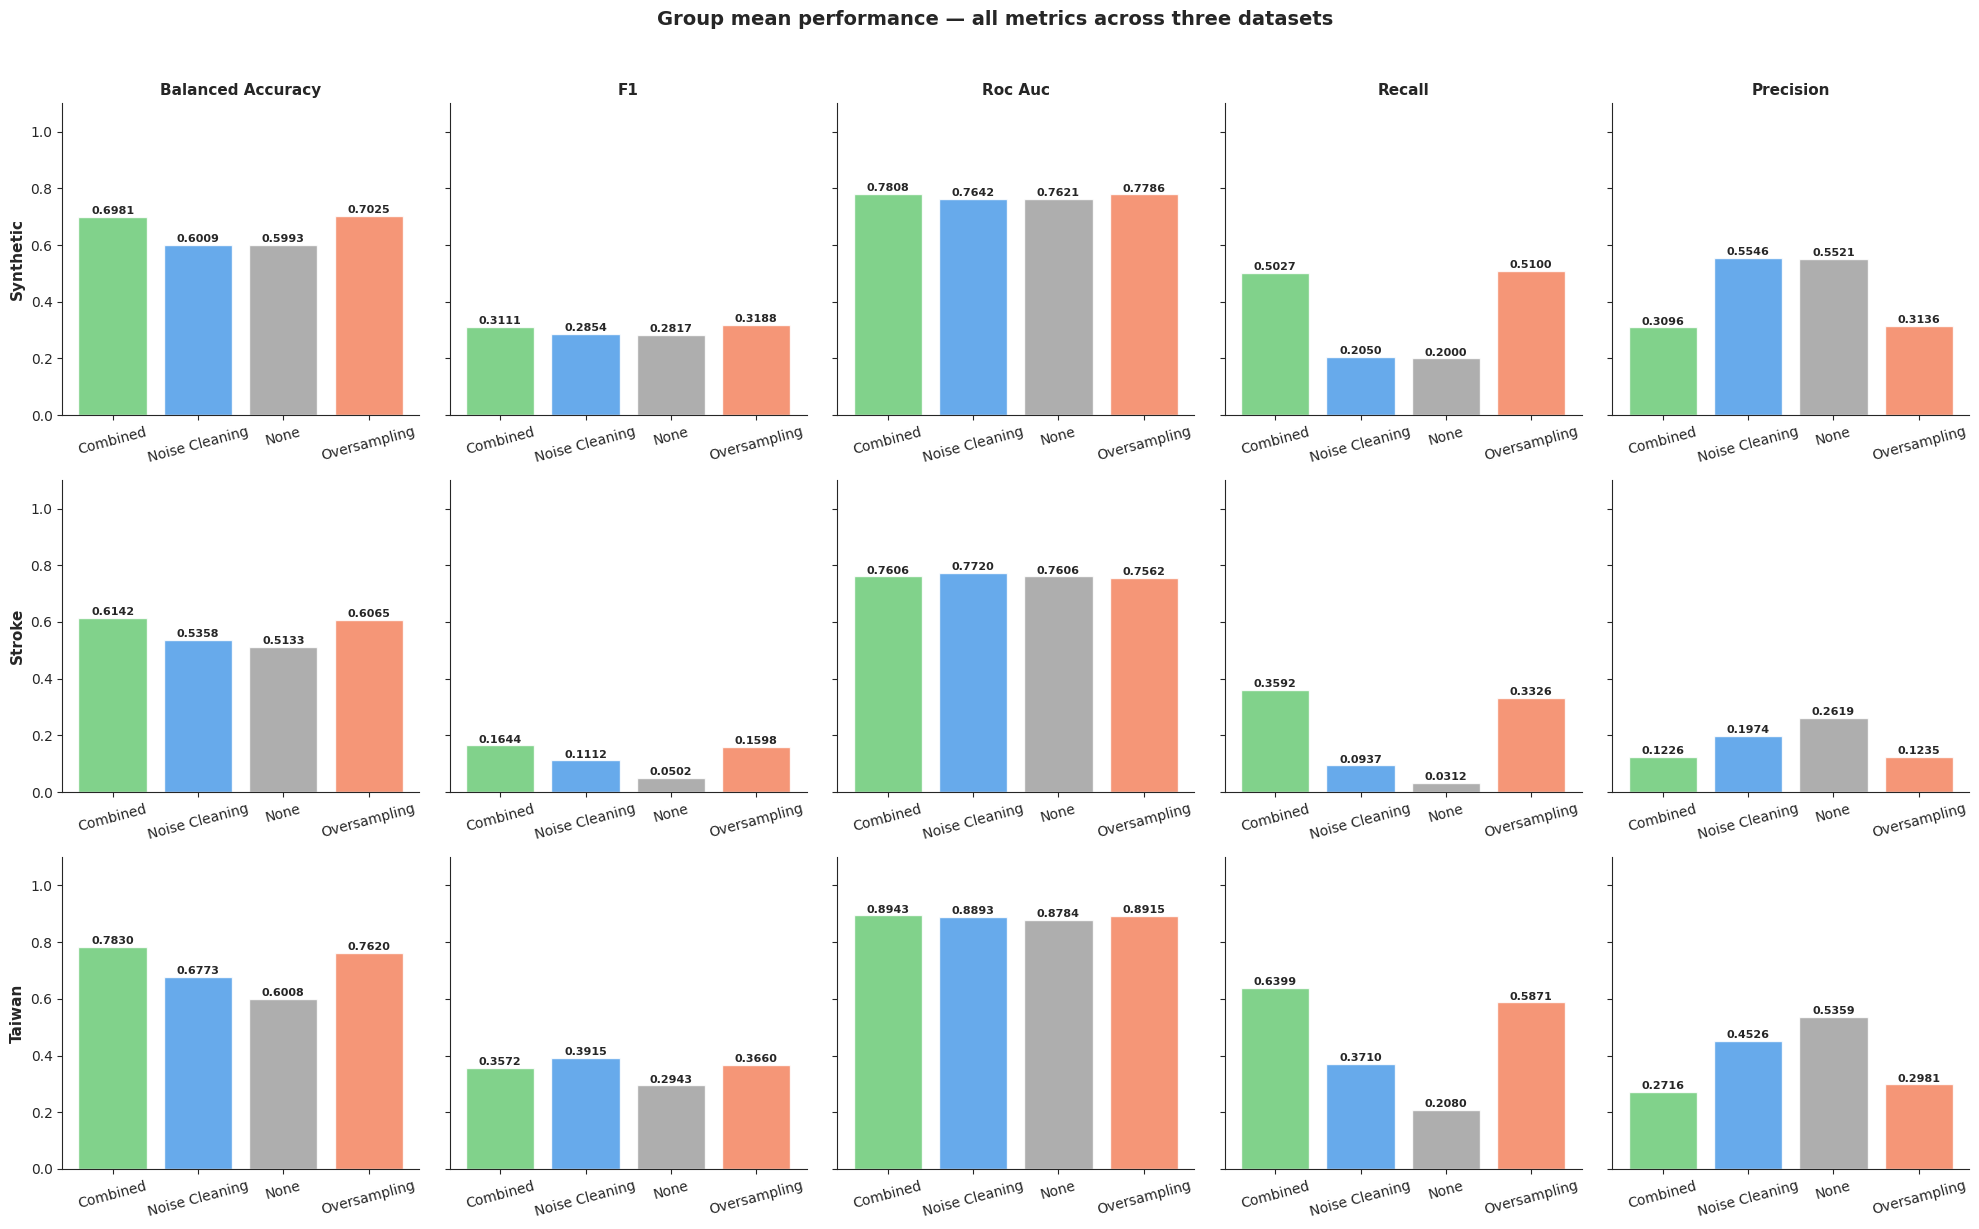

Fig A — cross-dataset all-metrics bar chart saved.


In [9]:
# ─────────────────────────────────────────
# 13. Cross-dataset comparison figures
# Fig A — All metrics across all three datasets
# ─────────────────────────────────────────

n_datasets = len(all_results)
n_metrics = len(METRICS)

fig_a, axes_a = plt.subplots(
    n_datasets,
    n_metrics,
    figsize=(4 * n_metrics, 4 * n_datasets),
    sharey=True
)

fig_a.suptitle(
    "Group mean performance — all metrics across three datasets",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

# handle case when only 1 row/col
if n_datasets == 1:
    axes_a = np.array([axes_a])

for row_idx, (ds_name, (df, _)) in enumerate(all_results.items()):

    for col_idx, metric in enumerate(METRICS):

        ax = axes_a[row_idx, col_idx]

        means = df.groupby("Group")[metric].mean()

        colors = [GROUP_COLORS[g] for g in means.index]

        bars = ax.bar(
            means.index,
            means.values,
            color=colors,
            alpha=0.85,
            edgecolor="white"
        )

        # add labels on top
        for bar, v in zip(bars, means.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{v:.4f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold"
            )

        # titles
        if row_idx == 0:
            ax.set_title(metric.replace("_", " ").title(),
                         fontsize=11,
                         fontweight="bold")

        if col_idx == 0:
            ax.set_ylabel(ds_name, fontsize=11, fontweight="bold")

        ax.set_ylim(0, 1.1)
        ax.tick_params(axis="x", rotation=15)

        sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figA_cross_all_metrics_bar.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Fig A — cross-dataset all-metrics bar chart saved.")

###Dot Plot

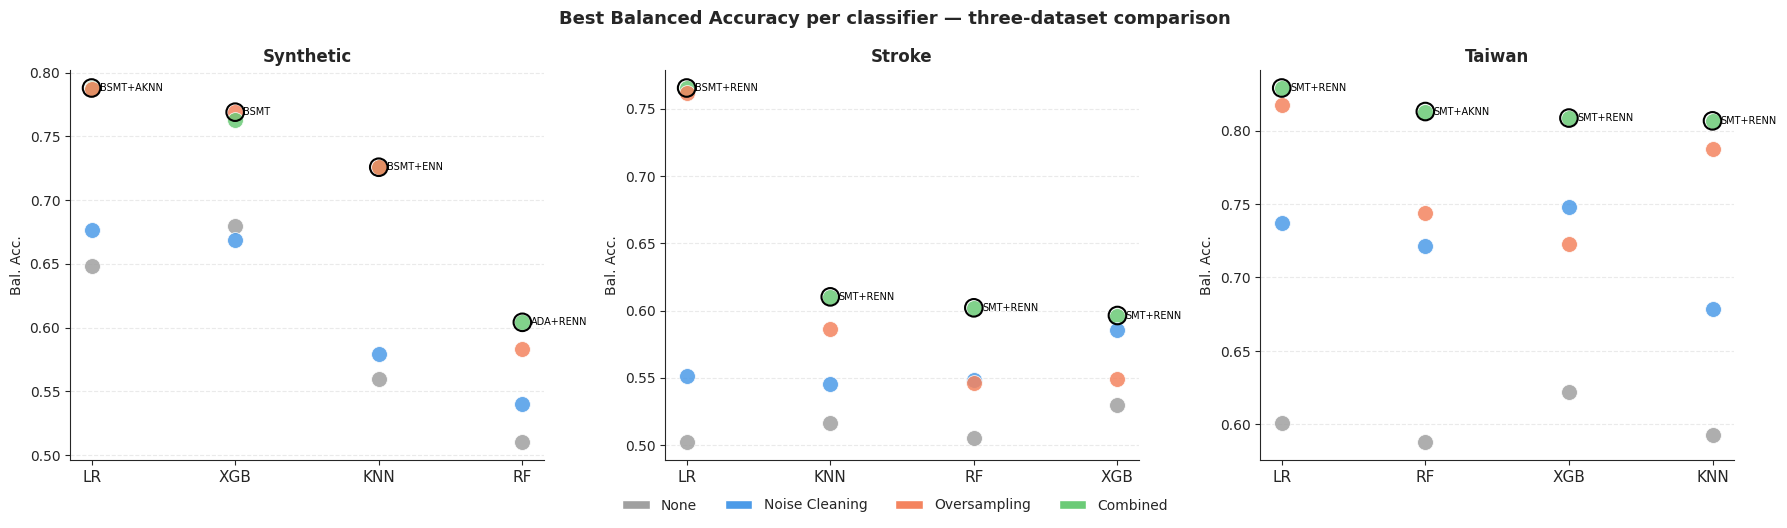

Fig C — cross-dataset classifier dot plot saved.


In [10]:
# Fig C — Best classifier dot plot across all three datasets
fig_c, axes_c = plt.subplots(1, 3, figsize=(18, 5))
fig_c.suptitle(
    "Best Balanced Accuracy per classifier — three-dataset comparison",
    fontsize=13, fontweight="bold",
)
for ax, (ds_name, (df, _)) in zip(axes_c, all_results.items()):
    df_best = (
        df.sort_values("balanced_accuracy", ascending=False)
          .groupby("Clf", sort=False).first().reset_index()
          [["Clf", "Group", "Sampler", "balanced_accuracy"]]
          .sort_values("balanced_accuracy", ascending=False)
    )
    df_grp_best = (
        df.sort_values("balanced_accuracy", ascending=False)
          .groupby(["Group", "Clf"], sort=False).first().reset_index()
          [["Group", "Clf", "Sampler", "balanced_accuracy"]]
    )
    clf_order = df_best["Clf"].tolist()
    for _, row in df_grp_best.iterrows():
        xi = clf_order.index(row["Clf"])
        ax.scatter(
            xi, row["balanced_accuracy"],
            color=GROUP_COLORS[row["Group"]], s=130,
            alpha=0.85, edgecolors="white",
            linewidths=0.6, zorder=3,
        )
    for _, row in df_best.iterrows():
        xi = clf_order.index(row["Clf"])
        ax.scatter(
            xi, row["balanced_accuracy"],
            facecolors="none", edgecolors="black",
            s=160, linewidths=1.5, zorder=4,
        )
        ax.annotate(
            row["Sampler"],
            (xi, row["balanced_accuracy"]),
            textcoords="offset points", xytext=(6, 0),
            fontsize=7, color="black", va="center",
        )
    ax.set_xticks(range(len(clf_order)))
    ax.set_xticklabels(clf_order, fontsize=11)
    ax.set_ylabel("Bal. Acc.")
    ax.set_title(ds_name, fontsize=12, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    sns.despine()
fig_c.legend(
    handles=[
        Patch(facecolor=c, label=g)
        for g, c in GROUP_COLORS.items()
    ],
    loc="lower center", ncol=4,
    bbox_to_anchor=(0.5, -0.05), frameon=False,
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figC_cross_clf_dot.png",
    dpi=150, bbox_inches="tight",
)
plt.show(); print("Fig C — cross-dataset classifier dot plot saved.")

#Statistical Testing

In [127]:
# ─────────────────────────────────────────
# 11. Statistical testing helpers
# ─────────────────────────────────────────

# Primary metric used for ALL statistical comparisons.
# All Friedman tests, Wilcoxon tests, and Cohen's d
# computations operate on this metric exclusively.
STAT_METRIC   = "balanced_accuracy"

# Significance threshold applied to all statistical tests.
# A result is considered significant when p < ALPHA.
ALPHA         = 0.05

# ── SD FLOOR EXPLANATION ──────────────────────────────────
# Cohen's d is computed as:
#
#     d = (mean_group - mean_none) / pooled_SD
#
# The pooled_SD sits in the denominator. When it is very
# small, even a tiny mean difference produces a huge d.
#
# This happens in this benchmark because the None baseline
# under severe imbalance is nearly perfectly stable across
# folds — the classifier always predicts the majority class,
# so its balanced accuracy barely changes from fold to fold.
# For example, LR on the Stroke dataset gives std_none ~ 0.004.
#
# A pooled SD of 0.004 would turn a reasonable 0.25 difference
# into d = 62.5, which is meaningless and misleading.
#
# The fix: we set a minimum allowed value for the pooled SD.
# If the computed pooled SD falls below this minimum, we
# replace it with the minimum before dividing.
# This is called "applying a floor" — the pooled SD cannot
# go lower than the floor value, just as a physical floor
# prevents something from falling below a certain level.
#
# We set the floor at 0.01, which equals one percentage point
# of balanced accuracy — the smallest difference a practitioner
# would consider practically meaningful in this benchmark.
#
# Effect of the floor:
#   raw_pool = 0.004  →  pooled = max(0.004, 0.01) = 0.01
#   raw_pool = 0.050  →  pooled = max(0.050, 0.01) = 0.050  (no change)
#   raw_pool = 0.120  →  pooled = max(0.120, 0.01) = 0.120  (no change)
#
# The floor only activates when the raw pooled SD is
# unrealistically small. For most classifiers and datasets
# it has no effect and raw_pool is used directly.
#
# Set MIN_POOLED_SD = 0.00 to disable the floor entirely
# and use the raw pooled SD in all cases.
# ─────────────────────────────────────────────────────────
MIN_POOLED_SD = 0.01

##Holm-Bonferrroni Function

In [128]:
def holm_correction(p_values: dict) -> dict:
    """
    Apply the Holm-Bonferroni stepwise correction to a
    dictionary of raw p-values to control the family-wise
    error rate across multiple simultaneous comparisons.

    The Holm procedure is more powerful than the standard
    Bonferroni correction while still controlling the
    family-wise error rate at the specified ALPHA level.

    How it works:
      1. Sort all raw p-values in ascending order.
      2. For the k-th smallest p-value, multiply it by
         (m - rank) where m is the total number of tests
         and rank starts at 0.
      3. Enforce monotonicity: each adjusted p-value is
         set to the maximum of itself and all previously
         adjusted values, so p-values never decrease as
         rank increases.
      4. Clip all adjusted values to a maximum of 1.0.

    Parameters
    ----------
    p_values : dict
        Mapping of comparison label to raw p-value.

    Returns
    -------
    dict
        Same keys as input, values replaced with
        Holm-Bonferroni adjusted p-values.
    """
    # Sort comparisons from smallest to largest p-value
    sorted_pairs = sorted(p_values.items(), key=lambda kv: kv[1])

    # Total number of comparisons being corrected
    m = len(sorted_pairs)

    corrected, running_max = {}, 0.0

    for rank, (label, p) in enumerate(sorted_pairs):
        # Multiply raw p by the number of remaining comparisons
        # (m - rank) to adjust for multiple testing
        adjusted = min(p * (m - rank), 1.0)

        # Enforce monotonicity: never let adjusted p decrease
        # as rank increases (ensures valid p-value ordering)
        running_max = max(running_max, adjusted)

        corrected[label] = running_max

    return corrected

##Friedman Omnibus Function

In [129]:
def friedman_and_posthoc(fold_df, groupby_col, value_col, label=""):
    """
    Apply the Friedman omnibus test to assess whether any
    significant ranking differences exist across groups,
    then apply post-hoc pairwise comparisons if significant.

    The Friedman test is a non-parametric alternative to
    repeated-measures ANOVA that makes no assumption of
    normality, making it appropriate for cross-validation
    performance metric distributions (Demsar, 2006).

    If p < ALPHA, post-hoc testing proceeds using either:
      - Nemenyi test (if scikit-posthocs is available):
        applied to all pairwise group combinations
      - Wilcoxon signed-rank + Holm correction (fallback):
        applied to all pairwise group combinations

    Parameters
    ----------
    fold_df     : DataFrame  fold-level results
    groupby_col : str        column to group by (e.g. "Sampler")
    value_col   : str        metric column (STAT_METRIC)
    label       : str        description printed in output

    Returns
    -------
    stat      : float  Friedman chi-squared statistic
    p         : float  p-value
    posthoc_df: DataFrame or None  pairwise p-values if significant
    """
    # Collect the score vectors for each unique group
    groups   = fold_df[groupby_col].unique().tolist()
    matrices = [
        fold_df[fold_df[groupby_col] == g][value_col].values
        for g in groups
    ]

    # Align all vectors to the shortest length to ensure
    # the Friedman test receives equal-length arrays
    min_len  = min(len(v) for v in matrices)
    matrices = [v[:min_len] for v in matrices]

    # Apply the Friedman test across all groups simultaneously
    stat, p  = friedmanchisquare(*matrices)
    sig_tag  = "SIGNIFICANT" if p < ALPHA else "not significant"

    print(f"\n{'─'*65}")
    print(f"{label}")
    print(f"  Friedman chi2 = {stat:.4f},  p = {p:.4e}  ({sig_tag})")

    posthoc_df = None

    if p < ALPHA:
        # Post-hoc pairwise testing is only conducted when
        # the Friedman omnibus test is significant (p < ALPHA)
        mat = np.column_stack(matrices)

        if HAS_POSTHOC:
            # Nemenyi post-hoc test: compares all pairs of
            # groups simultaneously using rank-based distances.
            # Preferred over Wilcoxon when all pairs are tested
            # together, as it accounts for the joint comparison.
            posthoc_df = posthoc_nemenyi_friedman(mat)
            posthoc_df.columns = posthoc_df.index = groups

            # Report only pairs that differ significantly
            sig_pairs = [
                f"    {g1:20s} vs {g2:20s}  "
                f"p={posthoc_df.loc[g1,g2]:.4f} *"
                for i, g1 in enumerate(groups)
                for j, g2 in enumerate(groups)
                if j > i and posthoc_df.loc[g1, g2] < ALPHA
            ]
            print(
                "  Nemenyi significant pairs:"
                if sig_pairs else
                "  No significant pairs after Nemenyi."
            )
            if sig_pairs:
                print("\n".join(sig_pairs))

        else:
            # Fallback: Wilcoxon signed-rank test for each pair
            # with Holm-Bonferroni correction applied across all
            # pairwise comparisons simultaneously.
            # Used when scikit-posthocs is not installed.
            raw_p = {}
            for (i, g1), (j, g2) in combinations(
                enumerate(groups), 2
            ):
                try:
                    # Wilcoxon signed-rank test: non-parametric
                    # test for paired samples. Appropriate here
                    # because each fold produces one score per
                    # group, making scores naturally paired.
                    _, pw = wilcoxon(matrices[i], matrices[j])
                except Exception:
                    # If Wilcoxon fails (e.g. all differences
                    # are zero), fall back to p = 1.0 to avoid
                    # false positives
                    pw = 1.0
                raw_p[f"{g1} vs {g2}"] = pw

            # Apply Holm-Bonferroni correction across all pairs
            adj_p = holm_correction(raw_p)

            print("  Wilcoxon + Holm:")
            for pair, ap in sorted(
                adj_p.items(), key=lambda kv: kv[1]
            ):
                mark = " *" if ap < ALPHA else ""
                print(f"    {pair:45s}  adj-p = {ap:.4f}{mark}")

    return stat, p, posthoc_df

##Cohen's D Function

In [126]:
def cohens_d(a, b, min_pooled_sd=MIN_POOLED_SD):
    """
    Compute Cohen's d effect size between an intervention
    group and the None baseline.

    ── WHY FOLD-MEAN SCORES ARE USED ────────────────────────
    Both a and b are fold-level mean scores (10 values each),
    not raw pooled scores across all samplers and folds.

    Using fold-means prevents two sources of artificial
    inflation in Cohen's d:

      1. Raw pooled scores inflate the sample size.
         The Combined group has 15 samplers x 10 folds = 150
         raw observations, while None has only 10. Dividing
         by the SD of 150 tightly clustered values produces
         a tiny denominator and an enormous Cohen's d.

      2. Sampler-level means cluster too tightly.
         All 15 hybrid strategies within Combined produce
         similar scores, so their standard deviation is
         very small, again inflating Cohen's d artificially.

    The solution is to average all samplers within the group
    for each fold first, giving 10 fold-mean values. This
    reflects genuine fold-to-fold variability rather than
    artificial tightness from sampler clustering.

    ── WHY THE SD FLOOR IS APPLIED ──────────────────────────
    Even with fold-mean scores, the None baseline can still
    have near-zero standard deviation under severe imbalance.
    When LR on Stroke always predicts the majority class,
    its balanced accuracy is nearly identical every fold,
    giving std_none ~ 0.004. Dividing by 0.004 still inflates
    Cohen's d even when the mean difference is reasonable.

    The floor (MIN_POOLED_SD = 0.01) prevents this by setting
    a minimum allowed value for the pooled SD. Think of it as
    saying: "I will never treat a variation smaller than one
    percentage point as meaningful when computing effect size."

    The floor only activates when raw_pool < MIN_POOLED_SD.
    For most classifiers and datasets it has no effect.
    ─────────────────────────────────────────────────────────

    Parameters
    ----------
    a             : array-like
        Fold-mean scores for the intervention group (10 values).
        Each value is the mean across all samplers in the
        group for one fold:
            df_fold[group_mask].groupby("fold")[metric].mean()
    b             : array-like
        Fold-level scores for the None baseline (10 values).
        Each value is the score for one fold:
            df_fold[none_mask][metric].values
    min_pooled_sd : float
        The SD floor — the minimum allowed pooled SD.
        Default is MIN_POOLED_SD = 0.01 (one percentage point).
        Set to 0.00 to disable and use raw pooled SD always.

    Returns
    -------
    d        : float  Cohen's d (using floored pooled SD)
    mean_a   : float  mean of intervention group
    std_a    : float  std of group a (ddof=1)
    mean_b   : float  mean of None baseline
    std_b    : float  std of group b (ddof=1)
    pooled   : float  pooled SD after floor is applied
    raw_pool : float  pooled SD before floor is applied
    delta    : float  mean_a minus mean_b (raw difference)

    Interpretation thresholds (Cohen, 1988):
        negligible : |d| < 0.20
        small      : 0.20 <= |d| < 0.50
        medium     : 0.50 <= |d| < 0.80
        large      : |d| >= 0.80
    """
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)

    # Guard: need at least 2 observations in each array
    # to compute a meaningful standard deviation.
    # Return zeros if either input is too short.
    if len(a) < 2 or len(b) < 2:
        return 0.0, np.mean(a), 0.0, np.mean(b), 0.0, 0.0, 0.0, 0.0

    mean_a = np.mean(a)
    mean_b = np.mean(b)

    # Standard deviation with Bessel's correction (ddof=1)
    # gives an unbiased estimate from a small sample of
    # 10 fold observations.
    std_a = np.std(a, ddof=1)
    std_b = np.std(b, ddof=1)

    # Pooled SD: average of the two group variances.
    # Represents the typical spread shared by both groups.
    # Formula assumes equal sample sizes (both have 10 values).
    raw_pool = np.sqrt((std_a**2 + std_b**2) / 2)

    # Apply the SD floor.
    # If raw_pool is unrealistically small (e.g. 0.004 for
    # a perfectly stable None baseline), replace it with
    # MIN_POOLED_SD so the division in Cohen's d stays
    # within a meaningful range.
    # If raw_pool is already larger than the floor, this
    # line has no effect and raw_pool is used directly.
    #
    # Example:
    #   raw_pool = 0.004  →  pooled = 0.01   (floor applied)
    #   raw_pool = 0.045  →  pooled = 0.045  (no change)
    pooled = max(raw_pool, min_pooled_sd)

    # Cohen's d: the mean difference divided by the pooled SD.
    # Answers the question: "How many standard deviations
    # apart are the two groups on average?"
    d = (mean_a - mean_b) / pooled

    # Raw mean difference: the absolute gap in balanced accuracy
    # between the intervention group and the None baseline.
    # Reported alongside d so readers can assess practical
    # magnitude independently of the SD scaling.
    delta = mean_a - mean_b

    return d, mean_a, std_a, mean_b, std_b, pooled, raw_pool, delta

##All Three Datasets


  STATISTICAL TESTING — Synthetic
  metric: balanced_accuracy  |  alpha = 0.05

─────────────────────────────────────────────────────────────────
[Synthetic] Friedman: ALL samplers per classifier
─────────────────────────────────────────────────────────────────

─────────────────────────────────────────────────────────────────
[Synthetic] Clf=LR | 24 samplers
  Friedman chi2 = 54.8291,  p = 2.0587e-04  (SIGNIFICANT)
  No significant pairs after Nemenyi.

─────────────────────────────────────────────────────────────────
[Synthetic] Clf=KNN | 24 samplers
  Friedman chi2 = 106.3601,  p = 1.1020e-12  (SIGNIFICANT)
  Nemenyi significant pairs:
    None                 vs BSMT                  p=0.0077 *
    None                 vs BSMT+ENN              p=0.0077 *
    None                 vs BSMT+RENN             p=0.0077 *
    None                 vs BSMT+AKNN             p=0.0077 *
    None                 vs BSMT+NCR              p=0.0030 *
    None                 vs BSMT+TL            

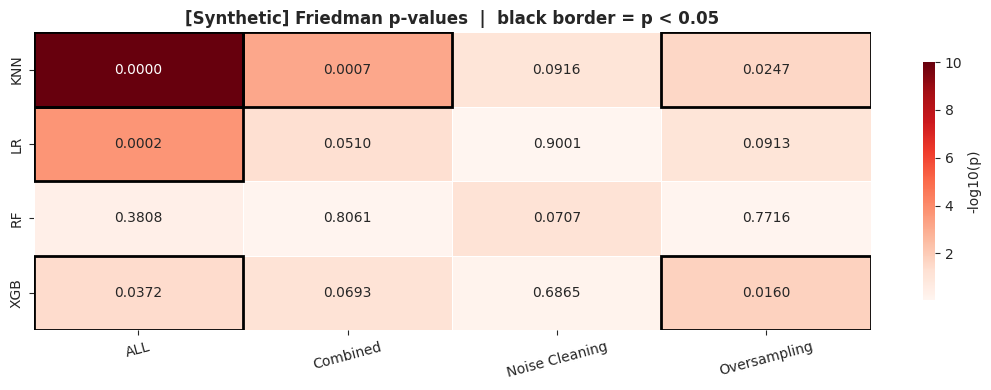

[Synthetic] Fig 9 saved.

[Synthetic] Cohen's d  (group minus None)
  Method : fold-mean scores (10 obs each)
  SD floor: MIN_POOLED_SD = 0.001
─────────────────────────────────────────────────────────────────
  Clf   Group             Mean_G     SD_G   Mean_N     SD_N    RawSD   PoolSD    Delta        d  Interp
─────────────────────────────────────────────────────────────────
  LR    Noise Cleaning    0.6628   0.0761   0.6484   0.0840   0.0801   0.0801  +0.0144   +0.180  [negligible]
  LR    Oversampling      0.7756   0.0855   0.6484   0.0840   0.0847   0.0847  +0.1272   +1.501  [large]
  LR    Combined          0.7665   0.0773   0.6484   0.0840   0.0807   0.0807  +0.1180   +1.462  [large]
  KNN   Noise Cleaning    0.5635   0.0662   0.5595   0.0696   0.0679   0.0679  +0.0040   +0.059  [negligible]
  KNN   Oversampling      0.7054   0.0979   0.5595   0.0696   0.0849   0.0849  +0.1460   +1.719  [large]
  KNN   Combined          0.6986   0.0947   0.5595   0.0696   0.0831   0.0831  +0.139

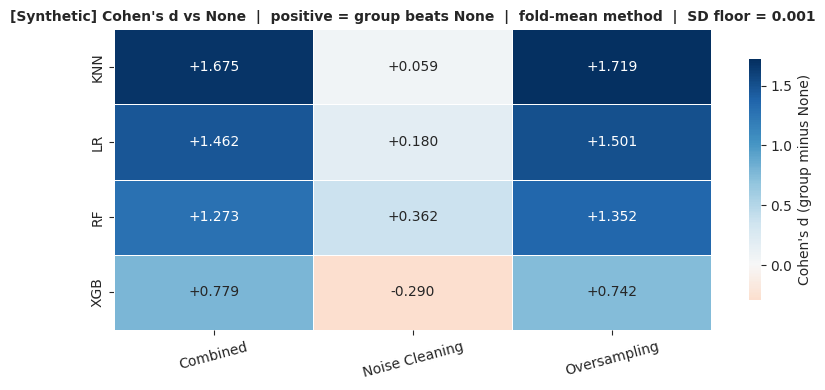

[Synthetic] Fig 10 saved.

[Synthetic] Effect size full diagnostic table:


,Clf,Group,n_obs,mean_group,std_group,mean_none,std_none,raw_pool_std,pooled_std,delta,cohens_d,interp
0,LR,Noise Cleaning,10,0.6628,0.0761,0.6484,0.0840,0.0801,0.0801,0.0144,0.1800,negligible
1,LR,Oversampling,10,0.7756,0.0855,0.6484,0.0840,0.0847,0.0847,0.1272,1.5009,large
2,LR,Combined,10,0.7665,0.0773,0.6484,0.0840,0.0807,0.0807,0.1180,1.4623,large
3,KNN,Noise Cleaning,10,0.5635,0.0662,0.5595,0.0696,0.0679,0.0679,0.0040,0.0589,negligible
4,KNN,Oversampling,10,0.7054,0.0979,0.5595,0.0696,0.0849,0.0849,0.1460,1.7186,large
5,KNN,Combined,10,0.6986,0.0947,0.5595,0.0696,0.0831,0.0831,0.1392,1.6745,large
6,RF,Noise Cleaning,10,0.5220,0.0346,0.5100,0.0316,0.0331,0.0331,0.0120,0.3622,small
7,RF,Oversampling,10,0.5795,0.0654,0.5100,0.0316,0.0514,0.0514,0.0695,1.3524,large
8,RF,Combined,10,0.5748,0.0647,0.5100,0.0316,0.0509,0.0509,0.0648,1.2733,large
9,XGB,Noise Cleaning,10,0.6553,0.0573,0.6795,0.1032,0.0835,0.0835,-0.0242,-0.2901,small


[Synthetic] Effect size CSV saved.

  STATISTICAL TESTING — Stroke
  metric: balanced_accuracy  |  alpha = 0.05

─────────────────────────────────────────────────────────────────
[Stroke] Friedman: ALL samplers per classifier
─────────────────────────────────────────────────────────────────

─────────────────────────────────────────────────────────────────
[Stroke] Clf=LR | 24 samplers
  Friedman chi2 = 149.3623,  p = 1.6762e-20  (SIGNIFICANT)
  Nemenyi significant pairs:
    None                 vs SMT                   p=0.0052 *
    None                 vs ADA                   p=0.0068 *
    None                 vs SMT+ENN               p=0.0000 *
    None                 vs SMT+RENN              p=0.0006 *
    None                 vs SMT+AKNN              p=0.0009 *
    None                 vs SMT+NCR               p=0.0001 *
    None                 vs SMT+TL                p=0.0004 *
    None                 vs BSMT+RENN             p=0.0001 *
    None                 vs BSMT+AK

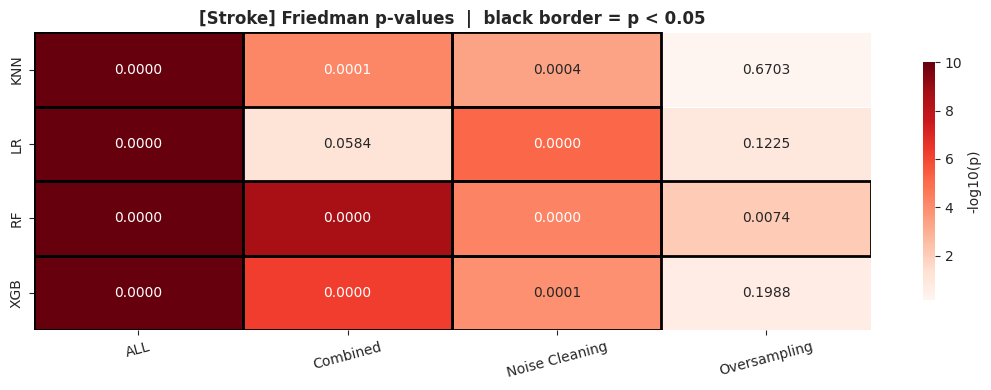

[Stroke] Fig 9 saved.

[Stroke] Cohen's d  (group minus None)
  Method : fold-mean scores (10 obs each)
  SD floor: MIN_POOLED_SD = 0.001
─────────────────────────────────────────────────────────────────
  Clf   Group             Mean_G     SD_G   Mean_N     SD_N    RawSD   PoolSD    Delta        d  Interp
─────────────────────────────────────────────────────────────────
  LR    Noise Cleaning    0.5238   0.0100   0.5019   0.0043   0.0077   0.0077  +0.0219   +2.840  [large]
  LR    Oversampling      0.7583   0.0288   0.5019   0.0043   0.0206   0.0206  +0.2564  +12.466  [large]
  LR    Combined          0.7606   0.0274   0.5019   0.0043   0.0196   0.0196  +0.2587  +13.182  [large]
  KNN   Noise Cleaning    0.5312   0.0137   0.5165   0.0131   0.0134   0.0134  +0.0147   +1.098  [large]
  KNN   Oversampling      0.5847   0.0383   0.5165   0.0131   0.0286   0.0286  +0.0682   +2.384  [large]
  KNN   Combined          0.5891   0.0360   0.5165   0.0131   0.0271   0.0271  +0.0726   +2.678  [lar

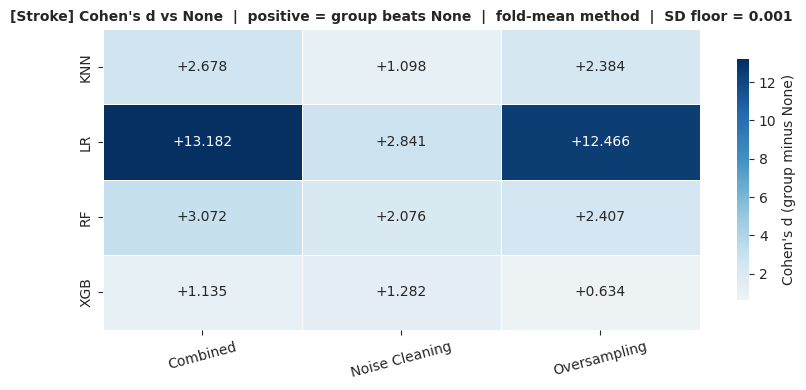

[Stroke] Fig 10 saved.

[Stroke] Effect size full diagnostic table:


,Clf,Group,n_obs,mean_group,std_group,mean_none,std_none,raw_pool_std,pooled_std,delta,cohens_d,interp
0,LR,Noise Cleaning,10,0.5238,0.0100,0.5019,0.0043,0.0077,0.0077,0.0219,2.8405,large
1,LR,Oversampling,10,0.7583,0.0288,0.5019,0.0043,0.0206,0.0206,0.2564,12.4663,large
2,LR,Combined,10,0.7606,0.0274,0.5019,0.0043,0.0196,0.0196,0.2587,13.1824,large
3,KNN,Noise Cleaning,10,0.5312,0.0137,0.5165,0.0131,0.0134,0.0134,0.0147,1.0982,large
4,KNN,Oversampling,10,0.5847,0.0383,0.5165,0.0131,0.0286,0.0286,0.0682,2.3838,large
5,KNN,Combined,10,0.5891,0.0360,0.5165,0.0131,0.0271,0.0271,0.0726,2.6779,large
6,RF,Noise Cleaning,10,0.5235,0.0101,0.5052,0.0074,0.0088,0.0088,0.0183,2.0760,large
7,RF,Oversampling,10,0.5376,0.0176,0.5052,0.0074,0.0135,0.0135,0.0325,2.4074,large
8,RF,Combined,10,0.5490,0.0188,0.5052,0.0074,0.0143,0.0143,0.0438,3.0725,large
9,XGB,Noise Cleaning,10,0.5646,0.0251,0.5298,0.0291,0.0272,0.0272,0.0348,1.2821,large


[Stroke] Effect size CSV saved.

  STATISTICAL TESTING — Taiwan
  metric: balanced_accuracy  |  alpha = 0.05

─────────────────────────────────────────────────────────────────
[Taiwan] Friedman: ALL samplers per classifier
─────────────────────────────────────────────────────────────────

─────────────────────────────────────────────────────────────────
[Taiwan] Clf=LR | 24 samplers
  Friedman chi2 = 167.7234,  p = 5.7344e-24  (SIGNIFICANT)
  Nemenyi significant pairs:
    None                 vs SMT                   p=0.0010 *
    None                 vs ADA                   p=0.0023 *
    None                 vs SMT+ENN               p=0.0006 *
    None                 vs SMT+RENN              p=0.0000 *
    None                 vs SMT+AKNN              p=0.0000 *
    None                 vs SMT+NCR               p=0.0010 *
    None                 vs SMT+TL                p=0.0010 *
    None                 vs BSMT+RENN             p=0.0030 *
    None                 vs BSMT+AKNN 

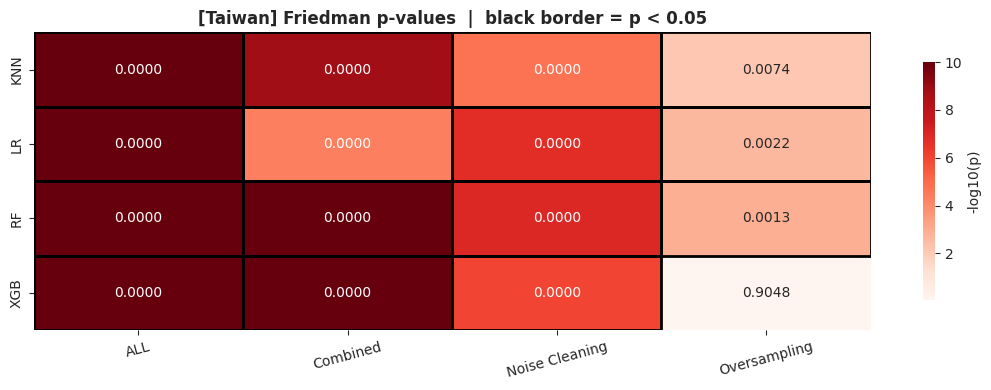

[Taiwan] Fig 9 saved.

[Taiwan] Cohen's d  (group minus None)
  Method : fold-mean scores (10 obs each)
  SD floor: MIN_POOLED_SD = 0.001
─────────────────────────────────────────────────────────────────
  Clf   Group             Mean_G     SD_G   Mean_N     SD_N    RawSD   PoolSD    Delta        d  Interp
─────────────────────────────────────────────────────────────────
  LR    Noise Cleaning    0.6855   0.0362   0.6008   0.0297   0.0331   0.0331  +0.0848   +2.561  [large]
  LR    Oversampling      0.8116   0.0350   0.6008   0.0297   0.0324   0.0324  +0.2109   +6.499  [large]
  LR    Combined          0.8181   0.0288   0.6008   0.0297   0.0292   0.0292  +0.2173   +7.430  [large]
  KNN   Noise Cleaning    0.6532   0.0308   0.5928   0.0245   0.0278   0.0278  +0.0605   +2.173  [large]
  KNN   Oversampling      0.7832   0.0254   0.5928   0.0245   0.0250   0.0250  +0.1905   +7.630  [large]
  KNN   Combined          0.7930   0.0254   0.5928   0.0245   0.0250   0.0250  +0.2002   +8.021  [lar

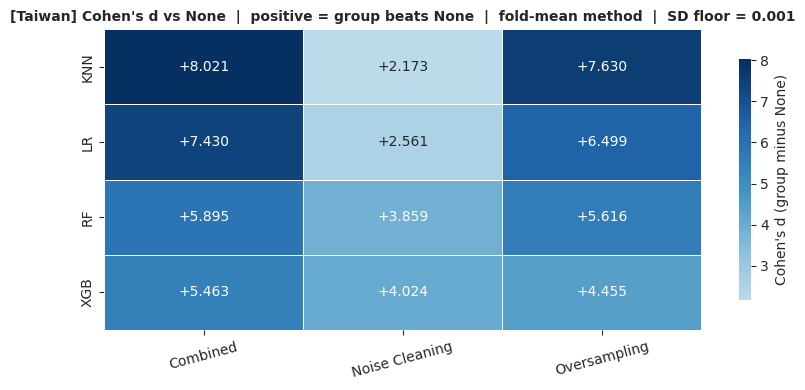

[Taiwan] Fig 10 saved.

[Taiwan] Effect size full diagnostic table:


,Clf,Group,n_obs,mean_group,std_group,mean_none,std_none,raw_pool_std,pooled_std,delta,cohens_d,interp
0,LR,Noise Cleaning,10,0.6855,0.0362,0.6008,0.0297,0.0331,0.0331,0.0848,2.5613,large
1,LR,Oversampling,10,0.8116,0.0350,0.6008,0.0297,0.0324,0.0324,0.2109,6.4988,large
2,LR,Combined,10,0.8181,0.0288,0.6008,0.0297,0.0292,0.0292,0.2173,7.4304,large
3,KNN,Noise Cleaning,10,0.6532,0.0308,0.5928,0.0245,0.0278,0.0278,0.0605,2.1733,large
4,KNN,Oversampling,10,0.7832,0.0254,0.5928,0.0245,0.0250,0.0250,0.1905,7.6297,large
5,KNN,Combined,10,0.7930,0.0254,0.5928,0.0245,0.0250,0.0250,0.2002,8.0211,large
6,RF,Noise Cleaning,10,0.6718,0.0203,0.5877,0.0231,0.0218,0.0218,0.0841,3.8591,large
7,RF,Oversampling,10,0.7326,0.0282,0.5877,0.0231,0.0258,0.0258,0.1448,5.6163,large
8,RF,Combined,10,0.7652,0.0357,0.5877,0.0231,0.0301,0.0301,0.1774,5.8947,large
9,XGB,Noise Cleaning,10,0.6988,0.0164,0.6218,0.0215,0.0191,0.0191,0.0770,4.0237,large


[Taiwan] Effect size CSV saved.

  POOLED EFFECT SIZE SUMMARY
  Averaged across Synthetic + Stroke + Taiwan
  Method: fold-mean scores (10 obs each)
  SD floor: MIN_POOLED_SD = 0.001

Pooled mean effect sizes across all three datasets:


mean_group  std_group  mean_none  std_none  raw_pool_std  \
Clf Group                                                                      
KNN Combined            0.6936     0.0520     0.5563    0.0357        0.0451   
    Noise Cleaning      0.5826     0.0369     0.5563    0.0357        0.0364   
    Oversampling        0.6911     0.0539     0.5563    0.0357        0.0462   
LR  Combined            0.7817     0.0445     0.5837    0.0393        0.0432   
    Noise Cleaning      0.6240     0.0408     0.5837    0.0393        0.0403   
    Oversampling        0.7818     0.0498     0.5837    0.0393        0.0459   
RF  Combined            0.6297     0.0397     0.5343    0.0207        0.0318   
    Noise Cleaning      0.5724     0.0217     0.5343    0.0207        0.0212   
    Oversampling        0.6166     0.0371     0.5343    0.0207        0.0302   
XGB Combined            0.6888     0.0435     0.6104    0.0513        0.0477   
    Noise Cleaning      0.6396     0.0329     0.6104    0.0513        0.0433   
    Oversampling        0.6719     0.0423     0.6104    0.0513        0.0471   

                    pooled_std   delta  cohens_d  
Clf Group                                         
KNN Combined            0.0451  0.1373    4.1245  
    Noise Cleaning      0.0364  0.0264    1.1101  
    Oversampling        0.0462  0.1349    3.9107  
LR  Combined            0.0432  0.1980    7.3584  
    Noise Cleaning      0.0403  0.0404    1.8606  
    Oversampling        0.0459  0.1982    6.8220  
RF  Combined            0.0318  0.0953    3.4135  
    Noise Cleaning      0.0212  0.0381    2.0991  
    Oversampling        0.0302  0.0823    3.1254  
XGB Combined            0.0477  0.0784    2.4589  
    Noise Cleaning      0.0433  0.0292    1.6719  
    Oversampling        0.0471  0.0616    1.9434

Pooled effect size CSV saved.


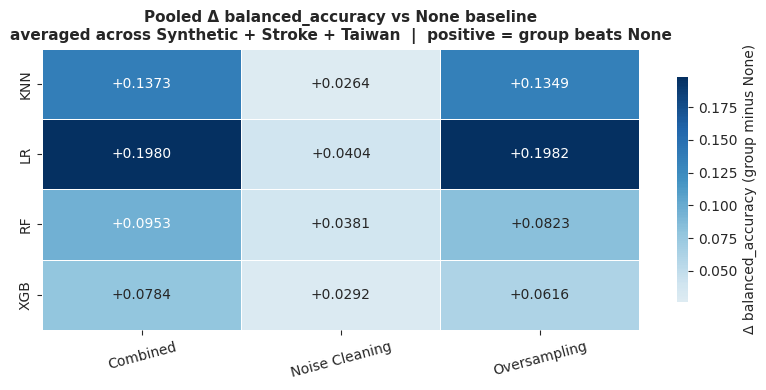

Delta heatmap saved.


In [121]:
# ─────────────────────────────────────────
# 12. Statistical testing — all three datasets
# ─────────────────────────────────────────
all_stat_records   = {}
all_effect_records = {}

for ds_name, (df, df_fold) in all_results.items():
    print(f"\n{'='*65}")
    print(f"  STATISTICAL TESTING — {ds_name}")
    print(f"  metric: {STAT_METRIC}  |  alpha = {ALPHA}")
    print(f"{'='*65}")

    stat_records = []

    # ── 12a — Friedman across all samplers per classifier ──
    print(f"\n{'─'*65}")
    print(f"[{ds_name}] Friedman: ALL samplers per classifier")
    print(f"{'─'*65}")
    for clf_name in classifiers:
        sub  = df_fold[df_fold["Clf"] == clf_name]
        stat, p, _ = friedman_and_posthoc(
            sub, "Sampler", STAT_METRIC,
            label=f"[{ds_name}] Clf={clf_name} | "
                  f"{sub['Sampler'].nunique()} samplers",
        )
        stat_records.append({
            "Clf":           clf_name,
            "Group":         "ALL",
            "friedman_stat": stat,
            "friedman_p":    p,
        })

    # ── 12b — Friedman within each group x classifier ──
    print(f"\n{'─'*65}")
    print(f"[{ds_name}] Friedman: within each GROUP x classifier")
    print(f"{'─'*65}")
    for group_name in GROUPS:
        for clf_name in classifiers:
            sub = df_fold[
                (df_fold["Group"] == group_name) &
                (df_fold["Clf"]   == clf_name)
            ]
            if sub["Sampler"].nunique() < 2:
                continue
            stat, p, _ = friedman_and_posthoc(
                sub, "Sampler", STAT_METRIC,
                label=f"[{ds_name}] Group={group_name} | "
                      f"Clf={clf_name}",
            )
            stat_records.append({
                "Clf":           clf_name,
                "Group":         group_name,
                "friedman_stat": stat,
                "friedman_p":    p,
            })

    # ── 12c — 4 groups vs each other ──
    print(f"\n{'='*65}")
    print(f"[{ds_name}] Friedman: 4 GROUPS vs each other")
    print(f"{'='*65}")
    friedman_and_posthoc(
        df_fold.groupby(
            ["Group", "fold"]
        )[STAT_METRIC].mean().reset_index(),
        "Group", STAT_METRIC,
        label=f"[{ds_name}] All classifiers pooled",
    )

    # ── 12d — 4 classifiers vs each other ──
    print(f"\n{'='*65}")
    print(f"[{ds_name}] Friedman: 4 CLASSIFIERS vs each other")
    print(f"{'='*65}")
    friedman_and_posthoc(
        df_fold.groupby(
            ["Clf", "fold"]
        )[STAT_METRIC].mean().reset_index(),
        "Clf", STAT_METRIC,
        label=f"[{ds_name}] All samplers pooled",
    )

    # ── 12e — None vs each group per classifier ──
    print(f"\n{'='*65}")
    print(f"[{ds_name}] None vs each group — Wilcoxon + Holm")
    print(f"{'='*65}")
    for clf_name in classifiers:
        none_vals = df_fold[
            (df_fold["Clf"]     == clf_name) &
            (df_fold["Sampler"] == "None")
        ][STAT_METRIC].values

        raw_p = {}
        for group_name in [
            "Noise Cleaning", "Oversampling", "Combined"
        ]:
            g_vals = (
                df_fold[
                    (df_fold["Clf"]   == clf_name) &
                    (df_fold["Group"] == group_name)
                ]
                .groupby("fold")[STAT_METRIC]
                .mean().values
            )
            min_len = min(len(none_vals), len(g_vals))
            try:
                _, pw = wilcoxon(
                    none_vals[:min_len],
                    g_vals[:min_len]
                )
            except Exception:
                pw = 1.0
            raw_p[group_name] = pw

        adj_p = holm_correction(raw_p)
        print(f"\n  {clf_name}:")
        for grp, ap in adj_p.items():
            g_mean = df[
                (df["Clf"]   == clf_name) &
                (df["Group"] == grp)
            ][STAT_METRIC].mean()
            none_mean = df[
                (df["Clf"]     == clf_name) &
                (df["Sampler"] == "None")
            ][STAT_METRIC].mean()
            delta = g_mean - none_mean
            mark  = " *" if ap < ALPHA else ""
            print(
                f"    None vs {grp:15s}  "
                f"adj-p = {ap:.4f}{mark}  "
                f"(delta = {delta:+.3f})"
            )

    # ── 12f — Friedman p-value heatmap ──
    df_stat    = pd.DataFrame(stat_records)
    pivot_stat = df_stat.pivot(
        index="Clf", columns="Group", values="friedman_p"
    )
    log_p = -np.log10(pivot_stat.clip(lower=1e-10))
    tag   = ds_name.lower()

    fig9, ax9 = plt.subplots(figsize=(11, 4))
    sns.heatmap(
        log_p,
        annot=pivot_stat.round(4),
        fmt=".4f",
        cmap="Reds",
        ax=ax9,
        linewidths=0.5,
        cbar_kws={"label": "-log10(p)", "shrink": 0.8},
    )
    for i, clf in enumerate(pivot_stat.index):
        for j, grp in enumerate(pivot_stat.columns):
            pv = pivot_stat.loc[clf, grp]
            if not np.isnan(pv) and pv < ALPHA:
                ax9.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=False, edgecolor="black", lw=2,
                ))
    ax9.set_title(
        f"[{ds_name}] Friedman p-values  |  "
        f"black border = p < {ALPHA}",
        fontsize=12, fontweight="bold",
    )
    ax9.set_xlabel("")
    ax9.set_ylabel("")
    ax9.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"fig9_{tag}_friedman_heatmap.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print(f"[{ds_name}] Fig 9 saved.")

    # ── 12g — Cohen's d ──
    # Both group and None are averaged to fold-level first
    # giving 10 comparable observations each, preventing
    # inflation from tight sampler or fold clustering
    print(f"\n{'='*65}")
    print(f"[{ds_name}] Cohen's d  (group minus None)")
    print(f"  Method : fold-mean scores (10 obs each)")
    print(f"  SD floor: MIN_POOLED_SD = {MIN_POOLED_SD}")
    print(f"{'─'*65}")
    print(
        f"  {'Clf':4s}  {'Group':15s}  "
        f"{'Mean_G':>7s}  {'SD_G':>7s}  "
        f"{'Mean_N':>7s}  {'SD_N':>7s}  "
        f"{'RawSD':>7s}  {'PoolSD':>7s}  "
        f"{'Delta':>7s}  {'d':>7s}  Interp"
    )
    print(f"{'─'*65}")

    effect_records = []

    for clf_name in classifiers:
        # None baseline: fold-level scores (10 values)
        none_fold_vals = df_fold[
            (df_fold["Clf"]     == clf_name) &
            (df_fold["Sampler"] == "None")
        ][STAT_METRIC].values

        for group_name in [
            "Noise Cleaning", "Oversampling", "Combined"
        ]:
            # Group: mean across all samplers per fold
            # gives 10 comparable fold-mean values
            group_fold_means = (
                df_fold[
                    (df_fold["Clf"]   == clf_name) &
                    (df_fold["Group"] == group_name)
                ]
                .groupby("fold")[STAT_METRIC]
                .mean()
                .values
            )

            (d, mean_g, std_g,
             mean_n, std_n,
             pool_sd, raw_pool,
             delta) = cohens_d(
                group_fold_means,
                none_fold_vals,
                min_pooled_sd=MIN_POOLED_SD,
            )

            interp = (
                "negligible" if abs(d) < 0.2 else
                "small"      if abs(d) < 0.5 else
                "medium"     if abs(d) < 0.8 else "large"
            )

            print(
                f"  {clf_name:4s}  {group_name:15s}  "
                f"{mean_g:7.4f}  {std_g:7.4f}  "
                f"{mean_n:7.4f}  {std_n:7.4f}  "
                f"{raw_pool:7.4f}  {pool_sd:7.4f}  "
                f"{delta:+7.4f}  {d:+7.3f}  [{interp}]"
            )

            effect_records.append({
                "Dataset":      ds_name,
                "Clf":          clf_name,
                "Group":        group_name,
                "n_obs":        len(group_fold_means),
                "mean_group":   round(mean_g,   4),
                "std_group":    round(std_g,    4),
                "mean_none":    round(mean_n,   4),
                "std_none":     round(std_n,    4),
                "raw_pool_std": round(raw_pool, 4),
                "pooled_std":   round(pool_sd,  4),
                "delta":        round(delta,    4),
                "cohens_d":     round(d,        4),
                "interp":       interp,
            })

    # Cohen's d heatmap
    effect_df = pd.DataFrame(effect_records)
    pivot_eff = effect_df.pivot(
        index="Clf", columns="Group", values="cohens_d"
    )
    fig10, ax10 = plt.subplots(figsize=(8, 4))
    sns.heatmap(
        pivot_eff,
        annot=True,
        fmt="+.3f",
        cmap="RdBu",
        center=0,
        ax=ax10,
        linewidths=0.5,
        cbar_kws={
            "label":  "Cohen's d (group minus None)",
            "shrink": 0.8,
        },
    )
    ax10.set_title(
        f"[{ds_name}] Cohen's d vs None  |  "
        f"positive = group beats None  |  "
        f"fold-mean method  |  SD floor = {MIN_POOLED_SD}",
        fontsize=10, fontweight="bold",
    )
    ax10.set_xlabel("")
    ax10.set_ylabel("")
    ax10.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"fig10_{tag}_cohens_d.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()
    print(f"[{ds_name}] Fig 10 saved.")

    # ── Full diagnostic summary table ──
    print(f"\n[{ds_name}] Effect size full diagnostic table:")
    display(effect_df[[
        "Clf",          "Group",
        "n_obs",
        "mean_group",   "std_group",
        "mean_none",    "std_none",
        "raw_pool_std", "pooled_std",
        "delta",        "cohens_d",   "interp",
    ]].round(4))

    # Save diagnostic CSV
    effect_df.to_csv(
        OUTPUT_DIR / f"effect_size_{tag}.csv",
        index=False,
    )
    print(f"[{ds_name}] Effect size CSV saved.")

    all_stat_records[ds_name]   = stat_records
    all_effect_records[ds_name] = effect_records


# ── Pooled effect size summary across all three datasets ──
print(f"\n{'='*65}")
print("  POOLED EFFECT SIZE SUMMARY")
print(f"  Averaged across Synthetic + Stroke + Taiwan")
print(f"  Method: fold-mean scores (10 obs each)")
print(f"  SD floor: MIN_POOLED_SD = {MIN_POOLED_SD}")
print(f"{'='*65}")

all_effects_df = pd.concat(
    [pd.DataFrame(v) for v in all_effect_records.values()],
    ignore_index=True,
)

pooled_summary = (
    all_effects_df
    .groupby(["Clf", "Group"])[
        ["mean_group",   "std_group",
         "mean_none",    "std_none",
         "raw_pool_std", "pooled_std",
         "delta",        "cohens_d"]
    ]
    .mean()
    .round(4)
)

print("\nPooled mean effect sizes across all three datasets:")
display(pooled_summary)

pooled_summary.to_csv(
    OUTPUT_DIR / "effect_size_pooled.csv"
)
print("Pooled effect size CSV saved.")

# ── Delta heatmap ──
pivot_delta = pooled_summary["delta"].unstack("Group")

fig_delta, ax_delta = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot_delta,
    annot=True,
    fmt="+.4f",
    cmap="RdBu",
    center=0,
    ax=ax_delta,
    linewidths=0.5,
    cbar_kws={
        "label":  f"Δ {STAT_METRIC} (group minus None)",
        "shrink": 0.8,
    },
)
ax_delta.set_title(
    f"Pooled Δ {STAT_METRIC} vs None baseline\n"
    "averaged across Synthetic + Stroke + Taiwan  |  "
    "positive = group beats None",
    fontsize=11, fontweight="bold",
)
ax_delta.set_xlabel("")
ax_delta.set_ylabel("")
ax_delta.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "fig_delta_heatmap.png",
    dpi=150, bbox_inches="tight",
)
plt.show()
print("Delta heatmap saved.")

##Figures

###Friedman p-value

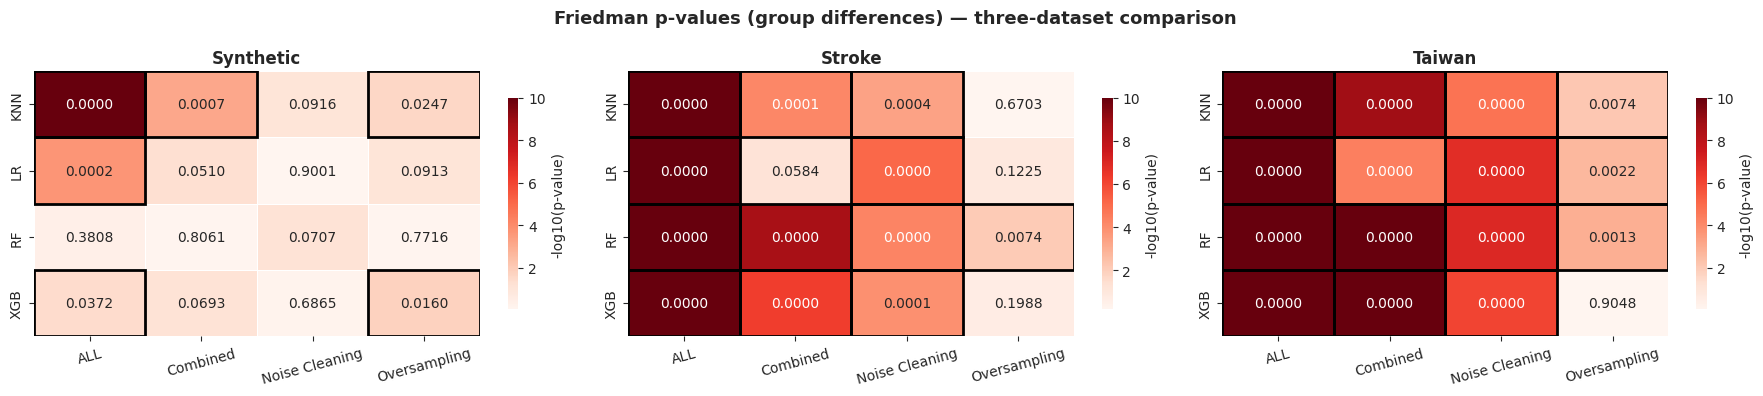

Fig B — cross-dataset Friedman p-values saved.


In [122]:
# Fig B — Friedman p-value side-by-side across all three datasets
all_stat_df_list = []
for ds_name, recs in all_stat_records.items():
    df_temp = pd.DataFrame(recs)
    df_temp["Dataset"] = ds_name
    all_stat_df_list.append(df_temp)
all_stat_df = pd.concat(all_stat_df_list, ignore_index=True)

fig_b, axes_b = plt.subplots(1, 3, figsize=(18, 4))

fig_b.suptitle(
    "Friedman p-values (group differences) — three-dataset comparison",
    fontsize=13,
    fontweight="bold",
)

for ax, ds_name in zip(
    axes_b, ["Synthetic", "Stroke", "Taiwan"]
):

    subset = all_stat_df[
        all_stat_df["Dataset"] == ds_name
    ]

    # pivot: classifier × group → p-value
    pivot = subset.pivot(
        index="Clf",
        columns="Group",
        values="friedman_p"
    )

    # log transform for better visualization
    log_p = -np.log10(pivot.clip(lower=1e-10))

    sns.heatmap(
        log_p,
        annot=pivot.round(4),
        fmt=".4f",
        cmap="Reds",
        ax=ax,
        linewidths=0.5,
        cbar_kws={
            "label": "-log10(p-value)",
            "shrink": 0.8
        },
    )

    # highlight significant cells
    for i, clf in enumerate(pivot.index):
        for j, grp in enumerate(pivot.columns):
            pv = pivot.loc[clf, grp]
            if not np.isnan(pv) and pv < ALPHA:
                ax.add_patch(plt.Rectangle(
                    (j, i), 1, 1,
                    fill=False,
                    edgecolor="black",
                    lw=2
                ))

    ax.set_title(ds_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figB_cross_friedman_pvalues.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Fig B — cross-dataset Friedman p-values saved.")

###Friedman χ²

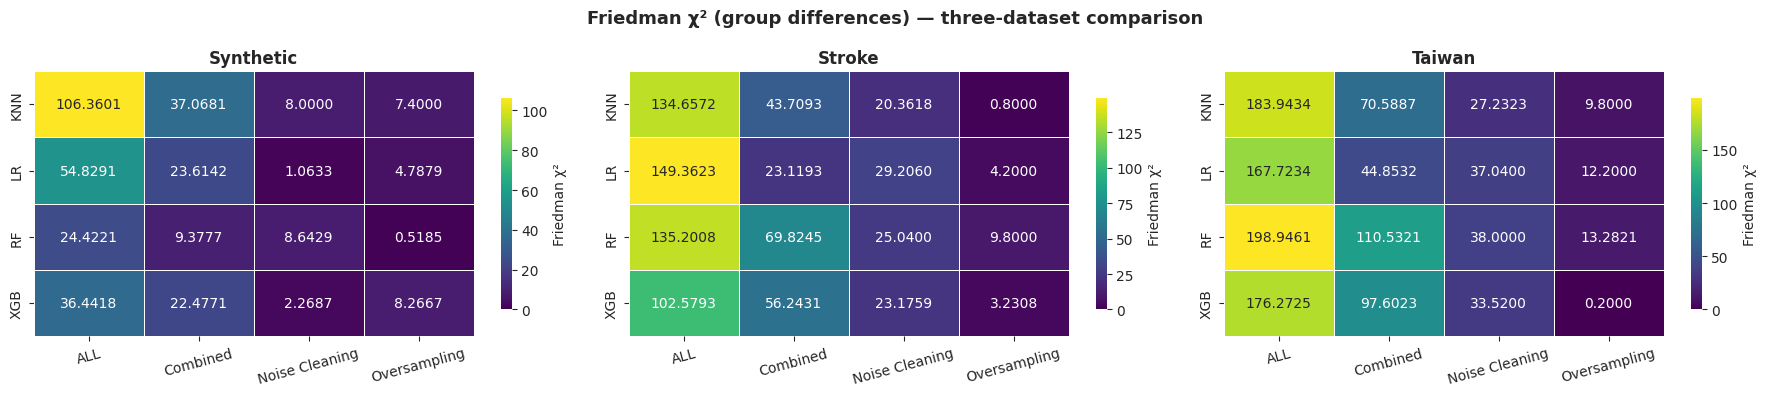

Fig B — cross-dataset Friedman χ² saved.


In [131]:
# Fig B — Friedman χ² side-by-side across all three datasets
all_stat_df_list = []
for ds_name, recs in all_stat_records.items():
    df_temp = pd.DataFrame(recs)
    df_temp["Dataset"] = ds_name
    all_stat_df_list.append(df_temp)
all_stat_df = pd.concat(all_stat_df_list, ignore_index=True)

fig_b, axes_b = plt.subplots(1, 3, figsize=(18, 4))

fig_b.suptitle(
    "Friedman χ² (group differences) — three-dataset comparison",
    fontsize=13,
    fontweight="bold",
)

for ax, ds_name in zip(
    axes_b, ["Synthetic", "Stroke", "Taiwan"]
):

    subset = all_stat_df[
        all_stat_df["Dataset"] == ds_name
    ]

    # pivot: classifier × group → Friedman statistic
    pivot = subset.pivot(
        index="Clf",
        columns="Group",
        values="friedman_stat"
    )

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".4f",
        cmap="viridis",
        ax=ax,
        linewidths=0.5,
        vmin=0,
        vmax=pivot.max().max(),
        cbar_kws={
            "label": "Friedman χ²",
            "shrink": 0.8
        },
    )

    ax.set_title(ds_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figB_cross_friedman_chi2.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("Fig B — cross-dataset Friedman χ² saved.")

###Cohen's D

In [124]:
# ── EFFECT SIZE SUMMARY TABLE ─────────────────────────────
# Concatenate effect size records from all three datasets
# (Synthetic, Stroke, Taiwan) into a single diagnostic table.
#
# Each row represents one Classifier x Group x Dataset
# combination and contains the following columns:
#
# n_obs        — Number of observations used to compute
#                Cohen's d for the intervention group.
#                Always 10 (5 folds x 2 repeats), matching
#                the None baseline. Each observation is the
#                mean score across all samplers in the group
#                for one fold, ensuring both arrays are
#                comparable at the same aggregation level.
#
# mean_group   — Mean balanced accuracy of the intervention
#                group, averaged across all 10 fold-mean
#                values. Higher is better.
#
# std_group    — Standard deviation of the 10 fold-mean
#                scores for the intervention group (ddof=1).
#                Reflects genuine fold-to-fold variability
#                within the group. Small values indicate
#                the group performs consistently across folds.
#
# mean_none    — Mean balanced accuracy of the no-resampling
#                baseline (None sampler), averaged across
#                its 10 fold-level scores. Used as the
#                reference point for all effect size and
#                delta calculations.
#
# std_none     — Standard deviation of the 10 fold-level
#                scores for the None baseline (ddof=1).
#                Very small values (e.g. 0.004 for LR on
#                Stroke) indicate the baseline is nearly
#                perfectly stable across folds because the
#                classifier always predicts the majority
#                class under severe imbalance.
#
# raw_pool_std — Pooled standard deviation computed directly
#                from std_group and std_a before the SD floor
#                is applied:
#                    raw_pool = sqrt((std_group^2 + std_none^2) / 2)
#                When this value is very small (e.g. < 0.01),
#                the SD floor activates and pooled_std is
#                used instead. Inspect this column to see
#                exactly when and how much the floor changes
#                the result.
#
# pooled_std   — Final pooled standard deviation used in the
#                Cohen's d denominator after the SD floor is
#                applied:
#                    pooled_std = max(raw_pool_std, MIN_POOLED_SD)
#                When pooled_std == raw_pool_std, the floor
#                had no effect. When pooled_std == 0.01 and
#                raw_pool_std < 0.01, the floor was applied.
#
# delta        — Absolute mean difference in balanced accuracy
#                between the intervention group and the None
#                baseline:
#                    delta = mean_group - mean_none
#                Positive values indicate the intervention
#                group outperforms the baseline. This is the
#                most direct measure of practical improvement
#                and is not affected by the SD floor.
#
# cohens_d     — Standardised effect size:
#                    d = delta / pooled_std
#                Answers: "How many standard deviations apart
#                are the two groups?" Interpreted as:
#                    negligible : |d| < 0.20
#                    small      : 0.20 <= |d| < 0.50
#                    medium     : 0.50 <= |d| < 0.80
#                    large      : |d| >= 0.80  (Cohen, 1988)
#                Because the SD floor (MIN_POOLED_SD = 0.01)
#                is applied, very large d values from near-zero
#                baseline variance are capped at a meaningful
#                level. Always read cohens_d alongside delta
#                to assess both statistical and practical
#                magnitude of the observed difference.
# ─────────────────────────────────────────────────────────

all_effects_df = pd.concat(
    [pd.DataFrame(recs) for recs in all_effect_records.values()],
    ignore_index=True,
)
all_effects_df

,Dataset,Clf,Group,n_obs,mean_group,std_group,mean_none,std_none,raw_pool_std,pooled_std,delta,cohens_d,interp
0,Synthetic,LR,Noise Cleaning,10,0.6628,0.0761,0.6484,0.0840,0.0801,0.0801,0.0144,0.1800,negligible
1,Synthetic,LR,Oversampling,10,0.7756,0.0855,0.6484,0.0840,0.0847,0.0847,0.1272,1.5009,large
2,Synthetic,LR,Combined,10,0.7665,0.0773,0.6484,0.0840,0.0807,0.0807,0.1180,1.4623,large
3,Synthetic,KNN,Noise Cleaning,10,0.5635,0.0662,0.5595,0.0696,0.0679,0.0679,0.0040,0.0589,negligible
4,Synthetic,KNN,Oversampling,10,0.7054,0.0979,0.5595,0.0696,0.0849,0.0849,0.1460,1.7186,large
5,Synthetic,KNN,Combined,10,0.6986,0.0947,0.5595,0.0696,0.0831,0.0831,0.1392,1.6745,large
6,Synthetic,RF,Noise Cleaning,10,0.5220,0.0346,0.5100,0.0316,0.0331,0.0331,0.0120,0.3622,small
7,Synthetic,RF,Oversampling,10,0.5795,0.0654,0.5100,0.0316,0.0514,0.0514,0.0695,1.3524,large
8,Synthetic,RF,Combined,10,0.5748,0.0647,0.5100,0.0316,0.0509,0.0509,0.0648,1.2733,large
9,Synthetic,XGB,Noise Cleaning,10,0.6553,0.0573,0.6795,0.1032,0.0835,0.0835,-0.0242,-0.2901,small


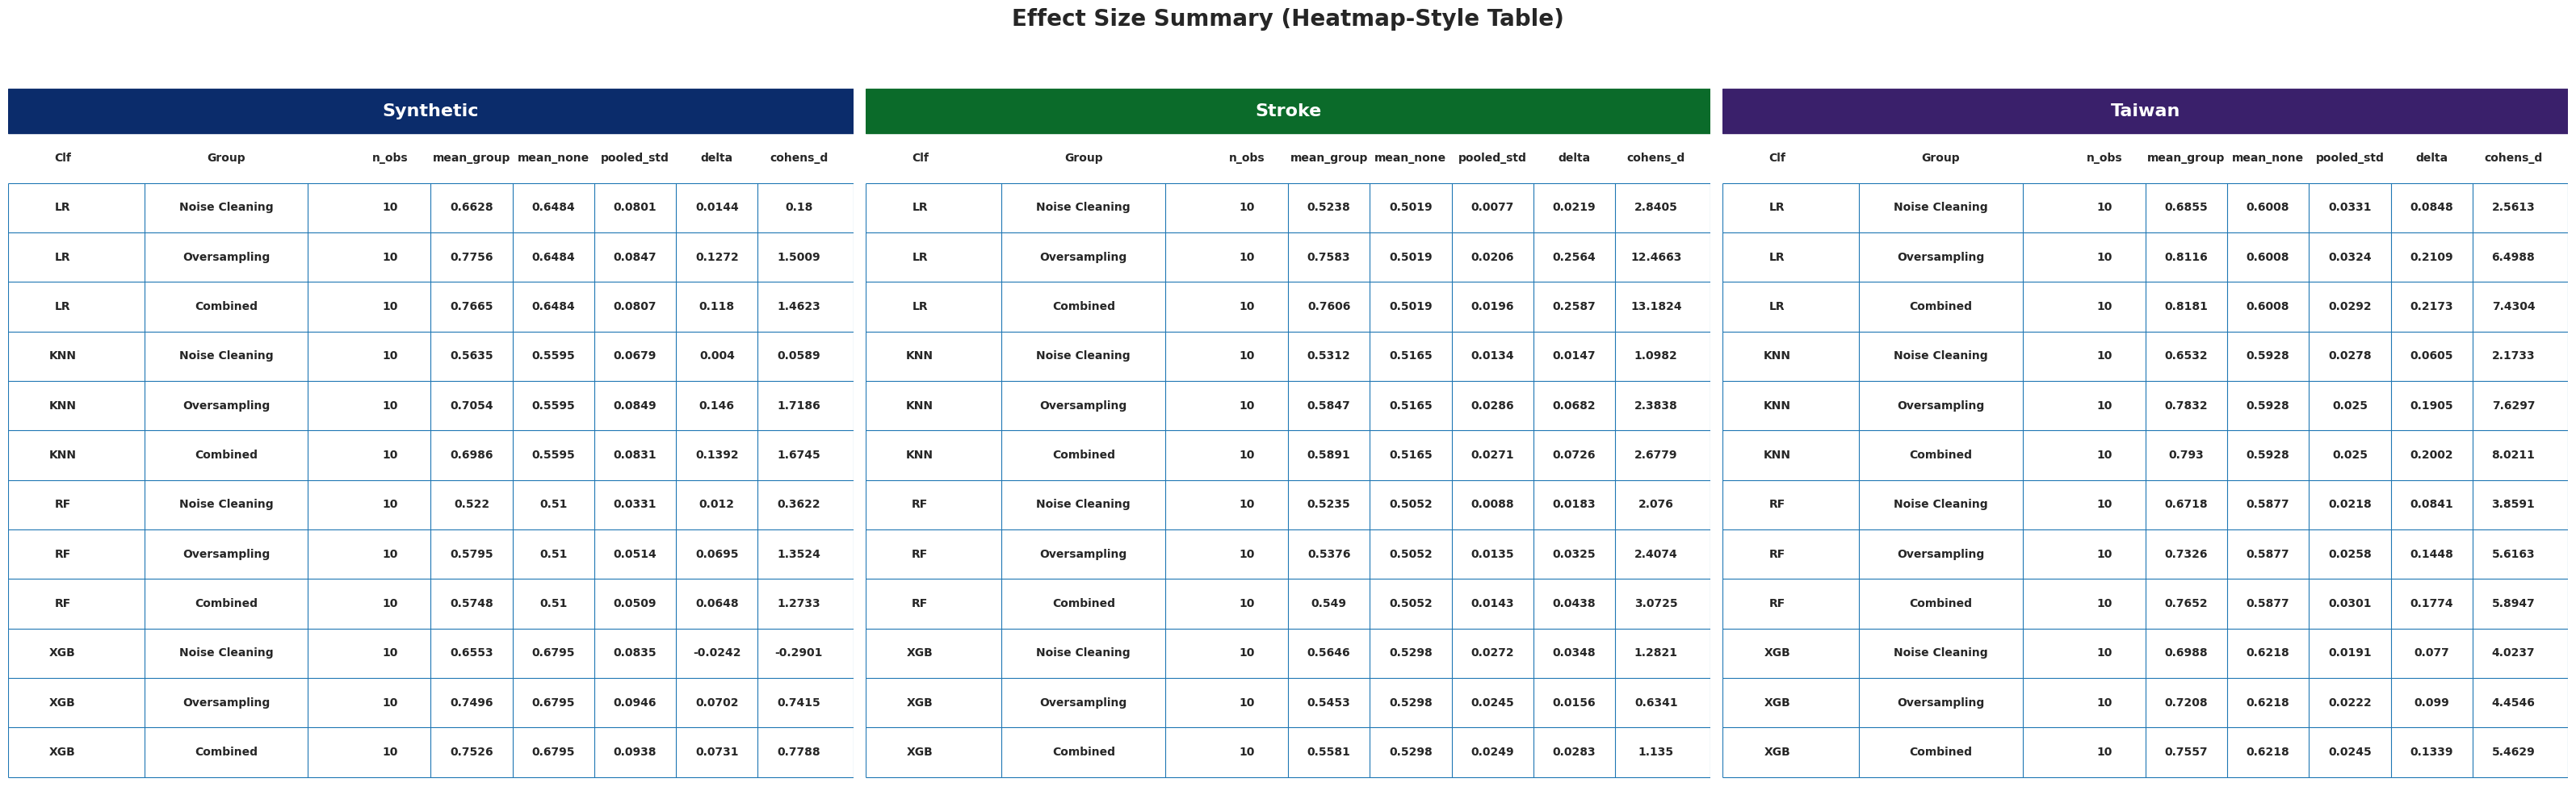

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =========================
# Combine all datasets
# =========================
all_effects_df = pd.concat(
    [pd.DataFrame(recs) for recs in all_effect_records.values()],
    ignore_index=True
)

# Round numeric columns
numeric_cols = [
    'n_obs', 'mean_group', 'mean_none',
    'pooled_std', 'delta', 'cohens_d'
]
all_effects_df[numeric_cols] = all_effects_df[numeric_cols].round(4)

datasets = all_effects_df['Dataset'].unique()

# Dataset header colors
header_colors = {
    'Synthetic': '#0b2c6b',
    'Stroke': '#0b6b2a',
    'Taiwan': '#3a206b'
}

# =========================
# Create subplots
# =========================
fig, axes = plt.subplots(1, len(datasets), figsize=(32, 10))
fig.suptitle(
    'Effect Size Summary (Heatmap-Style Table)',
    fontsize=20,
    fontweight='bold',
    y=0.98
)

if len(datasets) == 1:
    axes = [axes]

# Column positions
x_positions = [0, 3, 6, 7.5, 9, 10.5, 12, 13.5]

# Vertical borders
x_lines = [-1, 1.5, 4.5, 6.75, 8.25, 9.75, 11.25, 12.75, 14.5]

col_names = [
    'Clf', 'Group', 'n_obs',
    'mean_group', 'mean_none',
    'pooled_std', 'delta', 'cohens_d'
]

# =========================
# Draw each dataset
# =========================
for ax, ds in zip(axes, datasets):

    df_sub = all_effects_df[
        all_effects_df['Dataset'] == ds
    ][col_names]

    n_rows = len(df_sub)

    ax.set_xlim(-1, 14.5)
    ax.set_ylim(n_rows + 0.5, -1.8)

    # -------------------------
    # Dataset colored header
    # -------------------------
    ax.add_patch(
        Rectangle(
            (-1, -1.6),
            15.5,
            0.9,
            color=header_colors.get(ds, 'gray')
        )
    )

    ax.text(
        6.75,
        -1.15,
        ds,
        ha='center',
        va='center',
        fontsize=16,
        fontweight='bold',
        color='white'
    )

    # -------------------------
    # Column headers
    # -------------------------
    for j, x in enumerate(x_positions):
        ax.text(
            x,
            -0.2,
            col_names[j],
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold'
        )

    # -------------------------
    # Cell values
    # -------------------------
    for i in range(n_rows):
        for j, x in enumerate(x_positions):
            ax.text(
                x,
                i + 0.8,
                str(df_sub.iloc[i, j]),
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold'
            )

    # -------------------------
    # Grid lines
    # -------------------------
    for y in range(n_rows + 1):
        ax.hlines(
            y + 0.3,
            -1,
            14.5,
            linewidth=0.8
        )

    for x in x_lines:
        ax.vlines(
            x,
            0.3,
            n_rows + 0.3,
            linewidth=0.8
        )

    # Outer border
    ax.add_patch(
        Rectangle(
            (-1, 0.3),
            15.5,
            n_rows,
            fill=False,
            linewidth=1.2
        )
    )

    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

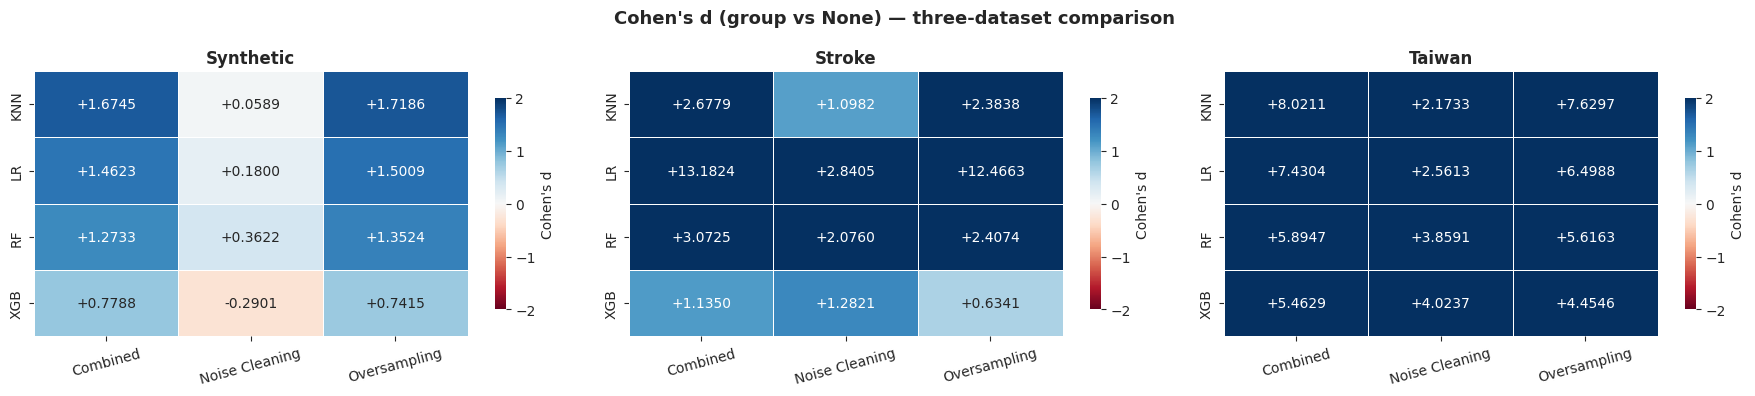

Fig B — cross-dataset Cohen's d saved.


In [125]:
# Fig B — Cohen's d side-by-side across all three datasets
fig_b, axes_b = plt.subplots(1, 3, figsize=(18, 4))
fig_b.suptitle(
    "Cohen's d (group vs None) — three-dataset comparison",
    fontsize=13, fontweight="bold",
)
for ax, ds_name in zip(
    axes_b, ["Synthetic", "Stroke", "Taiwan"]
):
    subset = all_effects_df[
        all_effects_df["Dataset"] == ds_name
    ]
    pivot  = subset.pivot(
        index="Clf", columns="Group", values="cohens_d"
    )
    sns.heatmap(
        pivot, annot=True, fmt="+.4f",
        cmap="RdBu", center=0, ax=ax,
        linewidths=0.5, vmin=-2, vmax=2,
        cbar_kws={"label": "Cohen's d", "shrink": 0.8},
    )
    ax.set_title(ds_name, fontsize=12, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figB_cross_cohens_d.png",
    dpi=150, bbox_inches="tight",
)
plt.show(); print("Fig B — cross-dataset Cohen's d saved.")

#Final Result Summaries

In [109]:
# ─────────────────────────────────────────
# 14. Final summaries — all three datasets
# ─────────────────────────────────────────
for ds_name, (df, _) in all_results.items():
    print(f"\n{'='*65}")
    print(f"  SUMMARY — {ds_name}")
    print(f"{'='*65}")

    print("\n  Mean metrics by group:")
    print(
        df.groupby("Group")[
            ["balanced_accuracy", "f1", "roc_auc"]
        ].mean().round(4).to_string()
    )

    print("\n  Top 10 overall (no averaging):")
    print(
        df.nlargest(10, "balanced_accuracy")
          [["Group", "Sampler", "Clf",
            "balanced_accuracy", "f1", "roc_auc"]]
          .to_string(index=False)
    )

    df_best = (
        df.sort_values("balanced_accuracy", ascending=False)
          .groupby("Clf", sort=False).first().reset_index()
          [["Clf", "Group", "Sampler",
            "balanced_accuracy", "f1", "roc_auc"]]
          .sort_values("balanced_accuracy", ascending=False)
    )
    print("\n  Best sampler per classifier:")
    for _, row in df_best.iterrows():
        print(
            f"    {row['Clf']:4s} -> "
            f"{row['Group']:15s} | "
            f"{row['Sampler']:12s} | "
            f"Bal.Acc={row['balanced_accuracy']:.3f}  "
            f"F1={row['f1']:.3f}  "
            f"AUC={row['roc_auc']:.3f}"
        )

print("\nAll experiments, figures, and summaries complete.")


  SUMMARY — Synthetic

  Mean metrics by group:
                balanced_accuracy      f1  roc_auc
Group                                             
Combined                   0.6981  0.3111   0.7808
Noise Cleaning             0.6009  0.2854   0.7642
None                       0.5993  0.2817   0.7621
Oversampling               0.7025  0.3188   0.7786

  Top 10 overall (no averaging):
       Group   Sampler Clf  balanced_accuracy       f1  roc_auc
    Combined BSMT+AKNN  LR           0.787895 0.418092 0.806316
    Combined  BSMT+ENN  LR           0.787368 0.414283 0.807158
    Combined BSMT+RENN  LR           0.787368 0.414283 0.807158
Oversampling      BSMT  LR           0.786842 0.413189 0.801895
    Combined   BSMT+TL  LR           0.785789 0.403899 0.804000
Oversampling       SMT  LR           0.772105 0.326934 0.767579
    Combined   SMT+ENN  LR           0.772105 0.326934 0.767579
    Combined  SMT+RENN  LR           0.772105 0.326934 0.767579
    Combined  SMT+AKNN  LR         

#Pooled Group

In [110]:
# ─────────────────────────────────────────
# 15. Pooled cross-dataset analysis
#     Average all three datasets per sampler
#     then run statistical testing and visualise
# ─────────────────────────────────────────

print("\n" + "=" * 65)
print("  POOLED ANALYSIS — averaged across all three datasets")
print("=" * 65)

# ── 15a. Build pooled dataframes ────────────────────────────
# df_pool      : mean score per (Group, Sampler, Clf)
#                averaged across all three datasets
# df_fold_pool : mean fold score per (Group, Sampler, Clf, fold)
#                averaged across all three datasets

records_pool      = []
fold_records_pool = []

for group_name, samplers_dict in GROUPS.items():
    for sampler_name in samplers_dict:
        for clf_name in classifiers:
            # Collect per-dataset mean scores
            ds_means = {}
            for ds_name, (df, df_fold) in all_results.items():
                row = df[
                    (df["Group"]   == group_name) &
                    (df["Sampler"] == sampler_name) &
                    (df["Clf"]     == clf_name)
                ]
                if row.empty:
                    continue
                ds_means[ds_name] = {
                    m: row[m].values[0] for m in METRICS
                }

            if not ds_means:
                continue

            # Average metrics across datasets
            pooled_means = {
                m: np.mean([ds_means[d][m] for d in ds_means])
                for m in METRICS
            }
            records_pool.append({
                "Group":   group_name,
                "Sampler": sampler_name,
                "Clf":     clf_name,
                **pooled_means,
            })

            # Average per-fold scores across datasets
            # Align on fold index (all datasets use same 10 folds)
            for fold_idx in range(CV_SPLITS * CV_REPEATS):
                fold_vals = {}
                for ds_name, (df, df_fold) in all_results.items():
                    sub = df_fold[
                        (df_fold["Group"]   == group_name) &
                        (df_fold["Sampler"] == sampler_name) &
                        (df_fold["Clf"]     == clf_name) &
                        (df_fold["fold"]    == fold_idx)
                    ]
                    if sub.empty:
                        continue
                    fold_vals[ds_name] = {
                        m: sub[m].values[0] for m in METRICS
                    }
                if not fold_vals:
                    continue
                pooled_fold = {
                    m: np.mean([fold_vals[d][m] for d in fold_vals])
                    for m in METRICS
                }
                fold_records_pool.append({
                    "Group":   group_name,
                    "Sampler": sampler_name,
                    "Clf":     clf_name,
                    "fold":    fold_idx,
                    **pooled_fold,
                })

df_pool      = pd.DataFrame(records_pool)
df_fold_pool = pd.DataFrame(fold_records_pool)

print(f"\nPooled df rows      : {len(df_pool)}")
print(f"Pooled df_fold rows : {len(df_fold_pool)}")


  POOLED ANALYSIS — averaged across all three datasets

Pooled df rows      : 96
Pooled df_fold rows : 960


###Mean Metrics by Group

In [77]:
# ── 15b. Aggregated group summary ───────────────────────────
df_pool_agg = (
    df_pool.groupby(["Group", "Sampler"])[METRICS]
    .mean().reset_index()
    .sort_values("balanced_accuracy", ascending=False)
)

print("\n  Pooled mean metrics by group (averaged over classifiers):")
print(
    df_pool.groupby("Group")[
        ["balanced_accuracy", "f1", "roc_auc",'recall', 'precision']
    ].mean().round(4).to_string()
)


  Pooled mean metrics by group (averaged over classifiers):
                balanced_accuracy      f1  roc_auc  recall  precision
Group                                                                
Combined                   0.6984  0.2776   0.8119  0.5006     0.2346
Noise Cleaning             0.6047  0.2627   0.8085  0.2232     0.4015
None                       0.5712  0.2088   0.8004  0.1464     0.4500
Oversampling               0.6904  0.2815   0.8088  0.4766     0.2451


##Best Sampler for Each Classifier

In [78]:
# ── Best Sampler for Each Classifier ───────────────────────
print("\n" + "=" * 113)
print("BEST SAMPLER FOR EACH CLASSIFIER")
print("Pooled across Synthetic + Stroke + Taiwan")
print("=" * 113)

# Mean metrics by classifier × sampler
df_best_sampler = (
    df_pool
    .groupby(["Clf", "Group", "Sampler"])[METRICS]
    .mean()
    .reset_index()
)

# Select best sampler per classifier using balanced accuracy
idx_best = (
    df_best_sampler
    .groupby("Clf")["balanced_accuracy"]
    .idxmax()
)

df_best_per_clf = (
    df_best_sampler
    .loc[idx_best]
    .sort_values("balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)

# Print results
print(
    f"\n{'Classifier':<20} {'Group':<18} {'Best Sampler':<18} "
    f"{'Bal.Acc':>10} {'F1':>10} {'AUC':>10} {'Recall':>10} {'Precision':>10}"
)
print("-" * 113)

for _, row in df_best_per_clf.iterrows():
    print(
        f"{row['Clf']:<20} "
        f"{row['Group']:<18} "
        f"{row['Sampler']:<18} "
        f"{row['balanced_accuracy']:>10.4f} "
        f"{row['f1']:>10.4f} "
        f"{row['roc_auc']:>10.4f}"
        f"{row['recall']:>10.4f}"
        f"{row['precision']:>10.4f}"

    )



BEST SAMPLER FOR EACH CLASSIFIER
Pooled across Synthetic + Stroke + Taiwan

Classifier           Group              Best Sampler          Bal.Acc         F1        AUC     Recall  Precision
-----------------------------------------------------------------------------------------------------------------
LR                   Combined           BSMT+RENN              0.7911     0.3268     0.8474    0.7178    0.2207
XGB                  Combined           SMT+RENN               0.7200     0.3654     0.8450    0.4992    0.3260
KNN                  Combined           BSMT+AKNN              0.7091     0.2410     0.7371    0.5658    0.1543
RF                   Combined           SMT+RENN               0.6593     0.2491     0.8404    0.3771    0.2419


##Best Classifier for Each Sampler

In [79]:
# ── Best Classifier for Each Sampler ───────────────────────
print("\n" + "=" * 123)
print("BEST CLASSIFIER FOR EACH SAMPLER")
print("Pooled across Synthetic + Stroke + Taiwan")
print("=" * 123)

# Mean metrics by sampler × classifier
df_best_clf = (
    df_pool
    .groupby(["Group", "Sampler", "Clf"])[METRICS]
    .mean()
    .reset_index()
)

# Select best classifier per sampler using balanced accuracy
idx_best = (
    df_best_clf
    .groupby("Sampler")["balanced_accuracy"]
    .idxmax()
)

df_best_per_sampler = (
    df_best_clf
    .loc[idx_best]
    .sort_values(["Group", "balanced_accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)

# Add rank
df_best_per_sampler.index += 1

# Print table
print(
    f"\n{'Rank':<5} {'Group':<18} {'Sampler':<20} "
    f"{'Best Classifier':<22} "
    f"{'Bal.Acc':>10} {'F1':>10} {'AUC':>10} {'Recall':>10} {'Precision':>10}"
)
print("-" * 123)

for rank, row in df_best_per_sampler.iterrows():
    print(
        f"{rank:<5} "
        f"{row['Group']:<18} "
        f"{row['Sampler']:<20} "
        f"{row['Clf']:<22} "
        f"{row['balanced_accuracy']:>10.4f} "
        f"{row['f1']:>10.4f} "
        f"{row['roc_auc']:>10.4f} {row['recall']:>10.4f}"
        f"{row['precision']:>10.4f}"
    )



BEST CLASSIFIER FOR EACH SAMPLER
Pooled across Synthetic + Stroke + Taiwan

Rank  Group              Sampler              Best Classifier           Bal.Acc         F1        AUC     Recall  Precision
---------------------------------------------------------------------------------------------------------------------------
1     Combined           BSMT+RENN            LR                         0.7911     0.3268     0.8474     0.7178    0.2207
2     Combined           SMT+RENN             LR                         0.7885     0.2702     0.8331     0.7657    0.1687
3     Combined           BSMT+AKNN            LR                         0.7880     0.3278     0.8449     0.7104    0.2226
4     Combined           SMT+AKNN             LR                         0.7879     0.2719     0.8323     0.7633    0.1701
5     Combined           SMT+ENN              LR                         0.7846     0.2835     0.8286     0.7343    0.1794
6     Combined           SMT+TL               LR            

##Strip Plots: None vs Noise Cleaning vs Oversampling vs Combined (Mean Over Classifiers, All Samplers)

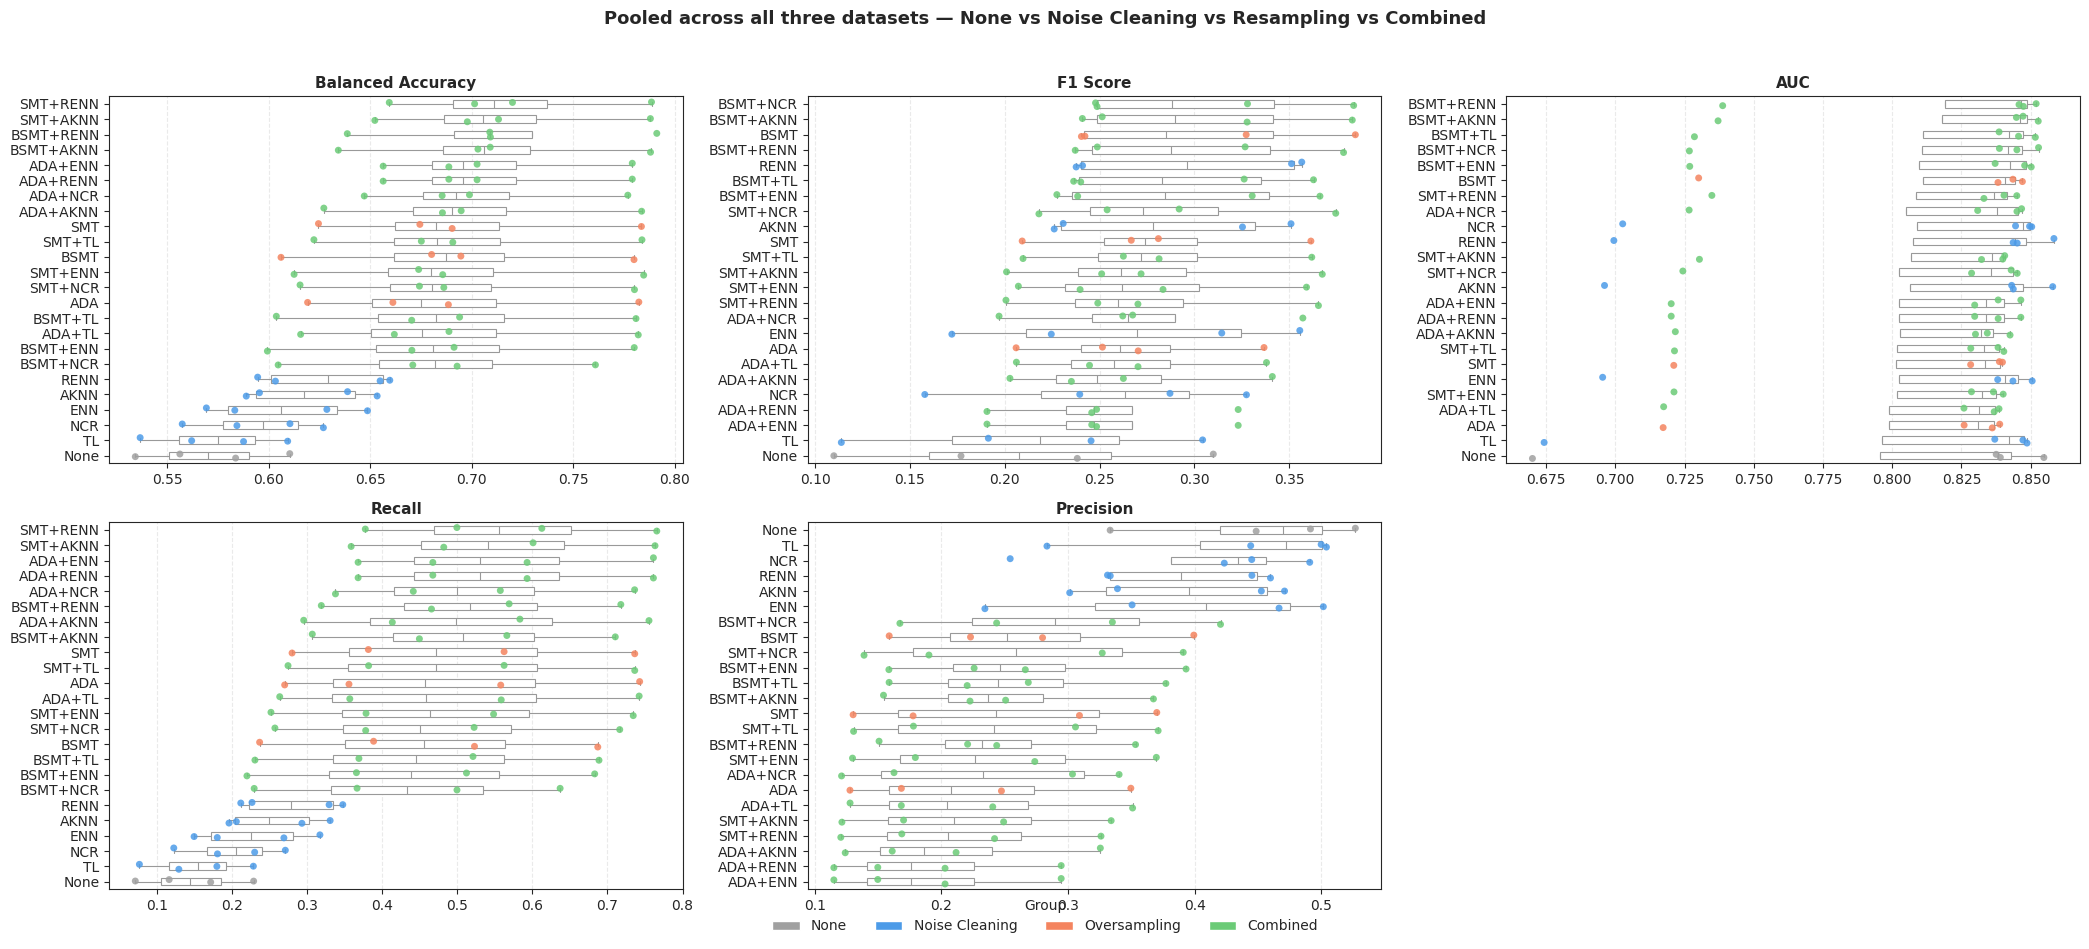

Fig P1 — pooled strip plot (all metrics) saved.


In [80]:
# ── 15c. Fig P1 — Pooled strip plot (ALL metrics) ──────────
import math

n_metrics = len(METRICS)
n_cols = 3
n_rows = math.ceil(n_metrics / n_cols)

fig_p1, axes_p1 = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, 4.5 * n_rows),
    sharey=False
)

# Flatten axes for easy looping
axes_p1 = axes_p1.flatten()

fig_p1.suptitle(
    "Pooled across all three datasets — "
    "None vs Noise Cleaning vs Resampling vs Combined",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

DISPLAY_NAMES = {
    "balanced_accuracy": "Balanced Accuracy",
    "f1": "F1 Score",
    "roc_auc": "AUC",
    "recall": "Recall",
    "precision": "Precision"
}

for i, metric in enumerate(METRICS):
    ax = axes_p1[i]

    label = DISPLAY_NAMES.get(metric, metric)

    order = (
        df_pool.groupby("Sampler")[metric]
        .mean()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    sns.boxplot(
        data=df_pool,
        x=metric,
        y="Sampler",
        order=order,
        color="white",
        linewidth=0.8,
        fliersize=0,
        width=0.5,
        ax=ax,
    )

    sns.stripplot(
        data=df_pool,
        x=metric,
        y="Sampler",
        order=order,
        hue="Group",
        palette=GROUP_COLORS,
        size=5,
        alpha=0.85,
        jitter=0.2,
        legend=False,
        ax=ax,
    )

    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

# Remove unused empty subplots
for j in range(n_metrics, len(axes_p1)):
    fig_p1.delaxes(axes_p1[j])

fig_p1.legend(
    handles=[
        Patch(facecolor=c, label=g)
        for g, c in GROUP_COLORS.items()
    ],
    title="Group",
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
    fontsize=10,
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figP1_pooled_strip_all_metrics.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Fig P1 — pooled strip plot (all metrics) saved.")

##Heatmap: Full Sampler × Classifier (Clf) Per-Metric Best

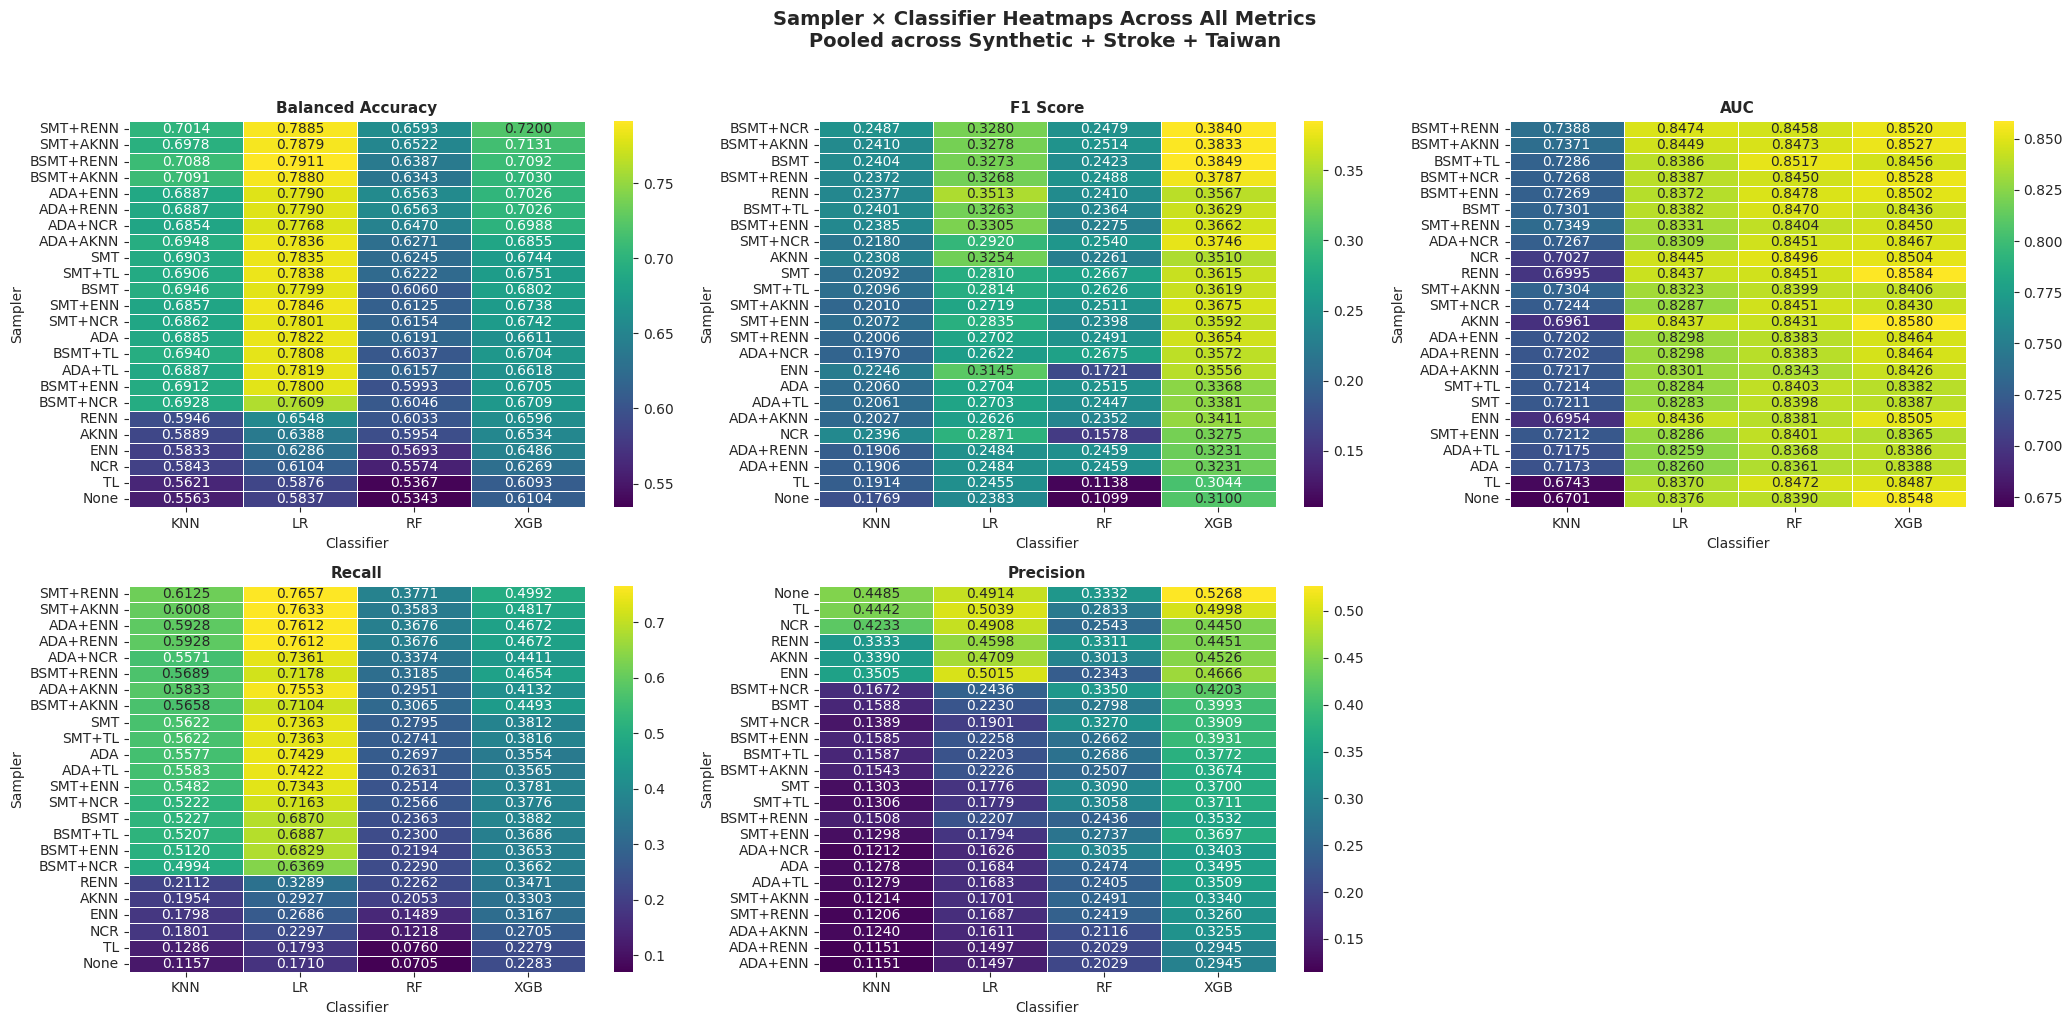

Fig P2 — heatmap for all metrics saved.


In [81]:
# ── Fig P2 — Heatmap for each metric ───────────────────────
import math

n_metrics = len(METRICS)
n_cols = 3
n_rows = math.ceil(n_metrics / n_cols)

fig_hm, axes_hm = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, 5 * n_rows)
)

axes_hm = axes_hm.flatten()

DISPLAY_NAMES = {
    "balanced_accuracy": "Balanced Accuracy",
    "f1": "F1 Score",
    "roc_auc": "AUC",
    "recall": "Recall",
    "precision": "Precision"
}

fig_hm.suptitle(
    "Sampler × Classifier Heatmaps Across All Metrics\n"
    "Pooled across Synthetic + Stroke + Taiwan",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

for i, metric in enumerate(METRICS):
    ax = axes_hm[i]

    pivot_metric = df_pool.pivot_table(
        index="Sampler",
        columns="Clf",
        values=metric,
        aggfunc="mean"
    )

    # sort rows by mean performance
    pivot_metric = pivot_metric.loc[
        pivot_metric.mean(axis=1)
        .sort_values(ascending=False)
        .index
    ]

    sns.heatmap(
        pivot_metric,
        annot=True,
        fmt=".4f",
        linewidths=0.5,
        cmap="viridis",
        cbar=True,
        ax=ax
    )

    ax.set_title(
        DISPLAY_NAMES.get(metric, metric),
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Classifier")
    ax.set_ylabel("Sampler")

# remove empty panels
for j in range(n_metrics, len(axes_hm)):
    fig_hm.delaxes(axes_hm[j])

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "figP2_heatmap_all_metrics.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Fig P2 — heatmap for all metrics saved.")

##Bar Chart for Mean Metic by Group

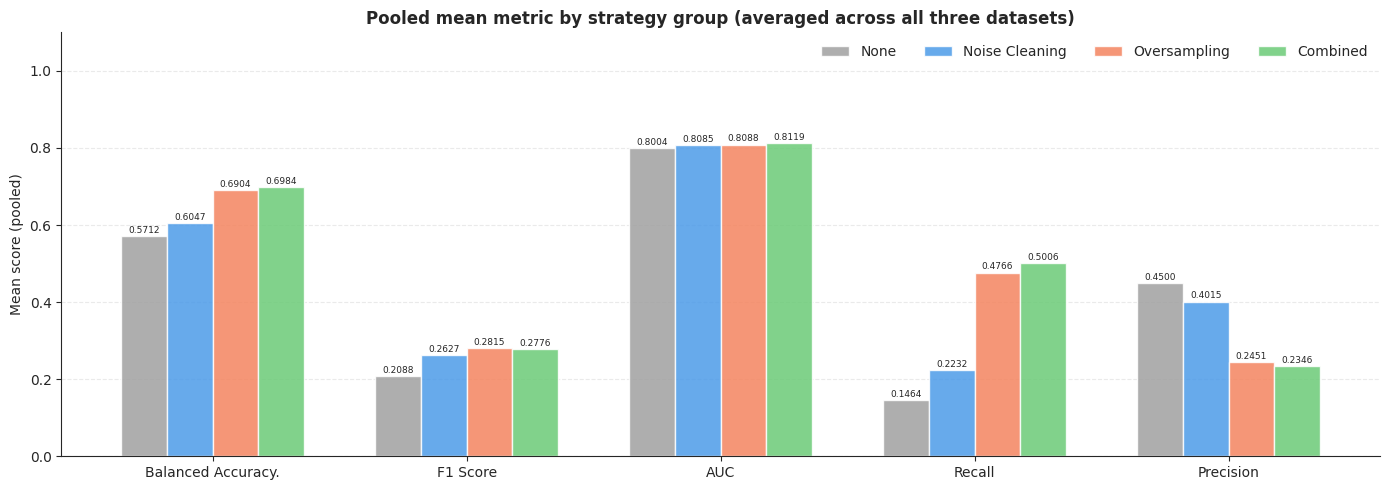

Fig P2 — pooled group bar saved.


In [24]:
# ── 15d. Fig P2 — Pooled grouped bar ────────────────────────
df_pool_gm = (
    df_pool.groupby("Group")[METRICS].mean().reset_index()
    .melt(id_vars="Group", var_name="Metric", value_name="Score")
)
fig_p2, ax_p2 = plt.subplots(figsize=(14, 5))
x       = np.arange(len(METRICS))
width   = 0.18
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]
for grp, offset in zip(list(GROUP_COLORS), offsets):
    subset = df_pool_gm[df_pool_gm["Group"] == grp]
    vals   = [
        subset[subset["Metric"] == m]["Score"].values[0]
        for m in METRICS
    ]
    bars = ax_p2.bar(
        x + offset, vals, width, label=grp,
        color=GROUP_COLORS[grp], alpha=.85, edgecolor="white",
    )
    for bar, v in zip(bars, vals):
        ax_p2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + .003,
            f"{v:.4f}", ha="center", va="bottom", fontsize=6.5,
        )
ax_p2.set_xticks(x)
ax_p2.set_xticklabels(
    ["Balanced Accuracy.", "F1 Score", "AUC", "Recall", "Precision"], fontsize=10
)
ax_p2.set_ylim(0, 1.1)
ax_p2.set_ylabel("Mean score (pooled)")
ax_p2.set_title(
    "Pooled mean metric by strategy group "
    "(averaged across all three datasets)",
    fontsize=12, fontweight="bold",
)
ax_p2.legend(frameon=False, ncol=4)
ax_p2.grid(axis="y", linestyle="--", alpha=.4)
sns.despine(); plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figP2_pooled_group_bar.png",
    dpi=150, bbox_inches="tight",
)
plt.show(); print("Fig P2 — pooled group bar saved.")

##Statistical Testing

In [29]:
# ── 15e. Pooled statistical testing ─────────────────────────
print(f"\n{'='*65}")
print("  POOLED STATISTICAL TESTING")
print(f"  metric: {STAT_METRIC}  |  alpha = {ALPHA}")
print(f"{'='*65}")

pool_stat_records = []

# Friedman across all samplers per classifier (pooled)
for clf_name in classifiers:
    sub  = df_fold_pool[df_fold_pool["Clf"] == clf_name]
    stat, p, _ = friedman_and_posthoc(
        sub, "Sampler", STAT_METRIC,
        label=f"[Pooled] Clf={clf_name} | "
              f"{sub['Sampler'].nunique()} samplers",
    )
    pool_stat_records.append({
        "Clf": clf_name, "Group": "ALL",
        "friedman_stat": stat, "friedman_p": p,
    })

# Friedman within each group x classifier (pooled)
for group_name in GROUPS:
    for clf_name in classifiers:
        sub = df_fold_pool[
            (df_fold_pool["Group"] == group_name) &
            (df_fold_pool["Clf"]   == clf_name)
        ]
        if sub["Sampler"].nunique() < 2:
            continue
        stat, p, _ = friedman_and_posthoc(
            sub, "Sampler", STAT_METRIC,
            label=f"[Pooled] Group={group_name} | Clf={clf_name}",
        )
        pool_stat_records.append({
            "Clf": clf_name, "Group": group_name,
            "friedman_stat": stat, "friedman_p": p,
        })

# Friedman: 4 groups vs each other (pooled)
print(f"\n{'='*65}")
print("[Pooled] Friedman: 4 GROUPS vs each other")
print(f"{'='*65}")
friedman_and_posthoc(
    df_fold_pool.groupby(["Group", "fold"])[STAT_METRIC]
                .mean().reset_index(),
    "Group", STAT_METRIC,
    label="[Pooled] All classifiers pooled",
)


  POOLED STATISTICAL TESTING
  metric: balanced_accuracy  |  alpha = 0.05

───────────────────────────────────────────────────────
[Pooled] Clf=LR | 24 samplers
  Friedman chi2 = 141.7703,  p = 4.3521e-19  (SIGNIFICANT)
  Nemenyi significant pairs:
    None                 vs SMT                   p=0.0023 *
    None                 vs BSMT                  p=0.0194 *
    None                 vs ADA                   p=0.0120 *
    None                 vs SMT+ENN               p=0.0006 *
    None                 vs SMT+RENN              p=0.0000 *
    None                 vs SMT+AKNN              p=0.0001 *
    None                 vs SMT+NCR               p=0.0007 *
    None                 vs SMT+TL                p=0.0004 *
    None                 vs BSMT+ENN              p=0.0063 *
    None                 vs BSMT+RENN             p=0.0000 *
    None                 vs BSMT+AKNN             p=0.0001 *
    None                 vs BSMT+NCR              p=0.0172 *
    None          

(np.float64(30.0),
 np.float64(1.3800570312932553e-06),
                 Combined  Noise Cleaning      None  Oversampling
 Combined        1.000000        0.002989  0.000001      0.306950
 Noise Cleaning  0.002989        1.000000  0.306950      0.306950
 None            0.000001        0.306950  1.000000      0.002989
 Oversampling    0.306950        0.306950  0.002989      1.000000)

###Friedman: 4 Classifiers Vs. Each Other

In [30]:
# Friedman: 4 classifiers vs each other (pooled)
print(f"\n{'='*65}")
print("[Pooled] Friedman: 4 CLASSIFIERS vs each other")
print(f"{'='*65}")
friedman_and_posthoc(
    df_fold_pool.groupby(["Clf", "fold"])[STAT_METRIC]
                .mean().reset_index(),
    "Clf", STAT_METRIC,
    label="[Pooled] All samplers pooled",
)


[Pooled] Friedman: 4 CLASSIFIERS vs each other

───────────────────────────────────────────────────────
[Pooled] All samplers pooled
  Friedman chi2 = 27.1200,  p = 5.5560e-06  (SIGNIFICANT)
  Nemenyi significant pairs:
    KNN                  vs LR                    p=0.0286 *
    LR                   vs RF                    p=0.0000 *
    RF                   vs XGB                   p=0.0286 *


(np.float64(27.120000000000005),
 np.float64(5.55598717156124e-06),
           KNN        LR        RF       XGB
 KNN  1.000000  0.028563  0.072451  0.985723
 LR   0.028563  1.000000  0.000001  0.072451
 RF   0.072451  0.000001  1.000000  0.028563
 XGB  0.985723  0.072451  0.028563  1.000000)

###Wilcoxon + Holm: None Vs. Each Group Per Classifier

In [46]:
# Wilcoxon + Holm: None vs each group per classifier (pooled)
print(f"\n{'='*65}")
print("[Pooled] None vs each group — Wilcoxon + Holm")
print(f"{'='*65}")

pool_wilcox_records = []
for clf_name in classifiers:
    none_vals = df_fold_pool[
        (df_fold_pool["Clf"]     == clf_name) &
        (df_fold_pool["Sampler"] == "None")
    ][STAT_METRIC].values
    raw_p = {}
    for group_name in ["Noise Cleaning", "Oversampling", "Combined"]:
        g_vals = (
            df_fold_pool[
                (df_fold_pool["Clf"]   == clf_name) &
                (df_fold_pool["Group"] == group_name)
            ]
            .groupby("fold")[STAT_METRIC].mean().values
        )
        min_len = min(len(none_vals), len(g_vals))
        try:
            _, pw = wilcoxon(none_vals[:min_len], g_vals[:min_len])
        except Exception:
            pw = 1.0
        raw_p[group_name] = pw
    adj_p = holm_correction(raw_p)
    print(f"\n  {clf_name}:")
    for grp, ap in adj_p.items():
        g_mean    = df_pool[
            (df_pool["Clf"]   == clf_name) &
            (df_pool["Group"] == grp)
        ][STAT_METRIC].mean()
        none_mean = df_pool[
            (df_pool["Clf"]     == clf_name) &
            (df_pool["Sampler"] == "None")
        ][STAT_METRIC].mean()
        delta = g_mean - none_mean
        mark  = " *" if ap < ALPHA else ""
        print(
            f"    None vs {grp:15s}  "
            f"adj-p = {ap:.4f}{mark}  "
            f"(delta = {delta:+.4f})"
        )
        pool_wilcox_records.append({
            "Clf":     clf_name,
            "Group":   grp,
            "adj_p":   ap,
            "delta":   delta,
            "sig":     ap < ALPHA,
        })


[Pooled] None vs each group — Wilcoxon + Holm

  LR:
    None vs Noise Cleaning   adj-p = 0.0059 *  (delta = +0.0404)
    None vs Oversampling     adj-p = 0.0059 *  (delta = +0.1982)
    None vs Combined         adj-p = 0.0059 *  (delta = +0.1980)

  KNN:
    None vs Noise Cleaning   adj-p = 0.0059 *  (delta = +0.0264)
    None vs Oversampling     adj-p = 0.0059 *  (delta = +0.1349)
    None vs Combined         adj-p = 0.0059 *  (delta = +0.1373)

  RF:
    None vs Noise Cleaning   adj-p = 0.0059 *  (delta = +0.0381)
    None vs Oversampling     adj-p = 0.0059 *  (delta = +0.0823)
    None vs Combined         adj-p = 0.0059 *  (delta = +0.0954)

  XGB:
    None vs Combined         adj-p = 0.0059 *  (delta = +0.0784)
    None vs Oversampling     adj-p = 0.0078 *  (delta = +0.0616)
    None vs Noise Cleaning   adj-p = 0.0273 *  (delta = +0.0292)


###Heatmap:Friedman p-value

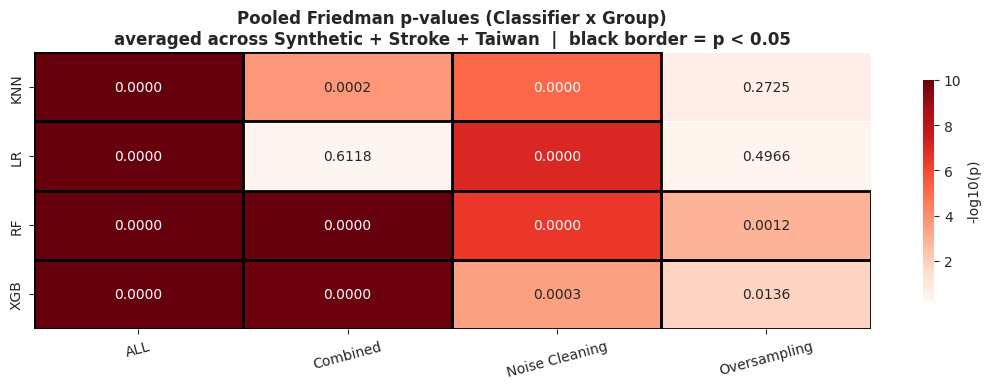

Fig P3 — pooled Friedman heatmap saved.


In [47]:
# ── 15f. Fig P3 — Pooled Friedman p-value heatmap ───────────
df_pool_stat   = pd.DataFrame(pool_stat_records)
pivot_pool_stat = df_pool_stat.pivot(
    index="Clf", columns="Group", values="friedman_p"
)
log_p_pool = -np.log10(pivot_pool_stat.clip(lower=1e-10))

fig_p3, ax_p3 = plt.subplots(figsize=(11, 4))
sns.heatmap(
    log_p_pool,
    annot=pivot_pool_stat.round(4), fmt=".4f",
    cmap="Reds", ax=ax_p3, linewidths=0.5,
    cbar_kws={"label": "-log10(p)", "shrink": 0.8},
)
for i, clf in enumerate(pivot_pool_stat.index):
    for j, grp in enumerate(pivot_pool_stat.columns):
        pv = pivot_pool_stat.loc[clf, grp]
        if not np.isnan(pv) and pv < ALPHA:
            ax_p3.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                fill=False, edgecolor="black", lw=2,
            ))
ax_p3.set_title(
    "Pooled Friedman p-values (Classifier x Group)\n"
    "averaged across Synthetic + Stroke + Taiwan  |  "
    f"black border = p < {ALPHA}",
    fontsize=12, fontweight="bold",
)
ax_p3.set_xlabel(""); ax_p3.set_ylabel("")
ax_p3.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figP3_pooled_friedman_heatmap.png",
    dpi=150, bbox_inches="tight",
)
plt.show(); print("Fig P3 — pooled Friedman heatmap saved.")

###Cohen's D

In [130]:
# ── 15g. Pooled Cohen's d ────────────────────────────────────
print(f"\n{'='*65}")
print("[Pooled] Cohen's d  (group minus None)")
print(f"{'='*65}")

pool_effect_records = []
for clf_name in classifiers:
    none_vals = df_fold_pool[
        (df_fold_pool["Clf"]     == clf_name) &
        (df_fold_pool["Sampler"] == "None")
    ][STAT_METRIC].values
    for group_name in ["Noise Cleaning", "Oversampling", "Combined"]:
        g_vals = (
            df_fold_pool[
                (df_fold_pool["Clf"]   == clf_name) &
                (df_fold_pool["Group"] == group_name)
            ]
            .groupby("fold")[STAT_METRIC].mean().values
        )
        d, _, _, _, _, _, _, _ = cohens_d(g_vals, none_vals) # Extract only the Cohen's d value
        interp = (
            "negligible" if abs(d) < 0.2 else
            "small"      if abs(d) < 0.5 else
            "medium"     if abs(d) < 0.8 else "large"
        )
        print(
            f"  {clf_name:4s}  {group_name:15s}  "
            f"d = {d:+.4f}  [{interp}]"
        )
        pool_effect_records.append({
            "Clf":      clf_name,
            "Group":    group_name,
            "cohens_d": d,
        })


[Pooled] Cohen's d  (group minus None)
  LR    Noise Cleaning   d = +1.1455  [large]
  LR    Oversampling     d = +6.2365  [large]
  LR    Combined         d = +6.3469  [large]
  KNN   Noise Cleaning   d = +1.0507  [large]
  KNN   Oversampling     d = +4.2484  [large]
  KNN   Combined         d = +4.4480  [large]
  RF    Noise Cleaning   d = +2.9539  [large]
  RF    Oversampling     d = +4.9517  [large]
  RF    Combined         d = +5.8938  [large]
  XGB   Noise Cleaning   d = +0.9547  [large]
  XGB   Oversampling     d = +1.8769  [large]
  XGB   Combined         d = +2.3769  [large]


###Heatmap:Cohen's D


[Pooled] Cohen's d  (group minus None)
  LR    Noise Cleaning   d = +1.1455  [large]
  LR    Oversampling     d = +6.2365  [large]
  LR    Combined         d = +6.3469  [large]
  KNN   Noise Cleaning   d = +1.0507  [large]
  KNN   Oversampling     d = +4.2484  [large]
  KNN   Combined         d = +4.4480  [large]
  RF    Noise Cleaning   d = +2.9539  [large]
  RF    Oversampling     d = +4.9517  [large]
  RF    Combined         d = +5.8938  [large]
  XGB   Noise Cleaning   d = +0.9547  [large]
  XGB   Oversampling     d = +1.8769  [large]
  XGB   Combined         d = +2.3769  [large]


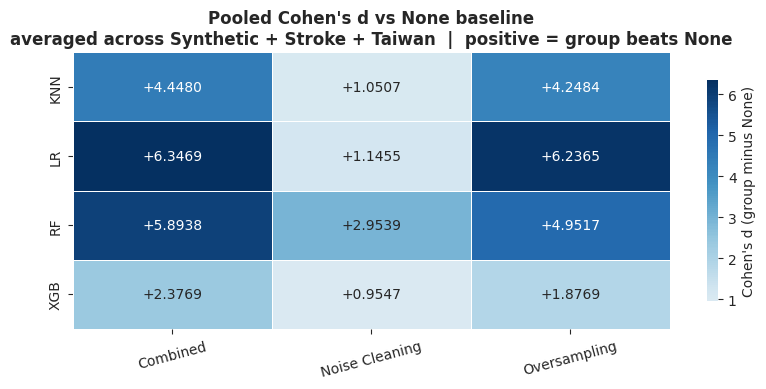

Fig P4 — pooled Cohen's d heatmap saved.


In [52]:


# ── 15h. Fig P4 — Pooled Cohen's d heatmap ──────────────────
pivot_pool_eff = pd.DataFrame(pool_effect_records).pivot(
    index="Clf", columns="Group", values="cohens_d"
)
fig_p4, ax_p4 = plt.subplots(figsize=(8, 4))
sns.heatmap(
    pivot_pool_eff, annot=True, fmt="+.4f",
    cmap="RdBu", center=0, ax=ax_p4, linewidths=0.5,
    cbar_kws={
        "label": "Cohen's d (group minus None)",
        "shrink": 0.8,
    },
)
ax_p4.set_title(
    "Pooled Cohen's d vs None baseline\n"
    "averaged across Synthetic + Stroke + Taiwan  |  "
    "positive = group beats None",
    fontsize=12, fontweight="bold",
)
ax_p4.set_xlabel(""); ax_p4.set_ylabel("")
ax_p4.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "figP4_pooled_cohens_d.png",
    dpi=150, bbox_inches="tight",
)
plt.show(); print("Fig P4 — pooled Cohen's d heatmap saved.")

##Pooled All Summary

In [49]:
# ── 15i. Pooled All summary ──────────────────────────────
print(f"\n{'='*84}")
print("  POOLED  All Samplers (no averaging across classifiers)")
print(f"{'='*84}")
print(
    df_pool.nlargest(96, "balanced_accuracy")
           [["Group", "Sampler", "Clf",
             "balanced_accuracy", "f1", "roc_auc", "recall", "precision"]]
           .to_string(index=False)
)


  POOLED  All Samplers (no averaging across classifiers)
         Group   Sampler Clf  balanced_accuracy       f1  roc_auc   recall  precision
      Combined BSMT+RENN  LR           0.791067 0.326785 0.847388 0.717781   0.220663
      Combined  SMT+RENN  LR           0.788466 0.270245 0.833119 0.765701   0.168725
      Combined BSMT+AKNN  LR           0.787985 0.327838 0.844850 0.710374   0.222562
      Combined  SMT+AKNN  LR           0.787923 0.271906 0.832259 0.763337   0.170109
      Combined   SMT+ENN  LR           0.784616 0.283478 0.828626 0.734299   0.179399
      Combined    SMT+TL  LR           0.783775 0.281403 0.828372 0.736313   0.177889
      Combined  ADA+AKNN  LR           0.783612 0.262574 0.830072 0.755310   0.161148
  Oversampling       SMT  LR           0.783501 0.281043 0.828326 0.736313   0.177642
  Oversampling       ADA  LR           0.782228 0.270387 0.825972 0.742872   0.168377
      Combined    ADA+TL  LR           0.781939 0.270289 0.825910 0.742192   0.168

##Pool Best Sample Per Classifier

In [50]:
print(f"\n{'='*113}")
print("  POOLED BEST SAMPLER PER CLASSIFIER")
print(f"{'='*113}")
df_pool_clf_best = (
    df_pool.sort_values("balanced_accuracy", ascending=False)
           .groupby("Clf", sort=False).first().reset_index()
           [["Clf", "Group", "Sampler",
             "balanced_accuracy", "f1", "roc_auc","recall","precision"]]
           .sort_values("balanced_accuracy", ascending=False)
)
for _, row in df_pool_clf_best.iterrows():
    print(
        f"  {row['Clf']:4s} -> "
        f"{row['Group']:15s} | "
        f"{row['Sampler']:12s} | "
        f"Bal.Acc={row['balanced_accuracy']:.4f}  "
        f"F1={row['f1']:.4f}  "
        f"AUC={row['roc_auc']:.4f}  "
        f"Recall={row['recall']:.4f}  "
        f"Precision={row['precision']:.4f}"

    )

print("\nPooled analysis complete.")


  POOLED BEST SAMPLER PER CLASSIFIER
  LR   -> Combined        | BSMT+RENN    | Bal.Acc=0.7911  F1=0.3268  AUC=0.8474  Recall=0.7178  Precision=0.2207
  XGB  -> Combined        | SMT+RENN     | Bal.Acc=0.7200  F1=0.3654  AUC=0.8450  Recall=0.4992  Precision=0.3260
  KNN  -> Combined        | BSMT+AKNN    | Bal.Acc=0.7091  F1=0.2410  AUC=0.7371  Recall=0.5658  Precision=0.1543
  RF   -> Combined        | SMT+RENN     | Bal.Acc=0.6593  F1=0.2491  AUC=0.8404  Recall=0.3771  Precision=0.2419

Pooled analysis complete.
